In [1]:
import re
import time
from pathlib import Path

import numpy as np
import pandas as pd
import geopandas as gpd
import openpyxl
import statsmodels.api as sm

import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.patches as mpatches
import matplotlib.patheffects as pe
from matplotlib.colors import PowerNorm
from matplotlib.lines import Line2D
from matplotlib.patches import Patch
from matplotlib.ticker import FuncFormatter
import seaborn as sns
from adjustText import adjust_text

In [2]:
_here = Path.cwd()
REPO_DIR = next((p for p in [_here, *_here.parents]
                 if (p / '.gitattributes').exists() or (p / '.git').exists()), None)
if REPO_DIR is None:
    raise FileNotFoundError("Open this notebook from inside the SM_Dissertation repository folder.")

PULLED_DIR = REPO_DIR / 'GEP Review Code' / 'Pulled Data'   # written by GEP_data_pull.ipynb
FIG_DIR    = REPO_DIR / 'Figures'                           # where figures are saved
DATA_DIR   = REPO_DIR / 'GEP Review Code' / 'Raw Data'      # raw input files

FIG_DIR.mkdir(parents=True, exist_ok=True)

BOUNDARIES_ZIP  = PULLED_DIR / 'ne_50m_admin_0_countries.zip'
GEP_SUMMARY_CSV = PULLED_DIR / 'gep_summary.csv'


ELEC_ACCESS_PATH = DATA_DIR / 'API_EG.ELC.ACCS.ZS_DS2_en_csv_v2_33377.csv'
POP_PATH         = DATA_DIR / 'API_SP.POP.TOTL_DS2_en_csv_v2_33112.csv'
GNI_PATH         = DATA_DIR / 'API_NY.GNP.PCAP.CD_DS2_en_csv_v2_318.csv'
PIP_PATH         = DATA_DIR / 'world_100bin_revised_2021.csv'
GINI_PATH        = DATA_DIR / 'Gini Data.xlsx'
DATA_INPUT_PATH  = DATA_DIR / 'Data Input.xlsx'
DRE_PATH         = DATA_DIR / 'dre_rwi_unelec_quintiles.csv'
MTF_PATH         = DATA_DIR / 'MTF_quintiles.xlsx'
GOGLA_PATH       = DATA_DIR / 'GOGLA_SSA_affordability_data_realdata.xlsx'
SDG7_PATH        = DATA_DIR / 'SDG7_electrification_quintiles_by_country.xlsx'
TARIFF_PATH      = DATA_DIR / 'Summary_Electricity_Bills.xlsx'
RISE_PATH        = DATA_DIR / 'rise-data-score-overall.xls'

In [3]:
for f in (BOUNDARIES_ZIP, GEP_SUMMARY_CSV):
    if not f.exists():
        raise FileNotFoundError(f"{f} not found — run GEP_01_pull_data.ipynb first.")

world = gpd.read_file(BOUNDARIES_ZIP)

ssa_iso = ['AGO','BEN','BWA','BFA','BDI','CMR','CPV','CAF','TCD','COM','COD','COG',
           'CIV','DJI','GNQ','ERI','ETH','GAB','GMB','GHA','GIN','GNB','KEN','LSO',
           'LBR','MDG','MWI','MLI','MRT','MOZ','MUS','NAM','NER','NGA','RWA','STP','SEN',
           'SLE','SYC','SOM','ZAF','SSD','SDN','SWZ','TZA','TGO','UGA','ZMB','ZWE']

ssa = world[world['ISO_A3'].isin(ssa_iso)].copy()

gep_summary = pd.read_csv(GEP_SUMMARY_CSV)

In [4]:
total_shs   = gep_summary['NewConn_SHS'].sum()
total_mg    = gep_summary['NewConn_MG'].sum()
total_grid  = gep_summary['NewConn_Grid'].sum()
total_all   = gep_summary['NewConn_Total'].sum()

print(f"SSA total new connections by 2030: {total_all:,.0f}")
print(f"  Grid:     {total_grid:,.0f}  ({total_grid/total_all*100:.1f}%)")
print(f"  SHS:      {total_shs:,.0f}  ({total_shs/total_all*100:.1f}%)")
print(f"  MiniGrid: {total_mg:,.0f}  ({total_mg/total_all*100:.1f}%)")

SSA total new connections by 2030: 940,971,495
  Grid:     476,501,213  (50.6%)
  SHS:      378,625,937  (40.2%)
  MiniGrid: 85,844,348  (9.1%)


In [5]:
wb_raw = pd.read_csv(ELEC_ACCESS_PATH, 
                     skiprows=4)

year_cols = [c for c in wb_raw.columns if c.isdigit()]
wb_raw['Elec_access_%'] = wb_raw[year_cols].apply(
    lambda row: row.dropna().iloc[-1] if not row.dropna().empty else None, axis=1
)

wb = (wb_raw[['Country Code', 'Elec_access_%']]
      .rename(columns={'Country Code': 'ISO3'})
      .dropna(subset=['Elec_access_%']))

wb = wb[wb['ISO3'].str.len() == 3]
wb['Elec_access_%'] = wb['Elec_access_%'].round(1)
wb['Unelec_%'] = (100 - wb['Elec_access_%']).round(1)

print(f"Countries loaded: {len(wb)}")
print(f"SSA matches: {wb[wb['ISO3'].isin(ssa['ISO_A3'])]['ISO3'].tolist()}")

Countries loaded: 263
SSA matches: ['AGO', 'BDI', 'BEN', 'BFA', 'BWA', 'CAF', 'CIV', 'CMR', 'COD', 'COG', 'COM', 'CPV', 'DJI', 'ERI', 'ETH', 'GAB', 'GHA', 'GIN', 'GMB', 'GNB', 'GNQ', 'KEN', 'LBR', 'LSO', 'MDG', 'MLI', 'MOZ', 'MRT', 'MUS', 'MWI', 'NAM', 'NER', 'NGA', 'RWA', 'SDN', 'SEN', 'SLE', 'SOM', 'SSD', 'STP', 'SWZ', 'SYC', 'TCD', 'TGO', 'TZA', 'UGA', 'ZAF', 'ZMB', 'ZWE']


In [6]:
final   = gep_summary.merge(wb, on='ISO3', how='left')
ssa_map = ssa.merge(final, left_on='ISO_A3', right_on='ISO3', how='left')

print(f"Unelec_% nulls: {ssa_map['Unelec_%'].isna().sum()}")
print(f"OffGrid_viable_% nulls: {ssa_map['OffGrid_viable_%'].isna().sum()}")

Unelec_% nulls: 3
OffGrid_viable_% nulls: 3


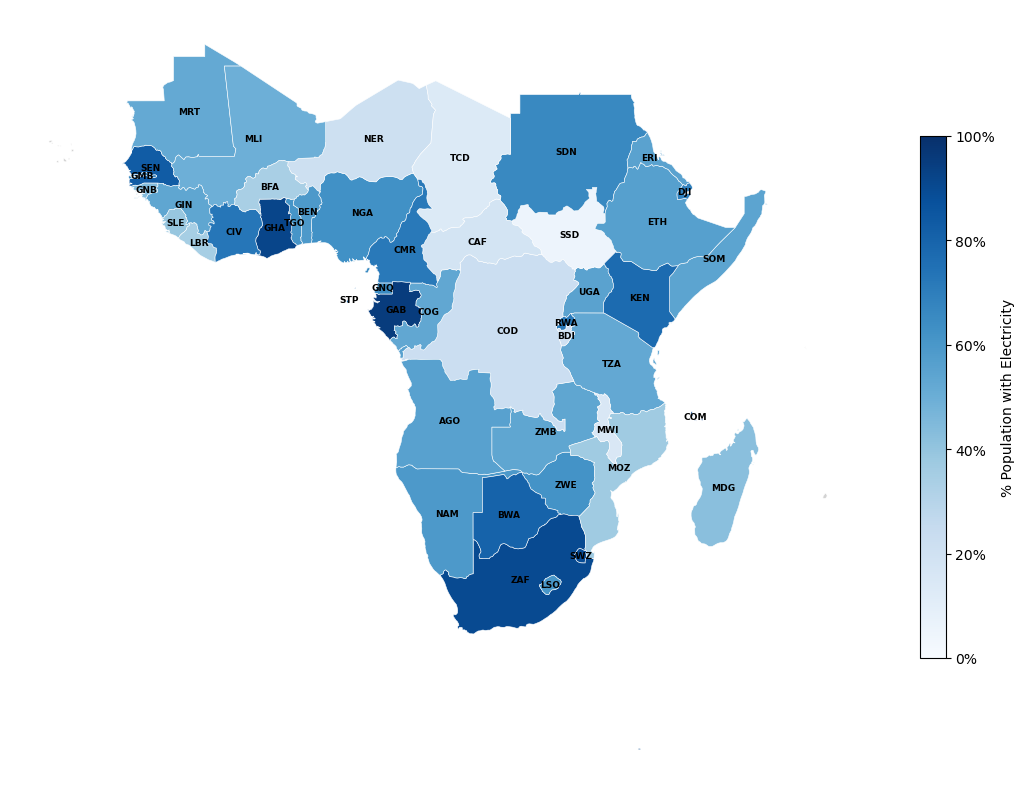

In [7]:

ssa_map['geometry'] = ssa_map['geometry'].simplify(tolerance=0.01, preserve_topology=True)

fig, ax = plt.subplots(figsize=(11, 9))

ssa_map.plot(
    column='Elec_access_%',
    ax=ax,
    cmap='Blues',
    legend=True,
    legend_kwds={'label': '% Population with Electricity', 'shrink': 0.6, 'format': '%.0f%%'},
    missing_kwds={'color': 'lightgrey', 'label': 'No data'},
    edgecolor='white', linewidth=0.4,
    vmin=0, vmax=100
)

# Annotate every country with its ISO3 code, uniform styling
for idx, row in ssa_map.iterrows():
    if row.geometry is None or pd.isna(row.get('Elec_access_%')):
        continue
    centroid = row.geometry.centroid
    ax.annotate(
        row['ISO_A3'],
        xy=(centroid.x, centroid.y),
        fontsize=6.5,
        fontweight='bold',
        color='black',
        ha='center', va='center'
    )

ax.axis('off')
plt.tight_layout()

# PDF: vector, so dpi barely matters — drop the 600 setting to avoid the render cost
plt.savefig(FIG_DIR / 'fig_africa_electrification_access.pdf', bbox_inches='tight')
plt.savefig(FIG_DIR / 'fig_africa_electrification_access.png', dpi=300, bbox_inches='tight')

plt.show()
plt.close(fig)

In [8]:
# SHS share of total new connections
gep_summary['SHS_share_%'] = round(
    gep_summary['NewConn_SHS'] / gep_summary['NewConn_Total'] * 100, 1
)
print(gep_summary[['ISO3','SHS_%','MiniGrid_%','OffGrid_viable_%']].sort_values('SHS_%', ascending=False).to_string(index=False))

ISO3  SHS_%  MiniGrid_%  OffGrid_viable_%
 ETH   64.1         2.5              66.5
 ZMB   62.2         1.9              64.2
 MOZ   59.4         1.9              61.3
 TZA   54.6         1.1              55.7
 SDN   52.6        15.4              68.0
 NER   50.1         4.4              54.5
 NAM   49.8         2.5              52.3
 MLI   44.6         5.2              49.8
 CAF   44.3        40.9              85.3
 COD   41.2         7.6              48.8
 NGA   39.3         1.5              40.8
 ZWE   38.4         3.7              42.1
 BDI   37.5         2.2              39.7
 TCD   37.5        53.0              90.5
 UGA   36.4         4.9              41.3
 MDG   35.4        23.3              58.7
 ZAF   35.0         0.4              35.4
 GIN   34.1        12.3              46.4
 BFA   33.6        12.4              46.1
 GNB   33.1        14.7              47.8
 KEN   32.3         3.9              36.2
 LBR   29.7        11.0              40.7
 MWI   28.9         3.6           

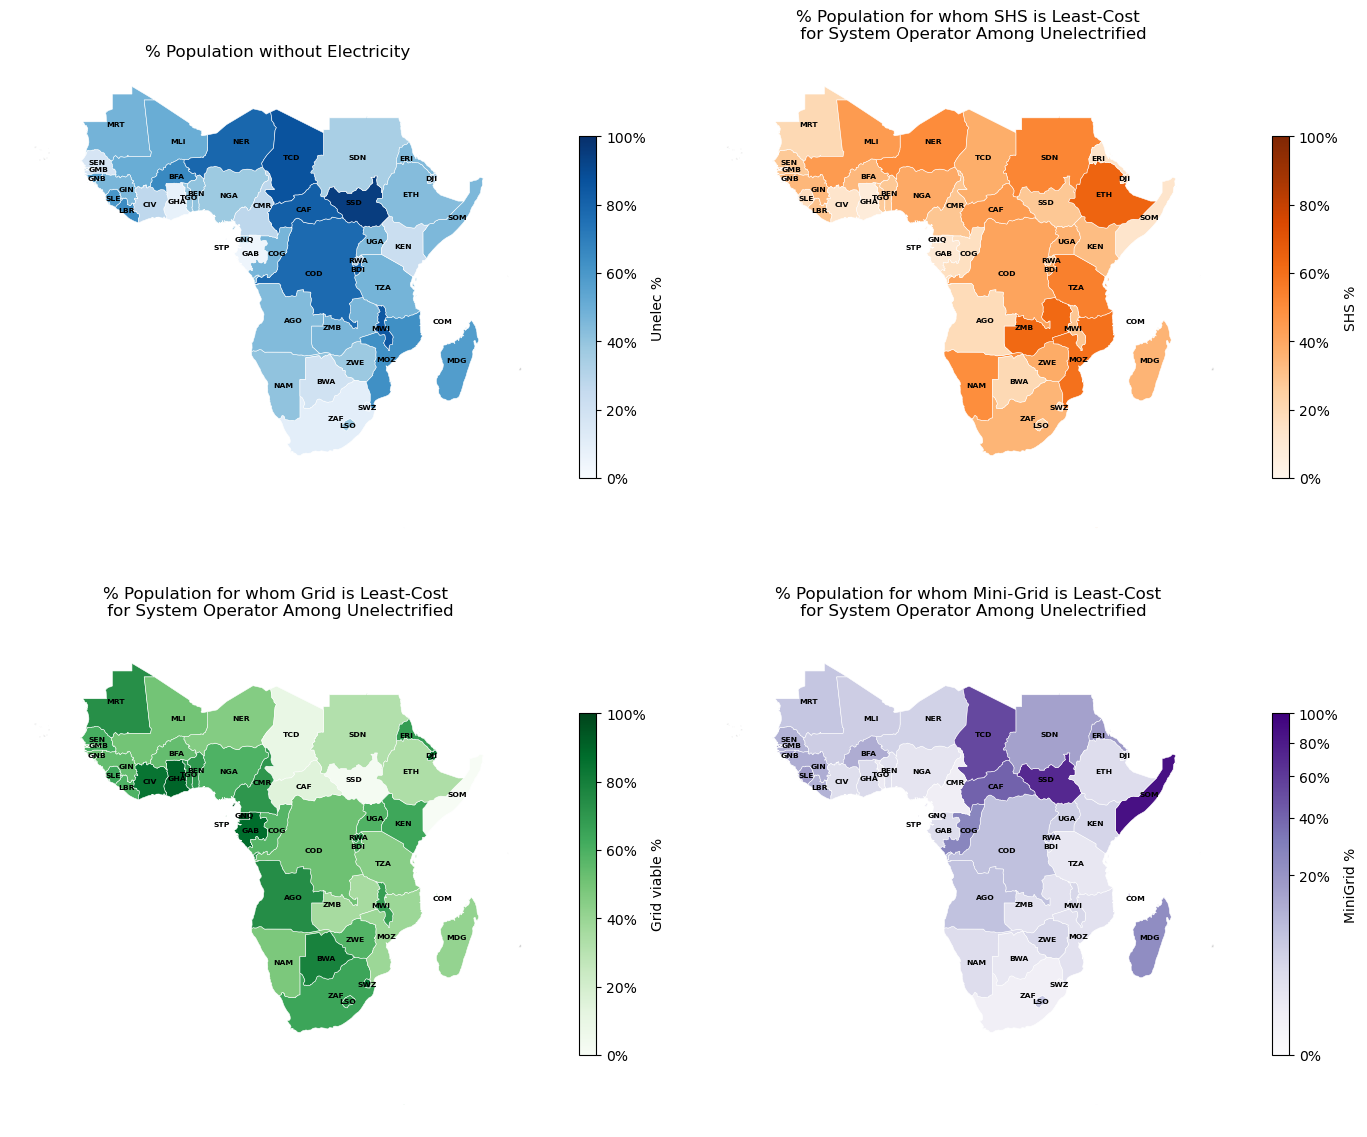

In [9]:
ssa_map['geometry'] = ssa_map['geometry'].simplify(tolerance=0.01, preserve_topology=True)

fig, axes = plt.subplots(2, 2, figsize=(14, 12))  # trimmed from 18x16 — 4-panel doesn't need to be this large

panels = [
    ('Unelec_%',      'Blues',   '% Population without Electricity',                    None, None),
    ('SHS_%',         'Oranges', '% Population for whom SHS is Least-Cost \n for System Operator Among Unelectrified\n',               None, None),
    ('Grid_viable_%', 'Greens',  '% Population for whom Grid is Least-Cost \n for System Operator Among Unelectrified\n',              None, None),
    ('MiniGrid_%',    'Purples', '% Population for whom Mini-Grid is Least-Cost \n for System Operator Among Unelectrified\n',
     PowerNorm(gamma=0.4, vmin=0, vmax=100), [0, 20, 40, 60, 80, 100]),
]

for ax, (col, cmap, title, norm, ticks) in zip(axes.flat, panels):
    legend_kwds = {'label': col.replace('_', ' '), 'shrink': 0.6, 'format': '%.0f%%'}
    if ticks is not None:
        legend_kwds['ticks'] = ticks

    plot_kwargs = dict(
        column=col,
        ax=ax,
        cmap=cmap,
        legend=True,
        legend_kwds=legend_kwds,
        missing_kwds={'color': 'lightgrey', 'label': 'No data'},
        edgecolor='white', linewidth=0.4,
    )
    if norm is not None:
        plot_kwargs['norm'] = norm
    else:
        plot_kwargs['vmin'] = 0
        plot_kwargs['vmax'] = 100

    ssa_map.plot(**plot_kwargs)

    for _, row in ssa_map.iterrows():
        if pd.isna(row['ISO3']):
            continue
        centroid = row['geometry'].representative_point()
        ax.annotate(
            text=row['ISO3'],
            xy=(centroid.x, centroid.y),
            ha='center', va='center',
            fontsize=5.5, color='black',
            fontweight='bold'
        )

    ax.set_title(title, fontsize=12)
    ax.axis('off')

plt.tight_layout()


plt.savefig(FIG_DIR / 'fig_africa_electrification_4panel.pdf', bbox_inches='tight')
plt.savefig(FIG_DIR / 'fig_africa_electrification_4panel.png', dpi=300, bbox_inches='tight')

plt.show()
plt.close(fig)

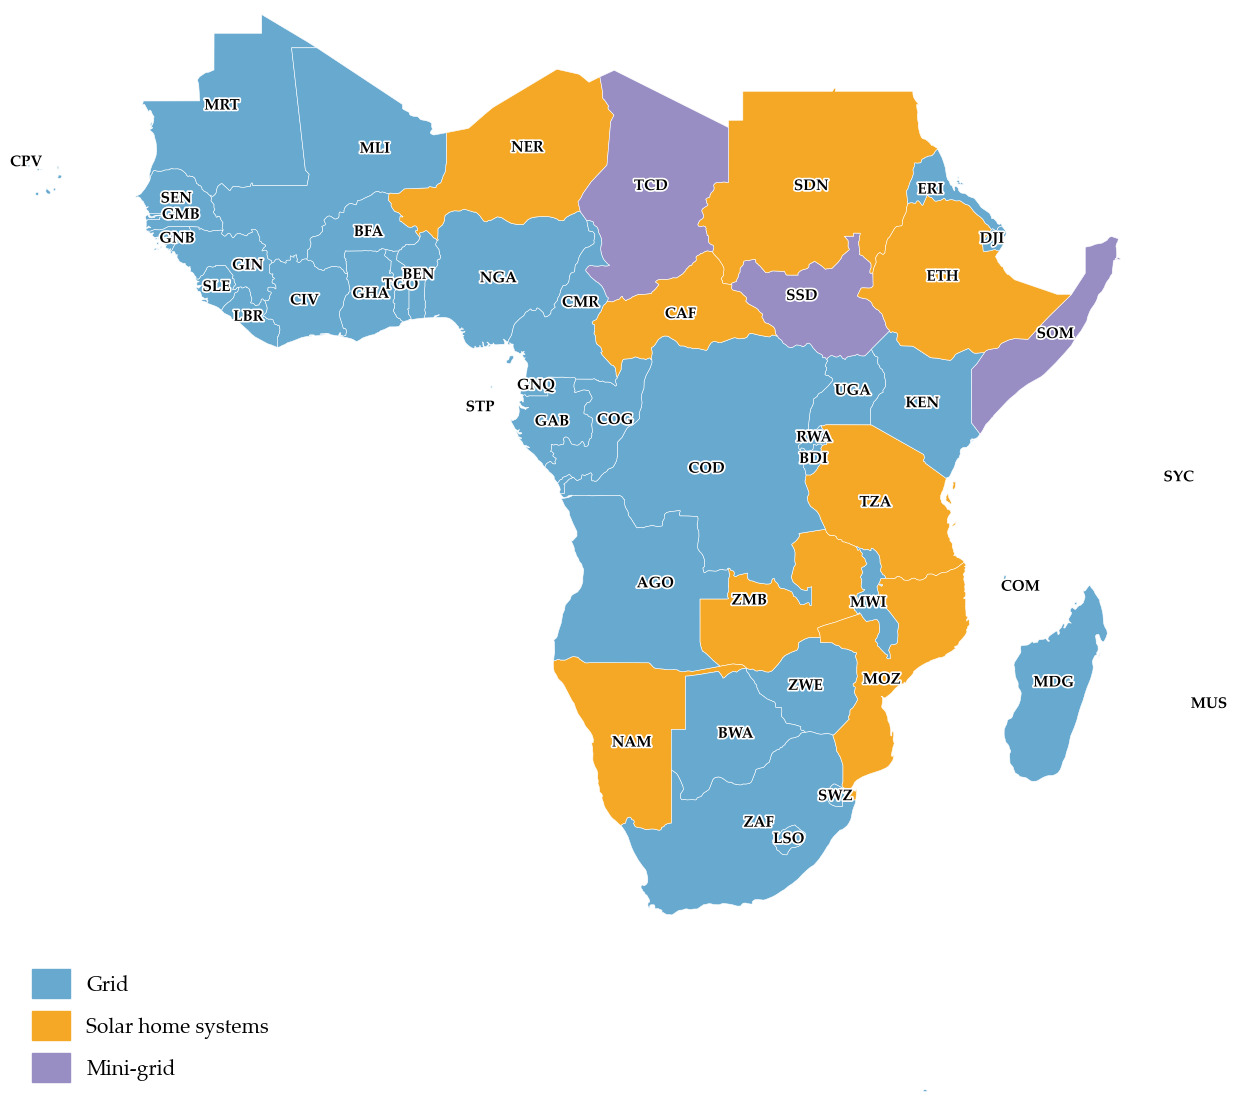

In [10]:
plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.serif']  = ['Palatino', 'Palatino Linotype', 'DejaVu Serif']

# Determine dominant least-cost intervention per country
def dominant_tech(row):
    vals = {'Grid': row['Grid_viable_%'], 'Solar home systems': row['SHS_%'], 'Mini-grid': row['MiniGrid_%']}
    return max(vals, key=vals.get)

ssa_map['Dominant_tech'] = ssa_map.apply(dominant_tech, axis=1)

tech_colors = {'Grid': '#67a9cf', 'Solar home systems': '#f4a825', 'Mini-grid': '#998ec3'}
ssa_map['Dominant_color'] = ssa_map['Dominant_tech'].map(tech_colors)

# Simplify geometry once
ssa_map['geometry'] = ssa_map['geometry'].simplify(tolerance=0.001, preserve_topology=True)

#Tighter bounding box so the map fills the frame
minx, miny, maxx, maxy = ssa_map.total_bounds
pad_x = (maxx - minx) * 0.005
pad_y = (maxy - miny) * 0.005

fig, ax = plt.subplots(figsize=(12, 11))

ssa_map.plot(
    color=ssa_map['Dominant_color'], ax=ax,
    edgecolor='white', linewidth=0.4,
    missing_kwds={'color': 'lightgrey'}
)

halo = [pe.withStroke(linewidth=2.5, foreground='white')]

for _, row in ssa_map.iterrows():
    if row.geometry is None:
        continue
    centroid = row.geometry.representative_point()
    ax.annotate(row['ISO_A3'], xy=(centroid.x, centroid.y),
                fontsize=11, fontweight='bold', color='black',
                ha='center', va='center', path_effects=halo)

ax.set_xlim(minx - pad_x, maxx + pad_x)
ax.set_ylim(miny - pad_y, maxy + pad_y)
ax.axis('off')

legend_handles = [mpatches.Patch(color=c, label=t) for t, c in tech_colors.items()]
ax.legend(
    handles=legend_handles,
    loc='lower left',
    frameon=False,
    fontsize=15,
    handlelength=1.8,
    handleheight=1.8,
    labelspacing=0.6,
    borderpad=0.2,
)

fig.subplots_adjust(left=0, right=1, top=1, bottom=0)

plt.savefig(FIG_DIR / 'fig_africa_dominant_intervention.pdf', bbox_inches='tight', pad_inches=0.02)
plt.savefig(FIG_DIR / 'fig_africa_dominant_intervention.png', dpi=1200, bbox_inches='tight', pad_inches=0.02)
plt.show()
plt.close(fig)

In [11]:
highlight     = {'KEN': '#D6604D', 'ZMB': '#2166AC'}
default_color = '#AAAAAA'

Looks like you are using a tranform that doesn't support FancyArrowPatch, using ax.annotate instead. The arrows might strike through texts. Increasing shrinkA in arrowprops might help.


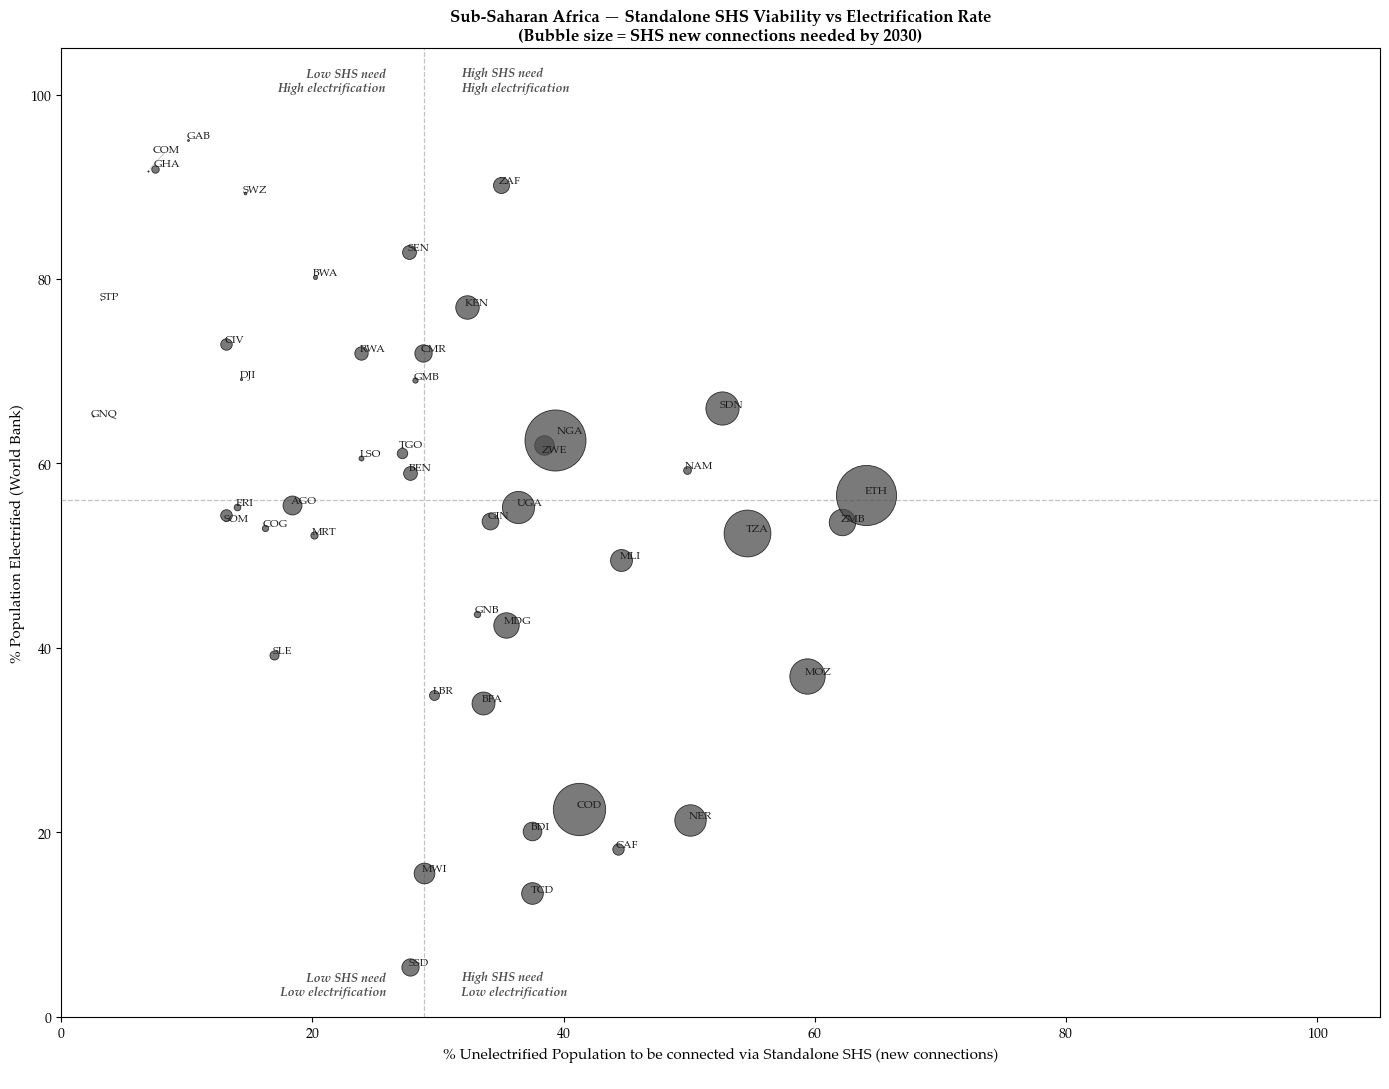

In [12]:
GREY = '#878787'
LABEL_COLOR = '#4d4d4d'

fig, ax = plt.subplots(figsize=(14, 11))

median_shs  = ssa_map['SHS_%'].median()
median_elec = ssa_map['Elec_access_%'].median()

texts = []
for _, row in ssa_map.dropna(subset=['Elec_access_%', 'SHS_%']).iterrows():
    x, y = row['SHS_%'], row['Elec_access_%']
    size = row['NewConn_SHS'] / 30000

    ax.scatter(
        x, y,
        s=size, color='#4d4d4d', alpha=0.75,
        edgecolors='black', linewidth=0.6,
        zorder=3
    )
    texts.append(
        ax.text(x, y, row['ISO_A3'], fontsize=8, color='#1a1a1a',
                zorder=5)
    )

# Automatic label repulsion so labels stop stacking on top of bubbles/each other
adjust_text(
    texts, ax=ax,
    arrowprops=dict(arrowstyle='-', color='grey', lw=0.5, alpha=0.6),
    expand_points=(1.6, 1.8)
)

ax.axvline(median_shs, color=GREY, linewidth=0.9, linestyle='--', alpha=0.5, zorder=1)
ax.axhline(median_elec, color=GREY, linewidth=0.9, linestyle='--', alpha=0.5, zorder=1)

# Quadrant labels positioned relative to actual median split, darker for legibility
pad = 3
ax.text(median_shs - pad, 103, 'Low SHS need\nHigh electrification', fontsize=9, color=LABEL_COLOR,
        ha='right', va='top', style='italic', fontweight='bold')
ax.text(median_shs + pad, 103, 'High SHS need\nHigh electrification', fontsize=9, color=LABEL_COLOR,
        ha='left', va='top', style='italic', fontweight='bold')
ax.text(median_shs - pad, 2, 'Low SHS need\nLow electrification', fontsize=9, color=LABEL_COLOR,
        ha='right', va='bottom', style='italic', fontweight='bold')
ax.text(median_shs + pad, 2, 'High SHS need\nLow electrification', fontsize=9, color=LABEL_COLOR,
        ha='left', va='bottom', style='italic', fontweight='bold')

ax.set_xlabel('% Unelectrified Population to be connected via Standalone SHS (new connections)\n', fontsize=11)
ax.set_ylabel('% Population Electrified (World Bank)', fontsize=11)
ax.set_title(
    'Sub-Saharan Africa — Standalone SHS Viability vs Electrification Rate\n'
    '(Bubble size = SHS new connections needed by 2030)',
    fontsize=12, fontweight='bold'
)
ax.set_xlim(0, 105)
ax.set_ylim(0, 105)

plt.tight_layout()
plt.savefig(FIG_DIR / 'fig_africa_shs_viability.pdf', dpi=300, bbox_inches='tight')
plt.show()

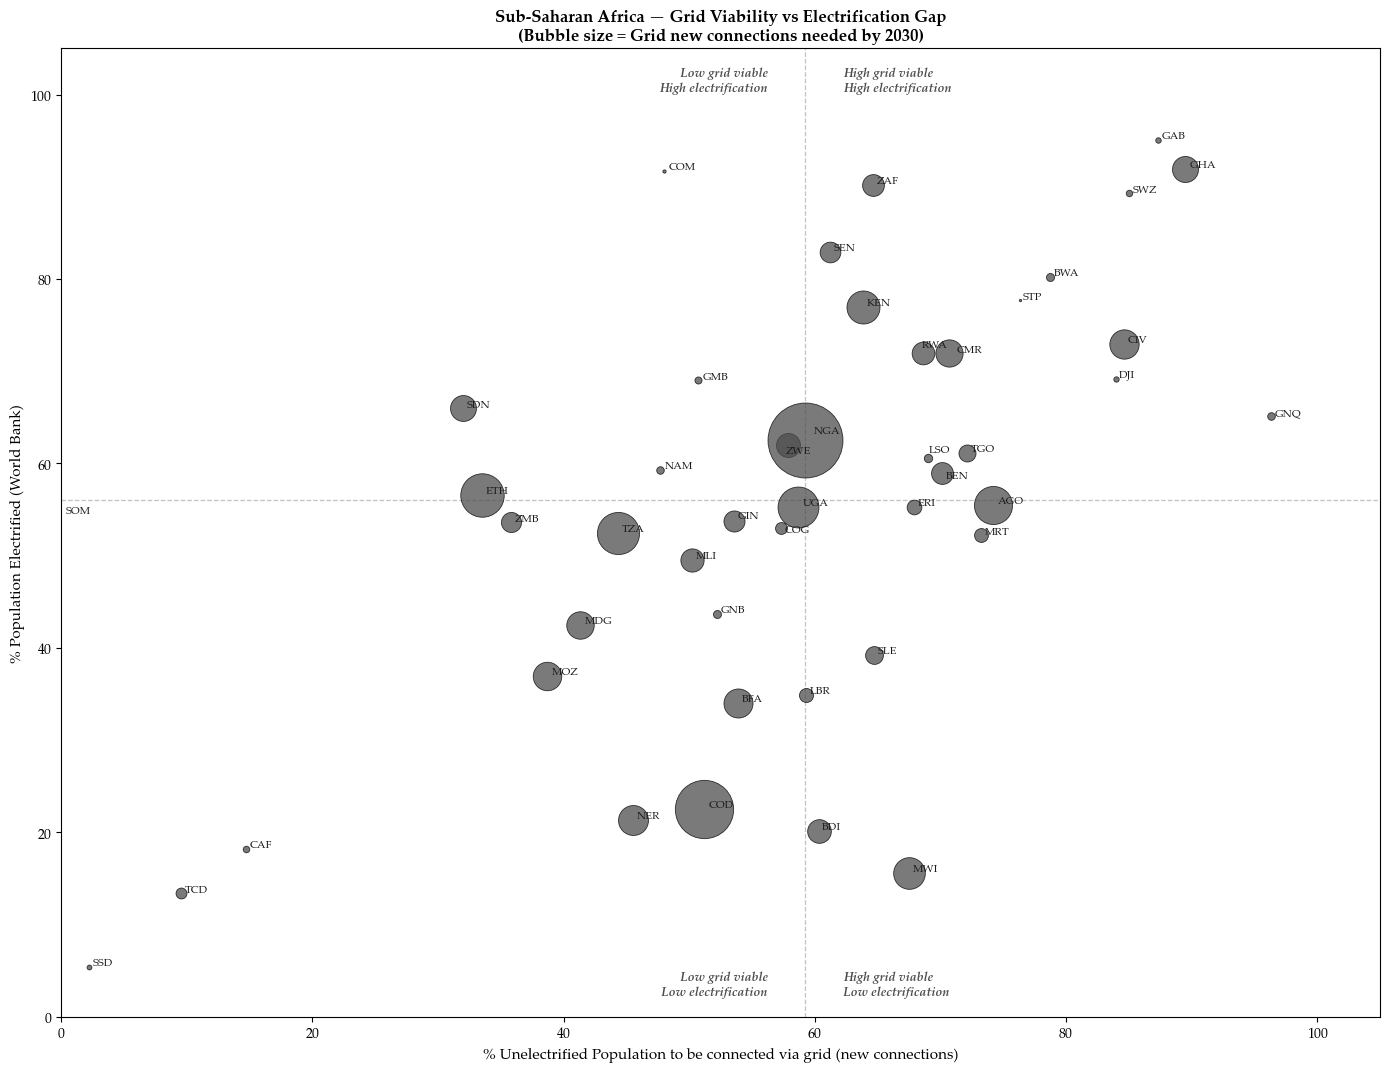

In [13]:
GREY = '#878787'
LABEL_COLOR = '#4d4d4d'

fig, ax = plt.subplots(figsize=(14, 11))

median_grid = ssa_map['Grid_viable_%'].median()
median_elec = ssa_map['Elec_access_%'].median()

texts = []
for _, row in ssa_map.dropna(subset=['Elec_access_%', 'Grid_viable_%']).iterrows():
    x, y = row['Grid_viable_%'], row['Elec_access_%']
    size = row['NewConn_Grid'] / 30000   # bubble = grid connections needed by 2030

    ax.scatter(
        x, y,
        s=size, color='#4d4d4d', alpha=0.75,
        edgecolors='black', linewidth=0.6,
        zorder=3
    )
    texts.append(
        ax.text(x, y, row['ISO_A3'], fontsize=8, color='#1a1a1a',
                zorder=5)
    )

adjust_text(
    texts, ax=ax,
    arrowprops=dict(arrowstyle='-', color='grey', lw=0.5, alpha=0.6),
    expand_points=(1.6, 1.8)
)

ax.axvline(median_grid, color=GREY, linewidth=0.9, linestyle='--', alpha=0.5, zorder=1)
ax.axhline(median_elec, color=GREY, linewidth=0.9, linestyle='--', alpha=0.5, zorder=1)

pad = 3
ax.text(median_grid - pad, 103, 'Low grid viable\nHigh electrification', fontsize=9, color=LABEL_COLOR,
        ha='right', va='top', style='italic', fontweight='bold')
ax.text(median_grid + pad, 103, 'High grid viable\nHigh electrification', fontsize=9, color=LABEL_COLOR,
        ha='left', va='top', style='italic', fontweight='bold')
ax.text(median_grid - pad, 2, 'Low grid viable\nLow electrification', fontsize=9, color=LABEL_COLOR,
        ha='right', va='bottom', style='italic', fontweight='bold')
ax.text(median_grid + pad, 2, 'High grid viable\nLow electrification', fontsize=9, color=LABEL_COLOR,
        ha='left', va='bottom', style='italic', fontweight='bold')

ax.set_xlabel('% Unelectrified Population to be connected via grid (new connections)\n', fontsize=11)
ax.set_ylabel('% Population Electrified (World Bank)', fontsize=11)
ax.set_title(
    'Sub-Saharan Africa — Grid Viability vs Electrification Gap\n'
    '(Bubble size = Grid new connections needed by 2030)',
    fontsize=12, fontweight='bold'
)
ax.set_xlim(0, 105)
ax.set_ylim(0, 105)

plt.tight_layout()
plt.savefig(FIG_DIR / 'fig_africa_grid_viability.pdf', dpi=300, bbox_inches='tight')
plt.show()

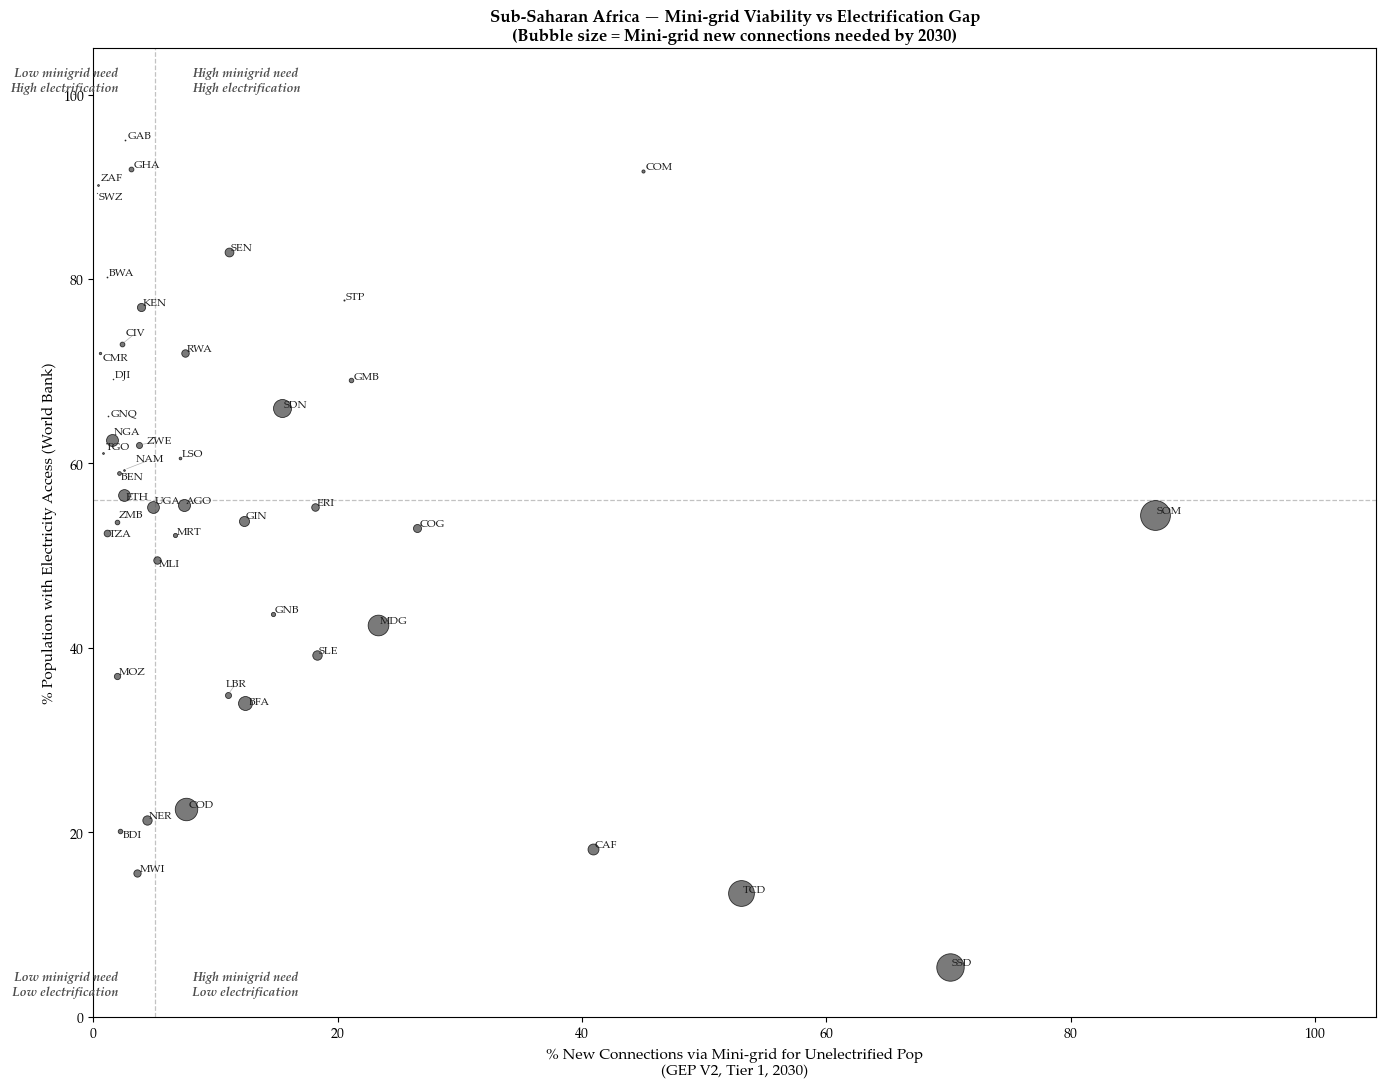

In [14]:
GREY = '#878787'
LABEL_COLOR = '#4d4d4d'

fig, ax = plt.subplots(figsize=(14, 11))

median_mg   = ssa_map['MiniGrid_%'].median()
median_elec = ssa_map['Elec_access_%'].median()

texts = []
for _, row in ssa_map.dropna(subset=['Elec_access_%', 'MiniGrid_%']).iterrows():
    x, y = row['MiniGrid_%'], row['Elec_access_%']
    size = row['NewConn_MG'] / 30000   # bubble = mini-grid connections needed by 2030

    ax.scatter(
        x, y,
        s=size, color='#4d4d4d', alpha=0.75,
        edgecolors='black', linewidth=0.6,
        zorder=3
    )
    texts.append(
        ax.text(x, y, row['ISO_A3'], fontsize=8, color='#1a1a1a',
                zorder=5)
    )

adjust_text(
    texts, ax=ax,
    arrowprops=dict(arrowstyle='-', color='grey', lw=0.5, alpha=0.6),
    expand_points=(1.6, 1.8)
)

ax.axvline(median_mg, color=GREY, linewidth=0.9, linestyle='--', alpha=0.5, zorder=1)
ax.axhline(median_elec, color=GREY, linewidth=0.9, linestyle='--', alpha=0.5, zorder=1)

pad = 3
ax.text(median_mg - pad, 103, 'Low minigrid need\nHigh electrification', fontsize=9, color=LABEL_COLOR,
        ha='right', va='top', style='italic', fontweight='bold')
ax.text(median_mg + pad, 103, 'High minigrid need\nHigh electrification', fontsize=9, color=LABEL_COLOR,
        ha='left', va='top', style='italic', fontweight='bold')
ax.text(median_mg - pad, 2, 'Low minigrid need\nLow electrification', fontsize=9, color=LABEL_COLOR,
        ha='right', va='bottom', style='italic', fontweight='bold')
ax.text(median_mg + pad, 2, 'High minigrid need\nLow electrification', fontsize=9, color=LABEL_COLOR,
        ha='left', va='bottom', style='italic', fontweight='bold')

ax.set_xlabel('% New Connections via Mini-grid for Unelectrified Pop\n(GEP V2, Tier 1, 2030)', fontsize=11)
ax.set_ylabel('% Population with Electricity Access (World Bank)', fontsize=11)
ax.set_title(
    'Sub-Saharan Africa — Mini-grid Viability vs Electrification Gap\n'
    '(Bubble size = Mini-grid new connections needed by 2030)',
    fontsize=12, fontweight='bold'
)
ax.set_xlim(0, 105)
ax.set_ylim(0, 105)

plt.tight_layout()
plt.savefig(FIG_DIR / 'fig_africa_minigrid_viability.pdf', dpi=300, bbox_inches='tight')
plt.show()

In [15]:
# Equal-area projection needed for accurate area calc (not degrees)
ssa_proj = ssa.to_crs('ESRI:102022')  # Africa Albers Equal Area Conic
ssa['area_km2'] = ssa_proj.geometry.area / 1e6

ssa['pop_density'] = ssa['POP_EST'] / ssa['area_km2']

density_df = ssa[['ISO_A3', 'area_km2', 'pop_density']].rename(columns={'ISO_A3': 'ISO3'})
ssa_map = ssa_map.merge(density_df, on='ISO3', how='left')

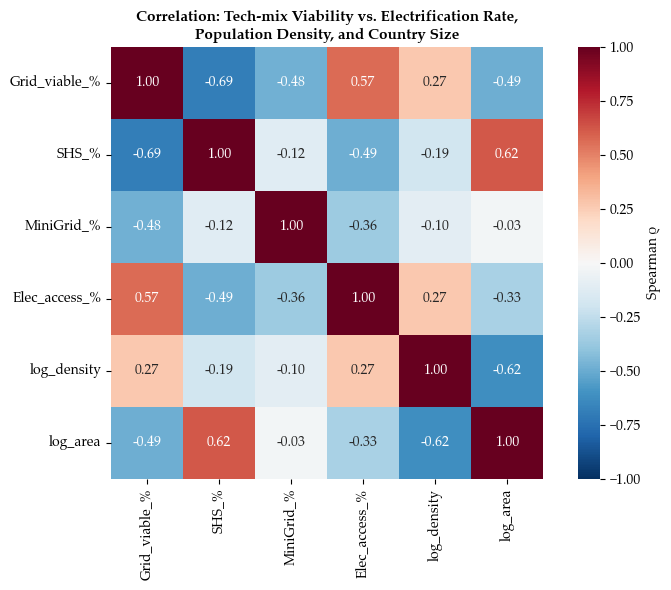

In [16]:
corr_vars = ['Grid_viable_%', 'SHS_%', 'MiniGrid_%', 'Elec_access_%', 'pop_density', 'area_km2']
corr_df = ssa_map[corr_vars].dropna()

# log-transform density and area — both are heavily right-skewed (a few huge/tiny countries)
corr_df['log_density'] = np.log(corr_df['pop_density'])
corr_df['log_area'] = np.log(corr_df['area_km2'])

corr_matrix = corr_df[['Grid_viable_%', 'SHS_%', 'MiniGrid_%', 'Elec_access_%', 'log_density', 'log_area']].corr(method='spearman')

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='RdBu_r', center=0,
            vmin=-1, vmax=1, ax=ax, square=True, cbar_kws={'label': 'Spearman ρ'})
ax.set_title('Correlation: Tech-mix Viability vs. Electrification Rate,\nPopulation Density, and Country Size', fontsize=11, fontweight='bold')
plt.tight_layout()
plt.savefig(FIG_DIR / 'fig_correlation_drivers.pdf', dpi=300, bbox_inches='tight')
plt.show()

In [17]:
reg_df = ssa_map[['ISO_A3', 'Grid_viable_%', 'SHS_%', 'MiniGrid_%', 'Elec_access_%', 'area_km2', 'pop_density']].copy()
reg_df['log_area'] = np.log(reg_df['area_km2'])
reg_df['log_density'] = np.log(reg_df['pop_density'])
reg_df = reg_df.dropna(subset=['Grid_viable_%', 'SHS_%', 'MiniGrid_%', 'Elec_access_%', 'log_area', 'log_density'])

print(f"N countries in regression: {len(reg_df)}")

predictors = ['Elec_access_%', 'log_area', 'log_density']
X = sm.add_constant(reg_df[predictors])

results = {}
for outcome in ['Grid_viable_%', 'SHS_%', 'MiniGrid_%']:
    y = reg_df[outcome]
    model = sm.OLS(y, X).fit()
    results[outcome] = model
    print(f"\n{'='*60}")
    print(f"OUTCOME: {outcome}")
    print(f"{'='*60}")
    print(model.summary())

N countries in regression: 46

OUTCOME: Grid_viable_%
                            OLS Regression Results                            
Dep. Variable:          Grid_viable_%   R-squared:                       0.383
Model:                            OLS   Adj. R-squared:                  0.339
Method:                 Least Squares   F-statistic:                     8.700
Date:                Fri, 09 Oct 2026   Prob (F-statistic):           0.000132
Time:                        10:52:52   Log-Likelihood:                -195.67
No. Observations:                  46   AIC:                             399.3
Df Residuals:                      42   BIC:                             406.7
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                    coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------

In [18]:
iso_to_name = {
    'AGO':'Angola','BDI':'Burundi','BEN':'Benin','BFA':'Burkina Faso',
    'BWA':'Botswana','CAF':'Central African Rep.','CMR':'Cameroon',
    'COD':'Dem. Rep. Congo','COG':'Congo','COM':'Comoros','CIV':"Côte d'Ivoire",
    'DJI':'Djibouti','ERI':'Eritrea','ETH':'Ethiopia','GAB':'Gabon',
    'GMB':'Gambia','GHA':'Ghana','GIN':'Guinea','GNB':'Guinea-Bissau',
    'GNQ':'Eq. Guinea','KEN':'Kenya','LSO':'Lesotho','LBR':'Liberia',
    'MDG':'Madagascar','MWI':'Malawi','MLI':'Mali','MRT':'Mauritania',
    'MOZ':'Mozambique','MUS':'Mauritius','NAM':'Namibia','NER':'Niger','NGA':'Nigeria',
    'RWA':'Rwanda','SEN':'Senegal','SLE':'Sierra Leone','SOM':'Somalia',
    'STP':'São Tomé and Príncipe','SYC':'Seychelles','ZAF':'South Africa',
    'SSD':'S. Sudan','SDN':'Sudan','SWZ':'Eswatini',
    'TCD':'Chad', 'TZA':'Tanzania','TGO':'Togo','UGA':'Uganda',
    'ZMB':'Zambia','ZWE':'Zimbabwe'
}

In [19]:
pop = ssa[['ISO_A3','POP_EST']].rename(columns={'ISO_A3':'ISO3','POP_EST':'pop_est'})

chart_df = gep_summary[['ISO3','NewConn_Grid','NewConn_SHS','NewConn_MG','NewConn_Total']].copy()
chart_df = chart_df.merge(wb[['ISO3','Elec_access_%','Unelec_%']], on='ISO3', how='left')
chart_df = chart_df.merge(pop, on='ISO3', how='left')

chart_df['currently_electrified_M'] = chart_df['pop_est'] * chart_df['Elec_access_%'] / 100 / 1e6

for col in ['NewConn_Grid','NewConn_SHS','NewConn_MG','NewConn_Total']:
    chart_df[f'{col}_M'] = chart_df[col] / 1e6


chart_df['implied_gep_pop_M'] = chart_df['currently_electrified_M'] + chart_df['NewConn_Total_M']

# percentages of GEP 2030 implied population
chart_df['pct_electrified'] = chart_df['currently_electrified_M'] / chart_df['implied_gep_pop_M'] * 100
chart_df['pct_new_grid']    = chart_df['NewConn_Grid_M']           / chart_df['implied_gep_pop_M'] * 100
chart_df['pct_new_shs']     = chart_df['NewConn_SHS_M']            / chart_df['implied_gep_pop_M'] * 100
chart_df['pct_new_mg']      = chart_df['NewConn_MG_M']             / chart_df['implied_gep_pop_M'] * 100

# verify all sum to 100%
chart_df['pct_total'] = (chart_df['pct_electrified'] + chart_df['pct_new_grid'] +
                          chart_df['pct_new_shs']     + chart_df['pct_new_mg'])
print("Sum check (should all be ~100%):")
print(chart_df[['ISO3','pct_total']].to_string(index=False))

# add country names and sort
chart_df['country'] = chart_df['ISO3'].map(iso_to_name)
chart_df = chart_df.sort_values('pct_electrified', ascending=True)

print(f"\nCountries in chart_df: {len(chart_df)}")
print(chart_df[['ISO3','currently_electrified_M','NewConn_Grid_M',
                'NewConn_SHS_M','NewConn_MG_M','implied_gep_pop_M',
                'pct_electrified','pct_new_grid','pct_new_shs',
                'pct_new_mg','pct_total']].to_string(index=False))

Sum check (should all be ~100%):
ISO3  pct_total
 SOM 100.000000
 SSD 100.000000
 TCD 100.000000
 CAF 100.000000
 SDN 100.000000
 ETH 100.000000
 ZMB  99.999996
 MOZ 100.000002
 MDG 100.000003
 TZA 100.000000
 NER 100.000000
 NAM 100.000000
 COM 100.000000
 MLI 100.000000
 GMB  99.999968
 COD 100.000000
 GNB 100.000036
 GIN 100.000000
 BFA 100.000000
 COG 100.000015
 ZWE 100.000004
 UGA 100.000000
 NGA 100.000000
 LBR 100.000000
 BDI 100.000000
 SEN 100.000000
 KEN 100.000000
 ZAF 100.000000
 SLE 100.000000
 MWI 100.000004
 ERI 100.000000
 RWA 100.000000
 LSO 100.000000
 BEN 100.000000
 CMR 100.000000
 TGO 100.000000
 MRT 100.000015
 AGO 100.000000
 STP 100.000000
 BWA  99.999968
 DJI 100.000000
 CIV 100.000000
 SWZ  99.999945
 GAB 100.000000
 GHA 100.000000
 GNQ 100.000000

Countries in chart_df: 46
ISO3  currently_electrified_M  NewConn_Grid_M  NewConn_SHS_M  NewConn_MG_M  implied_gep_pop_M  pct_electrified  pct_new_grid  pct_new_shs  pct_new_mg  pct_total
 SSD                 0.5973

In [20]:
ssa_iso_list = ['AGO','BEN','BWA','BFA','BDI','CMR','CAF','TCD','CPV','COD','COG','COM',
                'CIV','DJI','GNQ','ERI','ETH','GAB','GMB','GHA','GIN','GNB',
                'KEN','LSO','LBR','MDG','MWI','MLI','MRT','MOZ','MUS','NAM','NER',
                'NGA','RWA','SEN','SLE','SOM','STP','SYC','ZAF','SSD','SDN','SWZ','TZA',
                'TGO','UGA','ZMB','ZWE']

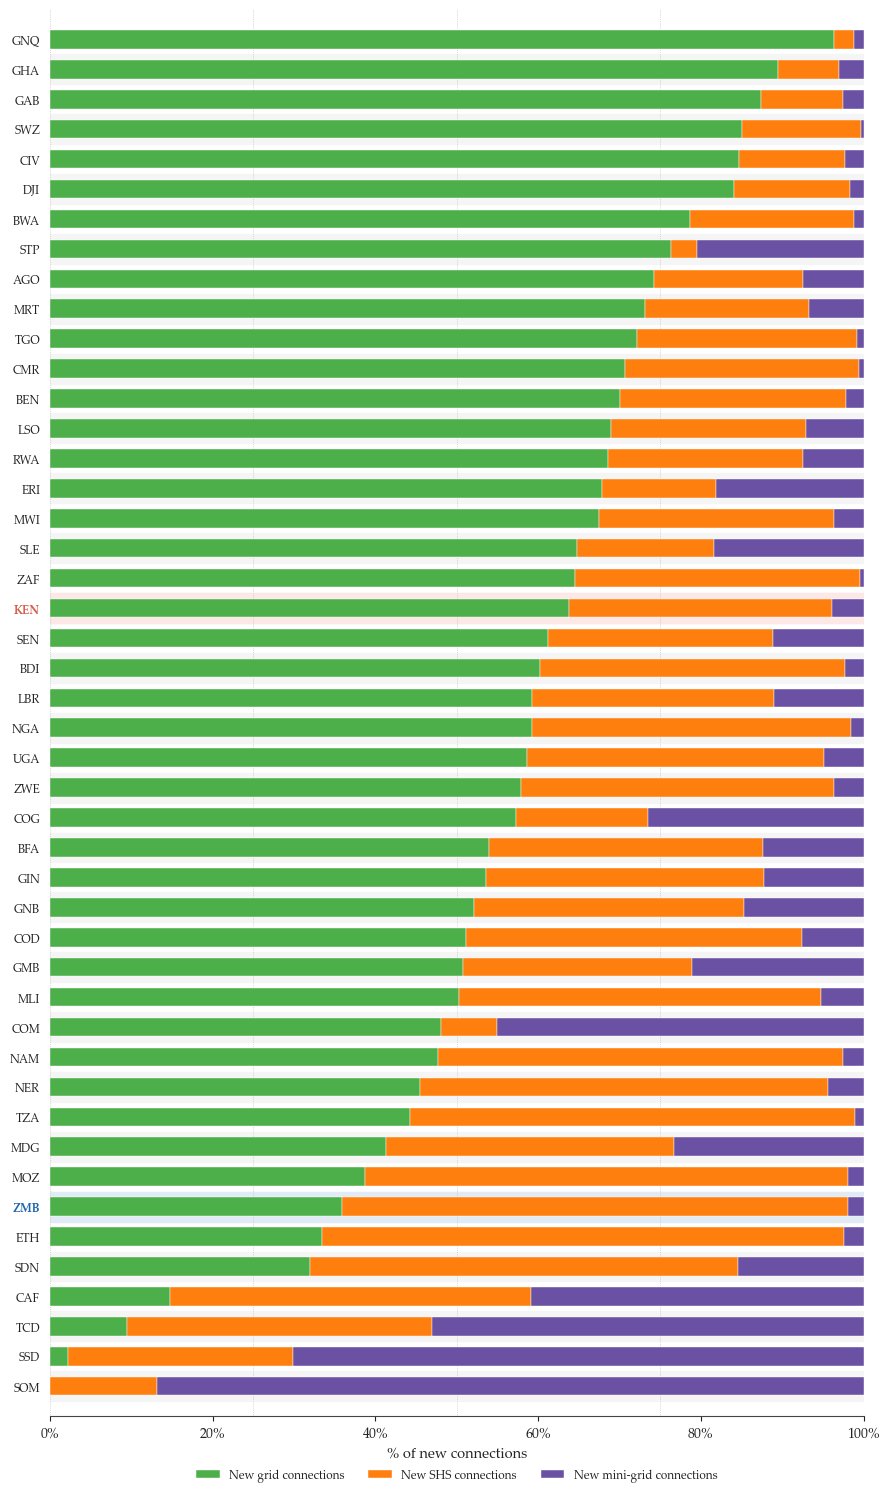

In [21]:
plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.serif']  = ['Palatino', 'Palatino Linotype', 'DejaVu Serif']
plt.rcParams['axes.edgecolor'] = '#444444'
plt.rcParams['text.color']  = '#222222'
plt.rcParams['axes.labelcolor'] = '#222222'
plt.rcParams['xtick.color'] = '#222222'
plt.rcParams['ytick.color'] = '#222222'

COL_GRID = '#4DAF4A'
COL_SHS  = '#FF7F0E'
COL_MG   = '#6A51A3'

df = chart_df.copy()
new_total = df[['pct_new_grid','pct_new_shs','pct_new_mg']].sum(axis=1)
df['shs_share']  = df['pct_new_shs']  / new_total * 100
df['grid_share'] = df['pct_new_grid'] / new_total * 100
df['mg_share']   = df['pct_new_mg']   / new_total * 100

df = df.sort_values('grid_share', ascending=True).reset_index(drop=True)  # ascending so most-SHS ends up at top of barh
n  = len(df)
y  = np.arange(n)

fig, ax = plt.subplots(figsize=(9, 15))

left = np.zeros(n)
for vals, col, lab in [(df['grid_share'], COL_GRID, 'New grid connections'),
                        (df['shs_share'],  COL_SHS,  'New SHS connections'),
                        (df['mg_share'],   COL_MG,   'New mini-grid connections')]:
    ax.barh(y, vals, left=left, height=0.62, color=col,
             edgecolor='white', linewidth=0.3, label=lab)
    left += vals

for x in [0, 25, 50, 75, 100]:
    ax.axvline(x, color='#BBBBBB', linewidth=0.5, zorder=0, linestyle=':')

for i in range(0, n, 2):
    ax.axhspan(i - 0.5, i + 0.5, color='#F5F5F5', zorder=-1)

ax.set_yticks(y)
ax.set_yticklabels(df['ISO3'].values, fontsize=8.5)
for i, iso in enumerate(df['ISO3'].values):
    lbl = ax.get_yticklabels()[i]
    if iso == 'KEN':
        lbl.set_color('#D6604D'); lbl.set_fontweight('bold')
        ax.axhspan(i - 0.5, i + 0.5, color='#FCE8E6', zorder=-1)
    elif iso == 'ZMB':
        lbl.set_color('#2166AC'); lbl.set_fontweight('bold')
        ax.axhspan(i - 0.5, i + 0.5, color='#E1EBF5', zorder=-1)

ax.set_xlim(0, 100)
ax.xaxis.set_major_formatter(FuncFormatter(lambda x, _: f'{int(x)}%'))
ax.set_ylim(-1, n)
ax.set_xlabel('% of new connections', fontsize=10.5)


handles, labels = ax.get_legend_handles_labels()
ax.legend(handles, labels, loc='upper center', bbox_to_anchor=(0.5, -0.03),
          ncol=3, fontsize=8.5, frameon=False)

ax.spines[['top','right']].set_visible(False)
ax.spines['left'].set_visible(False)
ax.tick_params(left=False)

plt.tight_layout()
plt.savefig(FIG_DIR / 'fig_gep_shs_ranked.pdf', dpi=300, bbox_inches='tight')
plt.savefig(FIG_DIR / 'fig_gep_shs_ranked.png', dpi=300, bbox_inches='tight')
plt.show()

In [22]:
# Check SSA medians
print(f"Median SHS%: {ssa_map['SHS_%'].median():.1f}")
print(f"Median Unelec%: {ssa_map['Unelec_%'].median():.1f}")

Median SHS%: 28.9
Median Unelec%: 44.0


In [23]:
PAYGO_PRICE = 0.82*199+0.18*127
REPAYMENT_MONTHS = 24
monthly_paygo    = PAYGO_PRICE / REPAYMENT_MONTHS   
required_deposit = monthly_paygo * 3                

In [24]:
ENERGY_LOW  = 0.05   
ENERGY_HIGH = 0.10  

In [25]:
GNI_REFERENCE_YEAR = '2025'

# Historical US annual CPI-U inflation rates (BLS, Dec-Dec), 2015 through 2025
US_CPI_RATES = {
    2015: 0.007, 2016: 0.021, 2017: 0.021, 2018: 0.019, 2019: 0.023,
    2020: 0.014, 2021: 0.07,  2022: 0.065, 2023: 0.034,
    2024: 0.029,   # finalised full-year rate
    2025: 0.027,   # finalised full-year rate
}

def compound_gni(base_value, base_year, target_year=2025, rates=US_CPI_RATES):
    """Compound a stale GNI base value forward using actual annual CPI rates."""
    val = base_value
    for yr in range(base_year + 1, target_year + 1):
        val *= (1 + rates[yr])
    return val

GNI_MANUAL_OVERRIDES = {
    'ERI': compound_gni(530, 2014),   # -> ~732.29
    'SSD': compound_gni(1040, 2015),  # -> ~1426.96
}

gni_raw = pd.read_csv(
    GNI_PATH,
    skiprows=4
)

# extract 2025 value per country
gni_raw['gni_pc'] = pd.to_numeric(gni_raw[GNI_REFERENCE_YEAR], errors='coerce')

# filter to SSA countries only
gni_lookup = (gni_raw[gni_raw['Country Code'].isin(ssa_iso_list)]
              [['Country Code', 'Country Name', 'gni_pc']]
              .rename(columns={'Country Code': 'ISO3', 'Country Name': 'country_name'})
              .set_index('ISO3'))

for iso, val in GNI_MANUAL_OVERRIDES.items():
    if iso in gni_lookup.index:
        gni_lookup.loc[iso, 'gni_pc'] = val
    else:
        # country wasn't in the SSA filter result at all — add it
        country_name = gni_raw.loc[gni_raw['Country Code'] == iso, 'Country Name'].values
        gni_lookup.loc[iso] = [country_name[0] if len(country_name) else iso, val]

# coverage check
missing = [iso for iso in ssa_iso_list if iso not in gni_lookup.index or
           pd.isna(gni_lookup.loc[iso, 'gni_pc'])]
print(f"GNI {GNI_REFERENCE_YEAR} loaded: {gni_lookup['gni_pc'].notna().sum()} / {len(ssa_iso_list)} SSA countries")
print(f"Missing or null: {missing}")
print(f"\nManually overridden (CPI-chained estimates):")
for iso, val in GNI_MANUAL_OVERRIDES.items():
    print(f"  {iso}: {val:.2f}")
print(f"\nSample values (KEN, ZMB, ERI, SSD):")
print(gni_lookup.loc[['KEN','ZMB','ERI','SSD'], ['country_name','gni_pc']])

GNI 2025 loaded: 49 / 49 SSA countries
Missing or null: []

Manually overridden (CPI-chained estimates):
  ERI: 732.29
  SSD: 1426.96

Sample values (KEN, ZMB, ERI, SSD):
     country_name       gni_pc
ISO3                          
KEN         Kenya  2200.000000
ZMB        Zambia  1200.000000
ERI       Eritrea   732.292084
SSD   South Sudan  1426.961772


In [26]:
gini_raw_long = pd.read_excel(GINI_PATH)

data_input_1 = pd.read_excel(DATA_INPUT_PATH)
data_input_1_gini = data_input_1.set_index('ISO3')['Gini Index']

# invert iso_to_name: {'Angola': 'AGO', ...}
name_to_iso = {v: k for k, v in iso_to_name.items()}

# manual overrides: World Bank Gini file naming -> ISO3
# (only for SSA countries where spelling differs from iso_to_name / is absent there)
gini_name_overrides = {
    'Cabo Verde':               'CPV',
    'Central African Republic': 'CAF',
    'Comoros':                  'COM',
    'Congo, Dem. Rep.':         'COD',
    'Congo, Rep.':              'COG',
    "Cote d'Ivoire":            'CIV',
    'Gambia, The':              'GMB',
    'Sao Tome and Principe':    'STP',
    'South Sudan':              'SSD',
}
name_to_iso.update(gini_name_overrides)

gini_raw_long['ISO3'] = gini_raw_long['country_name'].map(name_to_iso)

unmatched = gini_raw_long[
    gini_raw_long['ISO3'].isna() & gini_raw_long['country_name'].isin(iso_to_name.values())
]['country_name'].unique().tolist()
if unmatched:
    print(f"Unmatched SSA country names (check spelling): {unmatched}")

# ── nearest-to-latest year per country from the PIP data ──────────────────────
gini_pip_latest = (
    gini_raw_long.dropna(subset=['ISO3'])
    .sort_values('reporting_year')
    .groupby('ISO3', as_index=False)
    .last()
    .set_index('ISO3')[['gini', 'reporting_year']]
    .rename(columns={'reporting_year': 'gini_year'})
)

# ── build final lookup: PIP first, Data_Input_1 fills only true gaps ──────────
rows = []
for iso in ssa_iso_list:
    if iso in gini_pip_latest.index and pd.notna(gini_pip_latest.loc[iso, 'gini']):
        gini_val  = gini_pip_latest.loc[iso, 'gini']
        gini_year = gini_pip_latest.loc[iso, 'gini_year']
        source    = 'PIP'
        if iso in data_input_1_gini.index and pd.notna(data_input_1_gini.loc[iso]):
            di1_val = data_input_1_gini.loc[iso]
            if abs(di1_val - gini_val) > 0.01:
                print(f"{iso}: PIP={gini_val:.4f} ({gini_year}) vs Data_Input_1={di1_val:.4f} — diverges >0.01, kept PIP")
    elif iso in data_input_1_gini.index and pd.notna(data_input_1_gini.loc[iso]):
        gini_val  = data_input_1_gini.loc[iso]
        gini_year = 'Data_Input_1 (fallback)'
        source    = 'Data_Input_1'
        print(f"{iso}: not in Gini Data.xlsx — used Data_Input_1 ({gini_val:.4f})")
    else:
        print(f"{iso}: no Gini in either source — will be skipped in model")
        continue

    rows.append({'ISO3': iso, 'gini': gini_val, 'gini_year': gini_year, 'gini_source': source})

gini_lookup = pd.DataFrame(rows).set_index('ISO3')

print(f"\nCountries with Gini data: {gini_lookup['gini'].notna().sum()} / {len(ssa_iso_list)}")
print(gini_lookup.sort_values('gini_source'))

GNQ: not in Gini Data.xlsx — used Data_Input_1 (0.5000)
ERI: not in Gini Data.xlsx — used Data_Input_1 (0.3763)
SOM: not in Gini Data.xlsx — used Data_Input_1 (0.3520)

Countries with Gini data: 49 / 49
          gini                gini_year   gini_source
ISO3                                                 
ERI   0.376300  Data_Input_1 (fallback)  Data_Input_1
GNQ   0.500000  Data_Input_1 (fallback)  Data_Input_1
SOM   0.352000  Data_Input_1 (fallback)  Data_Input_1
AGO   0.512640                     2018           PIP
MLI   0.356536                     2021           PIP
MRT   0.319967                     2019           PIP
MOZ   0.502741                     2019           PIP
MUS   0.367612                     2017           PIP
NAM   0.590666                     2015           PIP
NER   0.328626                     2021           PIP
NGA   0.351277                     2018           PIP
RWA   0.437095                     2016           PIP
SEN   0.361577                     2021  

In [27]:
pop_raw = pd.read_csv(POP_PATH,
                       skiprows=4)

year_cols_pop = [c for c in pop_raw.columns if c.isdigit()]
pop_raw['pop_total'] = pop_raw[year_cols_pop].apply(
    lambda row: row.dropna().iloc[-1] if not row.dropna().empty else None, axis=1
)

pop_lookup = (pop_raw[pop_raw['Country Code'].str.len() == 3]
              .dropna(subset=['pop_total'])
              .set_index('Country Code')['pop_total'])

In [28]:

pop_df = pop_lookup.rename('pop_total').rename_axis('ISO3').reset_index()

unelec_today_df = wb.merge(pop_df, on='ISO3', how='inner')
unelec_today_df['unelectrified_today'] = (
    unelec_today_df['pop_total'] * unelec_today_df['Unelec_%'] / 100
)

unelec_today_df = unelec_today_df[['ISO3', 'pop_total', 'Elec_access_%',
                                    'Unelec_%', 'unelectrified_today']]
unelec_today_df = unelec_today_df.sort_values('unelectrified_today', ascending=False)

print(f"Countries with both elec access and population data: {len(unelec_today_df)}")
print(unelec_today_df.to_string(index=False))
print(f"\nTotal unelectrified population today, across matched countries: "
      f"{unelec_today_df['unelectrified_today'].sum():,.0f}")

ssa_in_wb   = set(wb['ISO3']) & set(ssa_iso_list)
ssa_in_pop  = set(pop_lookup.index) & set(ssa_iso_list)
ssa_in_both = set(unelec_today_df['ISO3']) & set(ssa_iso_list)
print(f"\nSSA countries in elec access data: {len(ssa_in_wb)}")
print(f"SSA countries in population data:  {len(ssa_in_pop)}")
print(f"SSA countries in both (final):     {len(ssa_in_both)}")
missing = set(ssa_iso_list) - ssa_in_both
if missing:
    print(f"Missing from final unelec_today_df: {sorted(missing)}")

Countries with both elec access and population data: 263
ISO3    pop_total  Elec_access_%  Unelec_%  unelectrified_today
 WLD 8215424893.0           91.9       8.1         6.654494e+08
 LMY 6791684991.0           90.3       9.7         6.587934e+08
 IBT 6993790788.0           90.7       9.3         6.504225e+08
 IDA 1986863837.0           68.9      31.1         6.179147e+08
 TSS 1321654217.0           55.1      44.9         5.934227e+08
 SSF 1321654217.0           55.1      44.9         5.934227e+08
 SSA 1321531487.0           55.1      44.9         5.933676e+08
 PRE 1133132223.0           54.3      45.7         5.178414e+08
 LDC 1214167506.0           60.4      39.6         4.808103e+08
 IDX 1297080455.0           63.7      36.3         4.708402e+08
 HPC  965148593.0           52.5      47.5         4.584456e+08
 LIC  767490169.0           48.8      51.2         3.929550e+08
 AFE  788844284.0           52.6      47.4         3.739122e+08
 MIC 6024194822.0           95.4       4.6     

In [29]:
# Log-normal income distribution model


SIGMA_INIT = 0.5
GINI_CHUNK = 20_000_000   # chunk size for memory-lite Gini calc on large arrays


def calculate_gini(array, chunk=GINI_CHUNK):
    """
    Gini coefficient from income array.
    Memory-lite: sorts in-place (no np.sort copy) and computes the
    rank-weighted formula in chunks (no full-size cumsum/rel_inc arrays).
    NOTE: sorts `array` in-place as a side effect.
    """
    array.sort()  # in-place ascending sort
    n = array.shape[0]
    total = array.sum(dtype=np.float64)
    weighted = 0.0
    for start in range(0, n, chunk):
        end = min(start + chunk, n)
        block = array[start:end].astype(np.float64)          # chunk-sized temp only
        ranks = np.arange(start + 1, end + 1, dtype=np.float64)
        weighted += np.dot(block, ranks)
    return (2.0 * weighted) / (n * total) - (n + 1) / n


def adjust_distribution_to_target_gini(initial_distribution, target_gini,
                                        target_mean, max_iterations=5000,
                                        tolerance=1e-5):
    """
    Iterative Gini calibration — Kou et al. 2025 Formulae 11-12
    AF = (Gtarget / Gcurrent)^0.5
    ID = x^AF * (M / x_bar)
    Final mean rescaling ensures exact mean match.
    Memory-lite: all operations in-place, no extra full-size array copies.
    """
    adjusted = initial_distribution  # caller passes a fresh draw; no .copy() needed
    for _ in range(max_iterations):
        current_gini = calculate_gini(adjusted)   # sorts `adjusted` in-place
        current_mean = adjusted.mean(dtype=np.float64)
        if (abs(current_gini - target_gini) < tolerance and
                abs(current_mean - target_mean) < tolerance):
            break
        af = (target_gini / current_gini) ** 0.5
        np.power(adjusted, af, out=adjusted)          # in-place
        adjusted *= (target_mean / adjusted.mean())    # in-place
    # final mean scaling (Kou et al. 2025)
    adjusted *= (target_mean * len(adjusted)) / adjusted.sum(dtype=np.float64)
    adjusted.sort()  # ensure final sorted order for direct percentile indexing below
    return adjusted


def percentile_from_sorted(x_sorted, p):
    """Fast percentile lookup on an already-sorted array (avoids re-sorting
    200M+ element arrays 100 times via np.percentile)."""
    n = x_sorted.shape[0]
    idx = int(round((p / 100) * (n - 1)))
    return x_sorted[idx]


percentiles_cache = {}   # {ISO3: np.array of 100 percentile values, P1..P100}

# ── Run model ─────────────────────────────────────────────────────────────────
np.random.seed(42)
aff_ln = []

for iso in ssa_iso_list:
    t_start = time.time()

    # GNI per capita: direct lookup (2025 real + CPI-chained overrides)
    if iso not in gni_lookup.index or pd.isna(gni_lookup.loc[iso, 'gni_pc']):
        print(f"{iso}: no GNI data — skipped")
        continue
    gni_annual = gni_lookup.loc[iso, 'gni_pc']

    # Formula 6 — monthly income
    mean_income = gni_annual / 12

    if iso not in gini_lookup.index or pd.isna(gini_lookup.loc[iso, 'gini']):
        print(f"{iso}: no Gini data — skipped")
        continue
    gini_target = gini_lookup.loc[iso, 'gini']

    if iso not in pop_lookup.index or pd.isna(pop_lookup.loc[iso]):
        print(f"{iso}: no population data — falling back to N=100,000")
        n_sim = 100_000
    else:
        n_sim = int(pop_lookup.loc[iso])

    mean_log_income = np.log(mean_income) - 0.5 * SIGMA_INIT**2
    initial_dist = np.random.lognormal(mean_log_income, SIGMA_INIT, n_sim).astype(np.float32)

    try:
        adj_dist = adjust_distribution_to_target_gini(
            initial_dist, gini_target, mean_income
        )
    except Exception as e:
        print(f"{iso}: calibration failed — {e}")
        continue

    country_percentiles = np.array(
        [percentile_from_sorted(adj_dist, p) for p in range(1, 101)]
    )
    percentiles_cache[iso] = country_percentiles
    del adj_dist, initial_dist   # free the large array now that we have what we need

    n_affordable = 0
    n_stretch    = 0
    n_cannot     = 0

    for p_idx, p in enumerate(range(1, 101)):
        inc            = country_percentiles[p_idx]
        bill_share_pct = (monthly_paygo / inc) * 100  # % of income needed for PAYGo

        if bill_share_pct <= ENERGY_LOW * 100:    # ≤5% — affordable
            n_affordable += 1
        elif bill_share_pct <= ENERGY_HIGH * 100:  # ≤10% — at stretch
            n_stretch += 1
        else:                                       # >10% — cannot afford
            n_cannot += 1

    elapsed = time.time() - t_start
    print(f"{iso}: N={n_sim:,} done in {elapsed:.0f}s")

    aff_ln.append({
        'ISO3':                 iso,
        'N_SIM':                n_sim,
        'gni_annual':           round(gni_annual, 0),
        'gni_monthly':          round(mean_income, 2),
        'gini':                 round(gini_target, 3),
        'pct_affordable_ln':    round(n_affordable, 1),
        'pct_stretch_ln':       round(n_stretch, 1),
        'pct_cannot_afford_ln': round(n_cannot, 1),
        'pct_reachable_ln':     round(n_affordable + n_stretch, 1),
    })

#Results
aff_ln_df = pd.DataFrame(aff_ln).sort_values('pct_cannot_afford_ln', ascending=False)
print(aff_ln_df.to_string(index=False))
print(f"\nCountries in model: {len(aff_ln_df)}")


aff_ln_merged = aff_ln_df.merge(
    unelec_today_df[['ISO3', 'unelectrified_today']], on='ISO3', how='left'
)

missing_unelec = aff_ln_merged[aff_ln_merged['unelectrified_today'].isna()]['ISO3'].tolist()
if missing_unelec:
    print(f"WARNING — no unelectrified_today figure for: {missing_unelec} "
          f"(excluded from weighted averages below)")
aff_ln_merged = aff_ln_merged.dropna(subset=['unelectrified_today'])

ln_wav = {}
print(f"\nLog-normal model (Kou et al. 2025) — unelectrified-today-weighted averages:")
for col in ['pct_affordable_ln', 'pct_stretch_ln',
            'pct_cannot_afford_ln', 'pct_reachable_ln']:
    wav = (aff_ln_merged[col] * aff_ln_merged['unelectrified_today']).sum() / \
           aff_ln_merged['unelectrified_today'].sum()
    ln_wav[col] = wav
    print(f"  {col}: {wav:.1f}%")

print(f"\nGOGLA MTR 2024 global benchmark:")
print(f"  Affordable (≤5%): 22% | Stretch (5-10%): 27% | Cannot afford: 51% | Reachable: 49%")
print(f"  Kou et al. 2025 SSA grid T4: 51% cannot afford")

aff_ln_merged['n_cannot_afford'] = (
    aff_ln_merged['pct_cannot_afford_ln'] / 100 * aff_ln_merged['unelectrified_today']
)
aff_ln_merged['n_reachable'] = (
    aff_ln_merged['pct_reachable_ln'] / 100 * aff_ln_merged['unelectrified_today']
)

print(f"\nHeadcount — people unelectrified TODAY who cannot afford PAYGo:")
print(aff_ln_merged[['ISO3', 'pct_cannot_afford_ln', 'unelectrified_today',
                      'n_cannot_afford']].to_string(index=False))
print(f"\nTotal people unelectrified today, projected unable to afford PAYGo, across SSA: "
      f"{aff_ln_merged['n_cannot_afford'].sum():,.0f}")

AGO: N=39,040,039 done in 33s
BEN: N=14,814,460 done in 9s
BWA: N=2,562,122 done in 3s
BFA: N=24,074,580 done in 16s
BDI: N=14,390,003 done in 9s
CMR: N=29,879,337 done in 27s
CAF: N=5,513,282 done in 4s
TCD: N=21,003,705 done in 14s
CPV: N=527,326 done in 0s
COD: N=112,832,473 done in 84s
COG: N=6,484,437 done in 5s
COM: N=882,847 done in 1s
CIV: N=32,711,547 done in 21s
DJI: N=1,184,076 done in 1s
GNQ: N=1,938,431 done in 2s
ERI: N=3,607,003 done in 2s
ETH: N=135,472,051 done in 93s
GAB: N=2,593,130 done in 2s
GMB: N=2,822,093 done in 2s
GHA: N=35,064,272 done in 26s
GIN: N=15,099,727 done in 7s
GNB: N=2,249,515 done in 1s
KEN: N=57,532,493 done in 39s
LSO: N=2,363,325 done in 2s
LBR: N=5,731,206 done in 4s
MDG: N=32,740,678 done in 22s
MWI: N=22,216,120 done in 14s
MLI: N=25,198,821 done in 16s
MRT: N=5,315,065 done in 3s
MOZ: N=35,631,653 done in 27s
MUS: N=1,243,741 done in 1s
NAM: N=3,092,816 done in 3s
NER: N=27,917,831 done in 16s
NGA: N=237,527,782 done in 162s
RWA: N=14,569,3

In [30]:
#PIP Percentiles affordability model

pip_raw = pd.read_csv(PIP_PATH)

aff_pip = []
for iso in ssa_iso_list:
    sub = pip_raw[pip_raw['country_code'] == iso]
    if len(sub) == 0:
        print(f"{iso}: not in PIP file — skipped")
        continue

    # most recent survey year
    latest_year = sub['year'].max()
    sub = sub[sub['year'] == latest_year].sort_values('percentile')

    if len(sub) < 100:
        print(f"{iso}: incomplete percentile data ({len(sub)} rows) — skipped")
        continue

    n_affordable = 0
    n_stretch    = 0
    n_cannot     = 0

    for q_start in range(1, 101):
        q_data = sub[sub['percentile'] == q_start]
        if len(q_data) == 0:
            continue

        # daily PPP welfare → monthly
        monthly_inc = q_data['avg_welfare'].values[0] * 30.44

        if monthly_inc * ENERGY_LOW >= monthly_paygo:
            n_affordable += 1
        elif monthly_inc * ENERGY_HIGH >= monthly_paygo:
            n_stretch += 1
        else:
            n_cannot += 1

    n_total = n_affordable + n_stretch + n_cannot
    if n_total > 0:
        aff_pip.append({
            'ISO3':                  iso,
            'pip_year':              latest_year,
            'pct_affordable_pip':    round(n_affordable, 1),
            'pct_stretch_pip':       round(n_stretch, 1),
            'pct_cannot_afford_pip': round(n_cannot, 1),
            'pct_reachable_pip':     round(n_affordable + n_stretch, 1),
        })

aff_pip_df = pd.DataFrame(aff_pip).sort_values('pct_cannot_afford_pip', ascending=False)
print(aff_pip_df.to_string(index=False))
print(f"\nCountries in model: {len(aff_pip_df)}")
print(f"PIP year range: {aff_pip_df['pip_year'].min()} — {aff_pip_df['pip_year'].max()}")


aff_pip_merged = aff_pip_df.merge(
    unelec_today_df[['ISO3', 'unelectrified_today']], on='ISO3', how='left'
)

missing_unelec = aff_pip_merged[aff_pip_merged['unelectrified_today'].isna()]['ISO3'].tolist()
if missing_unelec:
    print(f"WARNING — no unelectrified_today figure for: {missing_unelec} "
          f"(excluded from weighted averages below)")
aff_pip_merged = aff_pip_merged.dropna(subset=['unelectrified_today'])

pip_wav = {}
print(f"\nPIP percentiles model — unelectrified-today-weighted averages:")
for col in ['pct_affordable_pip', 'pct_stretch_pip',
            'pct_cannot_afford_pip', 'pct_reachable_pip']:
    wav = (aff_pip_merged[col] * aff_pip_merged['unelectrified_today']).sum() / \
           aff_pip_merged['unelectrified_today'].sum()
    pip_wav[col] = wav
    print(f"  {col}: {wav:.1f}%")

print(f"\nGOGLA MTR 2024 global benchmark:")
print(f"  Affordable (≤5%): 22% | Stretch (5-10%): 27% | "
      f"Cannot afford: 51% | Reachable: 49%")

ERI: not in PIP file — skipped
SOM: not in PIP file — skipped
ISO3  pip_year  pct_affordable_pip  pct_stretch_pip  pct_cannot_afford_pip  pct_reachable_pip
 COD      2020                   5               14                     81                 19
 MOZ      2022                   8               16                     76                 24
 SSD      2016                   8               21                     71                 29
 MWI      2019                   8               25                     67                 33
 ZMB      2022                  14               20                     66                 34
 BDI      2020                   9               26                     65                 35
 CAF      2021                  11               25                     64                 36
 MDG      2021                  10               31                     59                 41
 UGA      2019                  17               33                     50                 5

In [31]:
# DRE Atlas RWI-weighted affordability

dre_df = pd.read_csv(DRE_PATH)
dre_df = dre_df.set_index('ISO3')

q_cols = ['unelec_share_Q1', 'unelec_share_Q2', 'unelec_share_Q3',
          'unelec_share_Q4', 'unelec_share_Q5']

DRE_PROXY = ['AGO', 'SDN', 'SSD', 'SOM']  # replaced with SSA-average; all others use own data


dre_source = dre_df.drop(index=[i for i in DRE_PROXY if i in dre_df.index])

dre_source = dre_source.merge(
    unelec_today_df[['ISO3', 'unelectrified_today']],
    left_index=True, right_on='ISO3', how='left'
).set_index('ISO3').dropna(subset=['unelectrified_today'] + q_cols)

total_hc = dre_source['unelectrified_today'].sum()
avg_dre_shares = pd.Series({
    col: (dre_source[col] * dre_source['unelectrified_today']).sum() / total_hc
    for col in q_cols
})

print("SSA-wide average DRE unelectrified-quintile shares (excludes AGO/SDN/SSD/SOM):")
print(avg_dre_shares.round(3))

# ── Method A: Log-normal + DRE weights ──────────────────────────────────────
np.random.seed(42)
aff_ln_dre = []

for iso in ssa_iso_list:
    if iso not in gni_lookup.index or pd.isna(gni_lookup.loc[iso, 'gni_pc']):
        continue
    gni_annual  = gni_lookup.loc[iso, 'gni_pc']
    mean_income = gni_annual / 12
    gini_target = gini_lookup.loc[iso, 'gini']

    if iso not in dre_df.index:
        continue
    if iso in DRE_PROXY:
        dre_row = avg_dre_shares
        is_proxied = True
    else:
        dre_row = dre_df.loc[iso]
        is_proxied = False

    if iso in percentiles_cache:
        country_percentiles = percentiles_cache[iso]
        n_sim = 'cached'
    else:
        n_sim = int(pop_lookup.loc[iso]) if (iso in pop_lookup.index and
                                              not pd.isna(pop_lookup.loc[iso])) else 100_000
        mean_log_income = np.log(mean_income) - 0.5 * SIGMA_INIT**2
        initial_dist    = np.random.lognormal(mean_log_income, SIGMA_INIT, n_sim).astype(np.float32)
        try:
            adj_dist = adjust_distribution_to_target_gini(initial_dist, gini_target, mean_income)
        except Exception:
            continue
        country_percentiles = np.array([percentile_from_sorted(adj_dist, p) for p in range(1, 101)])
        del adj_dist, initial_dist

    w_affordable = w_stretch = w_cannot = total_weight = 0.0
    for q_idx, q_label in enumerate(['Q1', 'Q2', 'Q3', 'Q4', 'Q5']):
        unelec_w = dre_row.get(f'unelec_share_{q_label}', None)
        if unelec_w is None or pd.isna(unelec_w):
            continue
        for p in range(q_idx * 20 + 1, q_idx * 20 + 21):
            inc            = country_percentiles[p - 1]
            bill_share_pct = (monthly_paygo / inc) * 100
            if bill_share_pct <= ENERGY_LOW * 100:
                w_affordable += unelec_w
            elif bill_share_pct <= ENERGY_HIGH * 100:
                w_stretch += unelec_w
            else:
                w_cannot += unelec_w
            total_weight += unelec_w

    if total_weight > 0:
        aff_ln_dre.append({
            'ISO3':                     iso,
            'DRE_proxied':              is_proxied,
            'N_SIM':                    n_sim,
            'gni_annual':               round(gni_annual, 0),
            'gini':                     round(gini_target, 3),
            'pct_affordable_ln_dre':    round(w_affordable / total_weight * 100, 1),
            'pct_stretch_ln_dre':       round(w_stretch    / total_weight * 100, 1),
            'pct_cannot_afford_ln_dre': round(w_cannot     / total_weight * 100, 1),
            'pct_reachable_ln_dre':     round((w_affordable + w_stretch) / total_weight * 100, 1),
        })

aff_ln_dre_df = pd.DataFrame(aff_ln_dre).sort_values('pct_cannot_afford_ln_dre', ascending=False)
print("\nLog-normal + DRE weighted (proxied rows flagged):")
print(aff_ln_dre_df[['ISO3', 'DRE_proxied', 'N_SIM', 'gni_annual', 'gini',
                       'pct_affordable_ln_dre', 'pct_stretch_ln_dre',
                       'pct_cannot_afford_ln_dre', 'pct_reachable_ln_dre']].to_string(index=False))

#Method B: PIP percentiles + DRE weights
aff_pip_dre = []

for iso in ssa_iso_list:
    sub = pip_raw[pip_raw['country_code'] == iso]
    if len(sub) == 0:
        continue

    latest_year = sub['year'].max()
    sub = sub[sub['year'] == latest_year].sort_values('percentile')
    if len(sub) < 100:
        continue

    if iso not in dre_df.index:
        continue
    if iso in DRE_PROXY:
        dre_row = avg_dre_shares
        is_proxied = True
    else:
        dre_row = dre_df.loc[iso]
        is_proxied = False

    w_affordable = w_stretch = w_cannot = total_weight = 0.0
    for q_idx, q_label in enumerate(['Q1', 'Q2', 'Q3', 'Q4', 'Q5']):
        unelec_w = dre_row.get(f'unelec_share_{q_label}', None)
        if unelec_w is None or pd.isna(unelec_w):
            continue

        q_data = sub[(sub['percentile'] >= q_idx * 20 + 1) &
                     (sub['percentile'] <= q_idx * 20 + 20)]
        if len(q_data) == 0:
            continue

        for _, prow in q_data.iterrows():
            monthly_inc    = prow['avg_welfare'] * 30.44
            bill_share_pct = (monthly_paygo / monthly_inc) * 100
            if bill_share_pct <= ENERGY_LOW * 100:
                w_affordable += unelec_w
            elif bill_share_pct <= ENERGY_HIGH * 100:
                w_stretch += unelec_w
            else:
                w_cannot += unelec_w
            total_weight += unelec_w

    if total_weight > 0:
        aff_pip_dre.append({
            'ISO3':                      iso,
            'DRE_proxied':               is_proxied,
            'pip_year':                  latest_year,
            'pct_affordable_pip_dre':    round(w_affordable / total_weight * 100, 1),
            'pct_stretch_pip_dre':       round(w_stretch    / total_weight * 100, 1),
            'pct_cannot_afford_pip_dre': round(w_cannot     / total_weight * 100, 1),
            'pct_reachable_pip_dre':     round((w_affordable + w_stretch) / total_weight * 100, 1),
        })

aff_pip_dre_df = pd.DataFrame(aff_pip_dre).sort_values('pct_cannot_afford_pip_dre', ascending=False)
print("\nPIP + DRE weighted (proxied rows flagged):")
print(aff_pip_dre_df[['ISO3', 'DRE_proxied', 'pip_year',
                        'pct_affordable_pip_dre', 'pct_stretch_pip_dre',
                        'pct_cannot_afford_pip_dre', 'pct_reachable_pip_dre']].to_string(index=False))

# Unelectrified-today-weighted averages for both DRE methods
print(f"\nDRE-weighted, unelectrified-today averages:")
print(f"  {'Method':<50} {'Affordable':>10} {'Stretch':>10} {'Cannot':>10} {'Reachable':>10}")
print(f"  {'-'*90}")

for label, df, a, s, c, r in [
    ('Log-normal + DRE (Kou et al. + RWI weights)',
     aff_ln_dre_df, 'pct_affordable_ln_dre', 'pct_stretch_ln_dre',
     'pct_cannot_afford_ln_dre', 'pct_reachable_ln_dre'),
    ('PIP percentiles + DRE (GOGLA source + RWI weights)',
     aff_pip_dre_df, 'pct_affordable_pip_dre', 'pct_stretch_pip_dre',
     'pct_cannot_afford_pip_dre', 'pct_reachable_pip_dre'),
]:
    merged = df.merge(unelec_today_df[['ISO3', 'unelectrified_today']], on='ISO3', how='left')
    missing = merged[merged['unelectrified_today'].isna()]['ISO3'].tolist()
    if missing:
        print(f"  WARNING [{label}] — no unelectrified_today for: {missing} (excluded)")
    merged = merged.dropna(subset=['unelectrified_today'])

    wa = (merged[a] * merged['unelectrified_today']).sum() / merged['unelectrified_today'].sum()
    ws = (merged[s] * merged['unelectrified_today']).sum() / merged['unelectrified_today'].sum()
    wc = (merged[c] * merged['unelectrified_today']).sum() / merged['unelectrified_today'].sum()
    wr = (merged[r] * merged['unelectrified_today']).sum() / merged['unelectrified_today'].sum()
    print(f"  {label:<50} {wa:>9.1f}% {ws:>9.1f}% {wc:>9.1f}% {wr:>9.1f}%")

    n_proxied = df['DRE_proxied'].sum()
    if n_proxied > 0:
        print(f"    ({n_proxied} of {len(df)} countries proxied: "
              f"{df[df['DRE_proxied']]['ISO3'].tolist()})")

SSA-wide average DRE unelectrified-quintile shares (excludes AGO/SDN/SSD/SOM):
unelec_share_Q1    0.874
unelec_share_Q2    0.703
unelec_share_Q3    0.455
unelec_share_Q4    0.201
unelec_share_Q5    0.049
dtype: float64

Log-normal + DRE weighted (proxied rows flagged):
ISO3  DRE_proxied  N_SIM  gni_annual  gini  pct_affordable_ln_dre  pct_stretch_ln_dre  pct_cannot_afford_ln_dre  pct_reachable_ln_dre
 MOZ        False cached       570.0 0.503                    0.1                 0.2                      99.7                   0.3
 CAF        False cached       560.0 0.430                    0.1                 0.3                      99.6                   0.4
 BDI        False cached       240.0 0.375                    0.3                 0.3                      99.5                   0.5
 MDG        False cached       560.0 0.426                    0.1                 0.5                      99.4                   0.6
 ZMB        False cached      1200.0 0.515                  

In [32]:
for iso, country in [('KEN', 'Kenya'), ('ZMB', 'Zambia')]:
    gni_annual = pd.to_numeric(
        gni_raw.loc[gni_raw['Country Code'] == iso, '2025'].values[0], errors='coerce'
    )
    gini_target = gini_lookup.loc[iso, 'gini']
    mean_income = gni_annual / 12

    if iso in percentiles_cache:
        country_percentiles = percentiles_cache[iso]
    else:
        print(f"({country}: not found in percentiles_cache — resimulating)")
        if iso not in pop_lookup.index or pd.isna(pop_lookup.loc[iso]):
            n_sim = 100_000
        else:
            n_sim = int(pop_lookup.loc[iso])

        np.random.seed(42)
        mu = np.log(mean_income) - 0.5 * SIGMA_INIT**2
        initial_dist = np.random.lognormal(mu, SIGMA_INIT, n_sim).astype(np.float32)
        adj_dist = adjust_distribution_to_target_gini(initial_dist, gini_target, mean_income)
        country_percentiles = np.array(
            [percentile_from_sorted(adj_dist, p) for p in range(1, 101)]
        )
        del adj_dist, initial_dist

    print(f"\n{country} (GNI ${gni_annual:,.0f}/yr, Gini {gini_target:.3f}):")
    for p in [10, 20, 23, 25, 30, 40, 50, 60, 70, 80, 90]:
        inc = country_percentiles[p - 1]
        atp = inc * ENERGY_HIGH
        status = '✓ affordable' if atp >= monthly_paygo else '✗ cannot afford'
        print(f"  P{p:2d}: ${inc:7.2f}/month — ATP 10%: ${atp:5.2f} — {status}")


Kenya (GNI $2,200/yr, Gini 0.387):
  P10: $  56.76/month — ATP 10%: $ 5.68 — ✗ cannot afford
  P20: $  77.74/month — ATP 10%: $ 7.77 — ✓ affordable
  P23: $  83.67/month — ATP 10%: $ 8.37 — ✓ affordable
  P25: $  87.61/month — ATP 10%: $ 8.76 — ✓ affordable
  P30: $  97.53/month — ATP 10%: $ 9.75 — ✓ affordable
  P40: $ 118.40/month — ATP 10%: $11.84 — ✓ affordable
  P50: $ 141.94/month — ATP 10%: $14.19 — ✓ affordable
  P60: $ 170.17/month — ATP 10%: $17.02 — ✓ affordable
  P70: $ 206.59/month — ATP 10%: $20.66 — ✓ affordable
  P80: $ 259.21/month — ATP 10%: $25.92 — ✓ affordable
  P90: $ 355.04/month — ATP 10%: $35.50 — ✓ affordable

Zambia (GNI $1,200/yr, Gini 0.515):
  P10: $  17.33/month — ATP 10%: $ 1.73 — ✗ cannot afford
  P20: $  26.76/month — ATP 10%: $ 2.68 — ✗ cannot afford
  P23: $  29.63/month — ATP 10%: $ 2.96 — ✗ cannot afford
  P25: $  31.57/month — ATP 10%: $ 3.16 — ✗ cannot afford
  P30: $  36.61/month — ATP 10%: $ 3.66 — ✗ cannot afford
  P40: $  47.85/month — ATP 1

In [33]:
dre_df.loc['ZMB']

n_settlements         22948
total_pop          20447751
unelec_share_Q1      0.9131
unelec_share_Q2      0.5834
unelec_share_Q3      0.0747
unelec_share_Q4      0.0134
unelec_share_Q5      0.0015
had_nan               False
Name: ZMB, dtype: object

In [34]:
dre_df.loc['KEN']

n_settlements         52541
total_pop          55194826
unelec_share_Q1      0.5665
unelec_share_Q2      0.0502
unelec_share_Q3      0.0663
unelec_share_Q4       0.084
unelec_share_Q5      0.0115
had_nan               False
Name: KEN, dtype: object

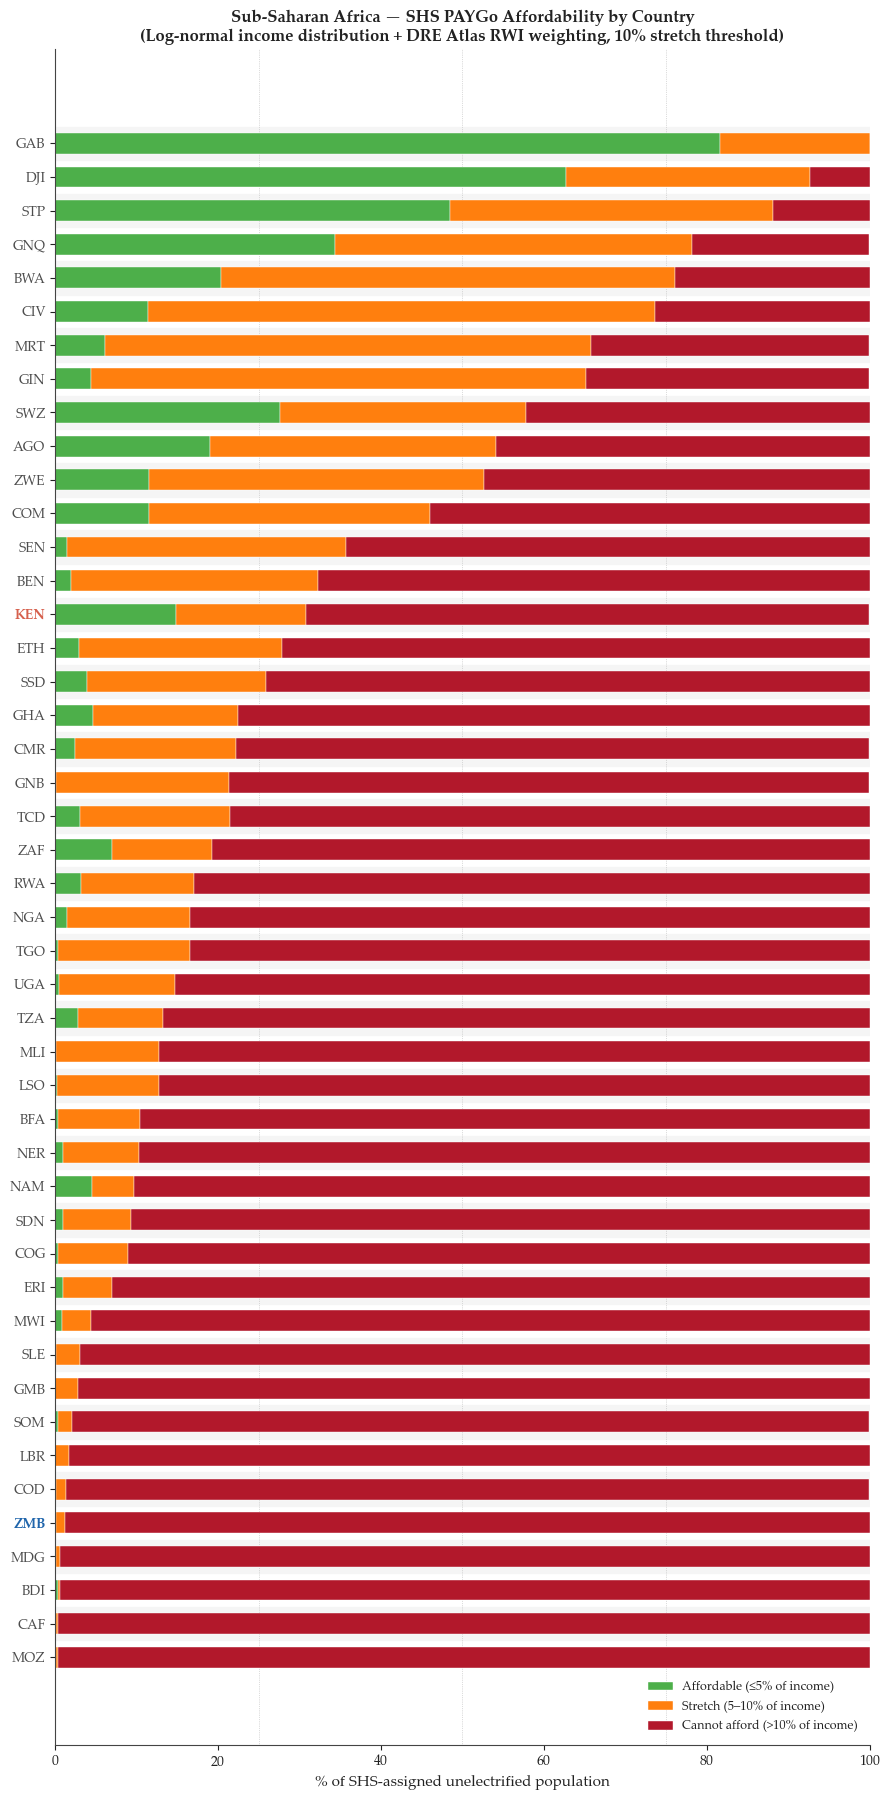

In [35]:
COL_AFFORD  = '#4DAF4A'   # green
COL_STRETCH = '#FF7F0E'   # orange
COL_CANNOT  = '#B2182B'   # red

plot_df = aff_ln_dre_df.copy()
plot_df = plot_df.sort_values('pct_cannot_afford_ln_dre', ascending=True).reset_index(drop=True)

n = len(plot_df)
y = np.arange(n)

fig, ax = plt.subplots(figsize=(9, 0.35 * n + 2))

left = np.zeros(n)
for col, color, label in [
    ('pct_affordable_ln_dre',    COL_AFFORD,  'Affordable (≤5% of income)'),
    ('pct_stretch_ln_dre',       COL_STRETCH, 'Stretch (5–10% of income)'),
    ('pct_cannot_afford_ln_dre', COL_CANNOT,  'Cannot afford (>10% of income)'),
]:
    vals = plot_df[col].values
    ax.barh(y, vals, left=left, height=0.62, color=color,
            edgecolor='white', linewidth=0.3, label=label)
    left += vals

# reference gridlines
for x in [0, 25, 50, 75, 100]:
    ax.axvline(x, color='#BBBBBB', linewidth=0.5, zorder=0, linestyle=':')

# zebra striping
for i in range(0, n, 2):
    ax.axhspan(i - 0.5, i + 0.5, color='#F5F5F5', zorder=-1)

ax.invert_yaxis()

# y-tick labels, now using ISO3 codes, with Kenya/Zambia bolded and coloured
ax.set_yticks(y)
labels = ax.set_yticklabels(plot_df['ISO3'])
for lbl, iso in zip(labels, plot_df['ISO3']):
    if iso in highlight:
        lbl.set_color(highlight[iso])
        lbl.set_fontweight('bold')
    else:
        lbl.set_color(LABEL_COLOR)

ax.set_xlim(0, 100)
ax.set_xlabel('% of SHS-assigned unelectrified population', fontsize=11)
ax.set_title(
    'Sub-Saharan Africa — SHS PAYGo Affordability by Country\n'
    '(Log-normal income distribution + DRE Atlas RWI weighting, 10% stretch threshold)',
    fontsize=12, fontweight='bold'
)
ax.legend(loc='lower right', frameon=False, fontsize=9)
ax.spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.savefig(FIG_DIR / 'fig_affordability_ln_dre_by_country.pdf', dpi=300, bbox_inches='tight')
plt.show()

In [ ]:
gogla_compare = pd.read_excel(
    GOGLA_PATH,
    sheet_name='Comparison'
)

# Drop the blank/footer rows (aggregate row + notes row at the bottom)
gogla_compare = gogla_compare.dropna(subset=['Economy'])
gogla_compare = gogla_compare[gogla_compare['Economy'] != 'SSA AGGREGATE']

# Map country names to ISO3 (reuse my existing name_to_iso mapping, or iso_to_name inverted)
name_to_iso = {v: k for k, v in iso_to_name.items()}
# add any GOGLA-specific naming overrides if needed, e.g.:
name_to_iso.update({
    "Côte d'Ivoire": 'CIV',
    'Democratic Republic of the Congo': 'COD',
    'Republic of Congo': 'COG',
    'The Gambia': 'GMB',
    'Sao Tome and Principe': 'STP',
})
gogla_compare['ISO3'] = gogla_compare['Economy'].map(name_to_iso)

print(gogla_compare[['Economy','ISO3']].to_string(index=False))

                                                                                                                                                                                                                                                                                                                                                                                                                 Economy ISO3
                                                                                                                                                                                                                                                                                                                                                                                                              Mozambique  MOZ
                                                                                                                                                                            

In [37]:
for label, df, cannot_col in [
    ('Log-normal, no DRE',     aff_ln_df,      'pct_cannot_afford_ln'),
    ('Log-normal + DRE',       aff_ln_dre_df,  'pct_cannot_afford_ln_dre'),
    ('PIP, no DRE',            aff_pip_df,     'pct_cannot_afford_pip'),
    ('PIP + DRE',              aff_pip_dre_df, 'pct_cannot_afford_pip_dre'),
]:
    comp = df.merge(
        gogla_compare[['ISO3', 'GOGLA: Cannot %']],
        on='ISO3', how='inner'
    )
    comp['GOGLA_pct'] = comp['GOGLA: Cannot %'] * 100  # sheet stores as fraction (e.g. 0.777)
    comp['diff'] = comp[cannot_col] - comp['GOGLA_pct']
    print(f"{label:<22} mean abs diff vs GOGLA: {comp['diff'].abs().mean():.1f}pp  (n={len(comp)})")

Log-normal, no DRE     mean abs diff vs GOGLA: 17.9pp  (n=41)
Log-normal + DRE       mean abs diff vs GOGLA: 32.3pp  (n=41)
PIP, no DRE            mean abs diff vs GOGLA: 14.4pp  (n=41)
PIP + DRE              mean abs diff vs GOGLA: 19.7pp  (n=41)


In [38]:
mtf_no_access = {
    'ZMB': {'Q1': 93.0, 'Q2': 80.5, 'Q3': 73.7, 'Q4': 34.8, 'Q5': 5.9},
    'KEN': {'Q1': 58.4, 'Q2': 39.2, 'Q3': 33.1, 'Q4': 25.0, 'Q5': 19.9},
}

mtf_unelec_share = {}
for iso, quintiles in mtf_no_access.items():
    total = sum(quintiles.values())
    mtf_unelec_share[iso] = {q: v / total for q, v in quintiles.items()}

print("MTF-derived unelec_share weights:")
for iso, shares in mtf_unelec_share.items():
    print(f"  {iso}: " + "  ".join(f"{q}={v:.4f}" for q, v in shares.items()))

print("\nDRE Atlas unelec_share weights (for comparison):")
for iso in ['ZMB', 'KEN']:
    dre_row = dre_df.loc[iso]
    print(f"  {iso}: " + "  ".join(
        f"{q}={dre_row.get(f'unelec_share_{q}', float('nan')):.4f}" for q in ['Q1','Q2','Q3','Q4','Q5']
    ))

MTF-derived unelec_share weights:
  ZMB: Q1=0.3230  Q2=0.2796  Q3=0.2560  Q4=0.1209  Q5=0.0205
  KEN: Q1=0.3326  Q2=0.2232  Q3=0.1885  Q4=0.1424  Q5=0.1133

DRE Atlas unelec_share weights (for comparison):
  ZMB: Q1=0.9131  Q2=0.5834  Q3=0.0747  Q4=0.0134  Q5=0.0015
  KEN: Q1=0.5665  Q2=0.0502  Q3=0.0663  Q4=0.0840  Q5=0.0115


In [39]:
def run_mtf_weighted_affordability(iso, unelec_share):
    percentiles = percentiles_cache[iso]  # cached, population-scaled n_sim from main cell

    w_affordable = w_stretch = w_cannot = total_weight = 0.0
    for q_idx, q_label in enumerate(['Q1', 'Q2', 'Q3', 'Q4', 'Q5']):
        unelec_w = unelec_share[q_label]
        for p in range(q_idx * 20, q_idx * 20 + 20):  # 0-indexed into cached percentile array
            inc            = percentiles[p]
            bill_share_pct = (monthly_paygo / inc) * 100
            if bill_share_pct <= ENERGY_LOW * 100:
                w_affordable += unelec_w
            elif bill_share_pct <= ENERGY_HIGH * 100:
                w_stretch += unelec_w
            else:
                w_cannot += unelec_w
            total_weight += unelec_w

    return {
        'ISO3': iso,
        'pct_affordable_mtf':    round(w_affordable / total_weight * 100, 1),
        'pct_stretch_mtf':       round(w_stretch    / total_weight * 100, 1),
        'pct_cannot_afford_mtf': round(w_cannot     / total_weight * 100, 1),
    }

mtf_results = pd.DataFrame([run_mtf_weighted_affordability(iso, shares)
                            for iso, shares in mtf_unelec_share.items()])
print("\nMTF-weighted affordability results:")
print(mtf_results.to_string(index=False))


MTF-weighted affordability results:
ISO3  pct_affordable_mtf  pct_stretch_mtf  pct_cannot_afford_mtf
 ZMB                 1.8             13.6                   84.6
 KEN                31.2             37.2                   31.6


In [40]:
def run_pip_mtf_weighted_affordability(iso, unelec_share):
    sub = pip_raw[pip_raw['country_code'] == iso]
    if len(sub) == 0:
        print(f"{iso}: not in PIP file — skipped")
        return None

    latest_year = sub['year'].max()
    sub = sub[sub['year'] == latest_year].sort_values('percentile')
    if len(sub) < 100:
        print(f"{iso}: incomplete percentile data ({len(sub)} rows) — skipped")
        return None

    w_affordable = w_stretch = w_cannot = total_weight = 0.0

    for q_idx, q_label in enumerate(['Q1', 'Q2', 'Q3', 'Q4', 'Q5']):
        unelec_w = unelec_share[q_label]
        q_data = sub[(sub['percentile'] >= q_idx * 20 + 1) &
                     (sub['percentile'] <= q_idx * 20 + 20)]
        if len(q_data) == 0:
            continue

        for _, prow in q_data.iterrows():
            monthly_inc    = prow['avg_welfare'] * 30.44
            bill_share_pct = (monthly_paygo / monthly_inc) * 100

            if bill_share_pct <= ENERGY_LOW * 100:
                w_affordable += unelec_w
            elif bill_share_pct <= ENERGY_HIGH * 100:
                w_stretch += unelec_w
            else:
                w_cannot += unelec_w
            total_weight += unelec_w

    return {
        'ISO3':                      iso,
        'pip_year':                  latest_year,
        'pct_affordable_pip_mtf':    round(w_affordable / total_weight * 100, 1),
        'pct_stretch_pip_mtf':       round(w_stretch    / total_weight * 100, 1),
        'pct_cannot_afford_pip_mtf': round(w_cannot     / total_weight * 100, 1),
    }

pip_mtf_results = pd.DataFrame([
    r for r in (run_pip_mtf_weighted_affordability(iso, shares)
                for iso, shares in mtf_unelec_share.items())
    if r is not None
])
print("PIP + MTF weighted affordability results:")
print(pip_mtf_results.to_string(index=False))

# ── Proximity to GOGLA for KEN/ZMB ───────────────────────────────────────────
comp = pip_mtf_results.merge(
    gogla_compare[['ISO3', 'GOGLA: Cannot %']], on='ISO3', how='inner'
)
comp['GOGLA_pct'] = comp['GOGLA: Cannot %'] * 100
comp['diff_pp']   = comp['pct_cannot_afford_pip_mtf'] - comp['GOGLA_pct']

print("\nPIP + MTF vs GOGLA (Kenya/Zambia):")
print(comp[['ISO3', 'pct_cannot_afford_pip_mtf', 'GOGLA_pct', 'diff_pp']].to_string(index=False))
print(f"\nMean abs diff vs GOGLA: {comp['diff_pp'].abs().mean():.1f}pp  (n={len(comp)})")

PIP + MTF weighted affordability results:
ISO3  pip_year  pct_affordable_pip_mtf  pct_stretch_pip_mtf  pct_cannot_afford_pip_mtf
 ZMB      2022                     1.4                  9.1                       89.5
 KEN      2022                    15.6                 35.5                       48.9

PIP + MTF vs GOGLA (Kenya/Zambia):
ISO3  pct_cannot_afford_pip_mtf  GOGLA_pct    diff_pp
 ZMB                       89.5  73.076923  16.423077
 KEN                       48.9  73.076923 -24.176923

Mean abs diff vs GOGLA: 20.3pp  (n=2)


In [41]:
sdg7_raw = pd.read_excel(
    SDG7_PATH,
    sheet_name='Quintiles by Country', header=2
)
sdg7_raw.columns = ['Country', 'Region', 'Year', 'Q1', 'Q2', 'Q3', 'Q4', 'Q5',
                     'Ratio', 'Female', 'Male', 'Page']
sdg7_raw = sdg7_raw.dropna(subset=['Country'])
sdg7_raw = sdg7_raw[sdg7_raw['Q1'] != 'No data']
for c in ['Q1', 'Q2', 'Q3', 'Q4', 'Q5']:
    sdg7_raw[c] = pd.to_numeric(sdg7_raw[c], errors='coerce')

sdg7_ssa = sdg7_raw[sdg7_raw['Region'] == 'Sub-Saharan Africa']
ssa_pooled_access = sdg7_ssa[['Q1', 'Q2', 'Q3', 'Q4', 'Q5']].mean()

ssa_pooled_no_access = 1 - ssa_pooled_access
ssa_pooled_unelec_share = (ssa_pooled_no_access / ssa_pooled_no_access.sum()).to_dict()

print(f"SSA-pooled access-deficit fallback (n={len(sdg7_ssa)} countries):")
print("  Access rate by quintile:      " +
      "  ".join(f"{q}={v:.3f}" for q, v in ssa_pooled_access.items()))
print("  Unelec share (renormalized):  " +
      "  ".join(f"{q}={v:.4f}" for q, v in ssa_pooled_unelec_share.items()))

SSA-pooled access-deficit fallback (n=14 countries):
  Access rate by quintile:      Q1=0.061  Q2=0.092  Q3=0.137  Q4=0.229  Q5=0.479
  Unelec share (renormalized):  Q1=0.2346  Q2=0.2269  Q3=0.2156  Q4=0.1926  Q5=0.1303


In [42]:
tariff_raw = pd.read_excel(TARIFF_PATH, sheet_name='US')

country_to_iso3 = {
    'Angola': 'AGO', 'Benin': 'BEN', 'Botswana': 'BWA', 'Burkina Faso': 'BFA',
    'Burundi': 'BDI', 'Central African Republic': 'CAF', 'Cabo Verde': 'CPV',
    'Cameroon': 'CMR', 'Chad': 'TCD', 'Comoros': 'COM', "Cote d'Ivoire": 'CIV',
    "Côte d'Ivoire": 'CIV', 'Democratic Republic of the Congo': 'COD',
    'Equatorial Guinea': 'GNQ', 'Eritrea': 'ERI', 'Eswatini': 'SWZ',
    'Ethiopia': 'ETH', 'Gabon': 'GAB', 'Gambia': 'GMB', 'Ghana': 'GHA',
    'Guinea': 'GIN', 'Guinea-Bissau': 'GNB', 'Kenya': 'KEN', 'Lesotho': 'LSO',
    'Liberia': 'LBR', 'Madagascar': 'MDG', 'Malawi': 'MWI', 'Mali': 'MLI',
    'Mauritania': 'MRT', 'Mauritius': 'MUS', 'Mozambique': 'MOZ',
    'Namibia': 'NAM', 'Niger': 'NER', 'Nigeria': 'NGA',
    'Republic of the Congo': 'COG', 'Rwanda': 'RWA', 'Senegal': 'SEN',
    'Seychelles': 'SYC', 'Sierra Leone': 'SLE', 'Somalia': 'SOM',
    'South Africa': 'ZAF', 'South Sudan': 'SSD', 'Sudan': 'SDN',
    'São Tomé and Príncipe': 'STP', 'Sao Tome and Principe': 'STP',
    'Tanzania': 'TZA', 'Togo': 'TGO', 'Uganda': 'UGA', 'Zambia': 'ZMB',
    'Zimbabwe': 'ZWE',
}

tariff_raw['ISO3'] = tariff_raw['Country'].map(country_to_iso3)
unmatched = tariff_raw[tariff_raw['ISO3'].isna()]['Country'].dropna().unique()
if len(unmatched) > 0:
    print(f"WARNING — unmatched country names, check spelling in country_to_iso3: {list(unmatched)}")

tariff_raw = tariff_raw.dropna(subset=['ISO3'])

grid_tariffs_ssa = {
    row['ISO3']: {'T4': row['Tier 4'], 'T5': row['Tier 5']}
    for _, row in tariff_raw.iterrows()
}
print(f"Loaded grid tariffs for {len(grid_tariffs_ssa)} countries from {TARIFF_PATH}")

US_CPI_RATES = {
    2015: 0.007, 2016: 0.021, 2017: 0.021, 2018: 0.019, 2019: 0.023,
    2020: 0.014, 2021: 0.07,  2022: 0.065, 2023: 0.034,
    2024: 0.029,
    2025: 0.027,
}
INFLATE_2024_TO_2025 = 1 + US_CPI_RATES[2025]  # 1.027

grid_tariffs_ssa_2025 = {
    iso: {tier: round(price * INFLATE_2024_TO_2025, 4) for tier, price in tiers.items()}
    for iso, tiers in grid_tariffs_ssa.items()
}
monthly_paygo_2025 = round(monthly_paygo * INFLATE_2024_TO_2025, 4)

print(f"\nPAYGo: ${monthly_paygo:.2f} (2024) -> ${monthly_paygo_2025:.2f} (2025)")
print(f"Sample check — Kenya/Zambia/Ethiopia grid tariffs:")
for iso in ['KEN', 'ZMB', 'ETH']:
    old, new = grid_tariffs_ssa[iso], grid_tariffs_ssa_2025[iso]
    print(f"  {iso}: T4 ${old['T4']:.2f} -> ${new['T4']:.2f}   "
          f"T5 ${old['T5']:.2f} -> ${new['T5']:.2f}")

def run_dre_weighted_affordability_generic(iso, monthly_price,
                                            low=ENERGY_LOW, high=ENERGY_HIGH):
    """
    Log-normal income distribution (population-scaled, GNI/Gini-calibrated)
    weighted by DRE Atlas RWI unelectrified-quintile shares. Same method as
    the affordability cell's Method A, generalised to accept any price so
    grid and SHS results are directly comparable, country by country.

    AGO/SDN/SSD/SOM (DRE_PROXY) use the SSA-wide average quintile shares
    instead of their own (degenerate/thin-coverage) DRE data.
    """
    if iso not in dre_df.index:
        return None

    is_proxied = iso in DRE_PROXY
    dre_row = avg_dre_shares if is_proxied else dre_df.loc[iso]

    if iso in percentiles_cache:
        country_percentiles = percentiles_cache[iso]
    else:
        if iso not in gni_lookup.index or pd.isna(gni_lookup.loc[iso, 'gni_pc']):
            return None
        if iso not in gini_lookup.index or pd.isna(gini_lookup.loc[iso, 'gini']):
            return None
        gni_annual  = gni_lookup.loc[iso, 'gni_pc']
        mean_income = gni_annual / 12
        gini_target = gini_lookup.loc[iso, 'gini']
        n_sim = int(pop_lookup.loc[iso]) if (iso in pop_lookup.index and
                                              not pd.isna(pop_lookup.loc[iso])) else 100_000
        mean_log_income = np.log(mean_income) - 0.5 * SIGMA_INIT**2
        initial_dist = np.random.lognormal(mean_log_income, SIGMA_INIT, n_sim).astype(np.float32)
        try:
            adj_dist = adjust_distribution_to_target_gini(initial_dist, gini_target, mean_income)
        except Exception:
            return None
        country_percentiles = np.array([percentile_from_sorted(adj_dist, p) for p in range(1, 101)])
        percentiles_cache[iso] = country_percentiles
        del adj_dist, initial_dist

    w_affordable = w_stretch = w_cannot = total_weight = 0.0
    for q_idx, q_label in enumerate(['Q1', 'Q2', 'Q3', 'Q4', 'Q5']):
        unelec_w = dre_row.get(f'unelec_share_{q_label}', None)
        if unelec_w is None or pd.isna(unelec_w):
            continue
        for p in range(q_idx * 20 + 1, q_idx * 20 + 21):
            inc            = country_percentiles[p - 1]
            bill_share_pct = (monthly_price / inc) * 100
            if bill_share_pct <= low * 100:
                w_affordable += unelec_w
            elif bill_share_pct <= high * 100:
                w_stretch += unelec_w
            else:
                w_cannot += unelec_w
            total_weight += unelec_w

    if total_weight == 0:
        return None
    return {
        'pct_affordable_dre':    round(w_affordable / total_weight * 100, 1),
        'pct_stretch_dre':       round(w_stretch    / total_weight * 100, 1),
        'pct_cannot_afford_dre': round(w_cannot     / total_weight * 100, 1),
        'DRE_proxied':           is_proxied,
    }

grid_rows_2025 = []
for tier in ['T4', 'T5']:
    for iso in ssa_iso_list:
        if iso not in grid_tariffs_ssa_2025:
            continue
        result = run_dre_weighted_affordability_generic(iso, grid_tariffs_ssa_2025[iso][tier])
        if result:
            grid_rows_2025.append({'ISO3': iso, 'Tier': tier,
                                    'Price_USD': round(grid_tariffs_ssa_2025[iso][tier], 2), **result})
grid_dre_df_2025 = pd.DataFrame(grid_rows_2025)

shs_rows_2025 = []
for iso in dre_df.index:
    result = run_dre_weighted_affordability_generic(iso, monthly_paygo_2025)
    if result:
        shs_rows_2025.append({'ISO3': iso, 'Tier': 'SHS (PAYGo)',
                               'Price_USD': round(monthly_paygo_2025, 2), **result})
shs_dre_df_2025 = pd.DataFrame(shs_rows_2025)

full_comparison_2025 = pd.concat([shs_dre_df_2025, grid_dre_df_2025], ignore_index=True)
full_comparison_2025 = full_comparison_2025.sort_values(['ISO3', 'Tier'])
print("\nGrid (T4/T5) vs SHS PAYGo — DRE-weighted, 2025 USD basis:")
print(full_comparison_2025.to_string(index=False))

print(f"\nSSA-wide (unelectrified-today-weighted) headline affordability — 2025 USD basis:")
for tier_label in ['SHS (PAYGo)', 'T4', 'T5']:
    sub = full_comparison_2025[full_comparison_2025['Tier'] == tier_label].merge(
        unelec_today_df[['ISO3', 'unelectrified_today']], on='ISO3', how='left'
    )
    missing = sub[sub['unelectrified_today'].isna()]['ISO3'].tolist()
    if missing:
        print(f"  WARNING [{tier_label}] — no unelectrified_today for: {missing} (excluded)")
    sub = sub.dropna(subset=['unelectrified_today'])
    wc = (sub['pct_cannot_afford_dre'] * sub['unelectrified_today']).sum() / sub['unelectrified_today'].sum()
    n_proxied = sub['DRE_proxied'].sum()
    print(f"  {tier_label:<12}: {wc:.1f}% of unelectrified population cannot afford"
          + (f"  ({n_proxied} countries proxied)" if n_proxied else ""))

print(f"\nKenya / Zambia / Ethiopia detail:")
print(full_comparison_2025[full_comparison_2025['ISO3'].isin(['KEN', 'ZMB', 'ETH'])].to_string(index=False))

Loaded grid tariffs for 48 countries from c:\Users\USER\Documents\GitHub\SM_Dissertation\GEP Review Code\Raw Data\Summary_Electricity_Bills.xlsx

PAYGo: $7.75 (2024) -> $7.96 (2025)
Sample check — Kenya/Zambia/Ethiopia grid tariffs:
  KEN: T4 $19.12 -> $19.64   T5 $50.82 -> $52.20
  ZMB: T4 $2.71 -> $2.79   T5 $11.62 -> $11.93
  ETH: T4 $2.32 -> $2.38   T5 $9.49 -> $9.75

Grid (T4/T5) vs SHS PAYGo — DRE-weighted, 2025 USD basis:
ISO3        Tier  Price_USD  pct_affordable_dre  pct_stretch_dre  pct_cannot_afford_dre  DRE_proxied
 AGO SHS (PAYGo)       7.96                18.0             34.5                   47.5         True
 AGO          T4       1.14                96.2              3.8                    0.0         True
 AGO          T5       7.59                20.0             34.1                   46.0         True
 BDI SHS (PAYGo)       7.96                 0.3              0.0                   99.7        False
 BDI          T4      11.24                 0.3              0

In [ ]:
# Four-way comparison: 

PRICE_COMBO1 = 7.30
PRICE_OTHERS = 7.75
ENERGY_LOW, ENERGY_HIGH = 0.05, 0.10

wb_mtf = openpyxl.load_workbook(MTF_PATH, data_only=True)
ws = wb_mtf['Sheet1']
mtf_raw = {}
for row in ws.iter_rows(min_row=2, values_only=True):
    country = row[0]
    if not country:
        continue
    vals = row[1:6]
    if all(v is not None for v in vals) and country not in mtf_raw:
        mtf_raw[country] = vals
mtf_unelec_share = {c: [v / sum(vals) for v in vals] for c, vals in mtf_raw.items()}
avg_raw_rate = [sum(mtf_raw[c][q] for c in mtf_raw) / len(mtf_raw) for q in range(5)]
avg_unelec_share = [r / sum(avg_raw_rate) for r in avg_raw_rate]

name_map_country = {'Kenya':'Kenya','Zambia':'Zambia','Uganda':'Uganda','Ethiopia':'Ethiopia',
                     'Niger':'Niger','Sierra Leone':'Sierra Leone','Burundi':'Burundi','Nigeria':'Nigeria'}
for k in mtf_raw.keys():
    if 'Tom' in k: name_map_country[k] = 'Sao Tome and Principe'
mtf_countries_in_gogla_names = set(name_map_country.values())

dre_df = pd.read_csv(DRE_PATH).set_index('ISO3')
DRE_EXCLUDE = ['AGO', 'SDN', 'SSD', 'SOM']

def dre_shares_for(iso):
    if iso not in dre_df.index:
        return None
    row = dre_df.loc[iso]
    shares = [row.get(f'unelec_share_{q}', None) for q in ['Q1','Q2','Q3','Q4','Q5']]
    if any(s is None or pd.isna(s) for s in shares):
        return None
    return shares

wb_gogla = openpyxl.load_workbook(GOGLA_PATH, data_only=True)

def load_gogla_quintiles(sheet_name):
    ws = wb_gogla[sheet_name]
    out = {}
    for row in ws.iter_rows(min_row=2, values_only=True):
        country = row[0]
        if not country or 'Source' in str(country): continue
        q_vals = row[2:7]
        if all(v is not None for v in q_vals):
            out[country] = q_vals
    return out

gogla_5pct = load_gogla_quintiles('SSA Quintile Data (5pct)')
gogla_10pct = load_gogla_quintiles('SSA Quintile Data (10pct)')
gogla_raw_income = {}
for country in gogla_5pct:
    if country not in gogla_10pct: continue
    inc5 = [w/0.05 for w in gogla_5pct[country]]
    inc10 = [w/0.10 for w in gogla_10pct[country]]
    gogla_raw_income[country] = [(a+b)/2 for a,b in zip(inc5, inc10)]

ws_comp = wb_gogla['Comparison']
gogla_actual_5pct, gogla_actual_10pct = {}, {}
for row in ws_comp.iter_rows(min_row=2, values_only=True):
    country = row[0]
    if not country or country == 'SSA AGGREGATE': continue
    total, c5, c10 = row[1], row[2], row[3]
    if total:
        gogla_actual_5pct[country] = c5/total*100
        gogla_actual_10pct[country] = c10/total*100

ws_total = wb_gogla['SSA Total Unelectrified']
unelec_headcount = {}
for row in ws_total.iter_rows(min_row=2, values_only=True):
    country = row[0]
    if country: unelec_headcount[country] = row[3]

gogla_name_to_iso3 = {
    'Kenya':'KEN','Zambia':'ZMB','Uganda':'UGA','Ethiopia':'ETH','Niger':'NER','Sierra Leone':'SLE',
    'Burundi':'BDI','Nigeria':'NGA','Sao Tome and Principe':'STP','Namibia':'NAM','Madagascar':'MDG',
    'Eswatini':'SWZ','Liberia':'LBR','Benin':'BEN','Rwanda':'RWA','Mozambique':'MOZ','Burkina Faso':'BFA',
    'Democratic Republic of the Congo':'COD','Cameroon':'CMR','Zimbabwe':'ZWE',"Côte d'Ivoire":'CIV',
    'Chad':'TCD','Senegal':'SEN','Ghana':'GHA','Togo':'TGO','Mauritania':'MRT','South Africa':'ZAF',
    'Botswana':'BWA','Djibouti':'DJI','Gabon':'GAB','Comoros':'COM','The Gambia':'GMB','Lesotho':'LSO',
    'Tanzania':'TZA','Guinea':'GIN','Sudan':'SDN','Central African Republic':'CAF','Malawi':'MWI',
    'Republic of Congo':'COG','Guinea-Bissau':'GNB','Angola':'AGO','Mali':'MLI','South Sudan':'SSD',
}

def get_percentiles(iso):
    if iso in percentiles_cache:
        return percentiles_cache[iso]
    if iso not in gni_lookup.index or pd.isna(gni_lookup.loc[iso,'gni_pc']): return None
    if iso not in gini_lookup.index or pd.isna(gini_lookup.loc[iso,'gini']): return None
    gni_annual = gni_lookup.loc[iso,'gni_pc']
    mean_income = gni_annual/12
    gini_target = gini_lookup.loc[iso,'gini']
    n_sim = int(pop_lookup.loc[iso]) if (iso in pop_lookup.index and not pd.isna(pop_lookup.loc[iso])) else 100_000
    mean_log_income = np.log(mean_income) - 0.5*SIGMA_INIT**2
    initial_dist = np.random.lognormal(mean_log_income, SIGMA_INIT, n_sim).astype(np.float32)
    try:
        adj_dist = adjust_distribution_to_target_gini(initial_dist, gini_target, mean_income)
    except Exception:
        return None
    p = np.array([percentile_from_sorted(adj_dist, pp) for pp in range(1,101)])
    percentiles_cache[iso] = p
    del adj_dist, initial_dist
    return p

def classify_quintiles(incomes, shares, price):
    """5-point quintile-average classification (used for Combos 1, 2, 4).
    Normalizes by sum(shares) internally -- does NOT assume shares are
    pre-normalized to sum to 1 (DRE's raw unelec_share_Q1..Q5 values are
    not guaranteed to sum to 1, per the DRE cell's own header comment)."""
    w_a = w_s = w_c = 0.0
    total_w = sum(shares)
    for q in range(5):
        pct = (price/incomes[q])*100
        if pct <= ENERGY_LOW*100: w_a += shares[q]
        elif pct <= ENERGY_HIGH*100: w_s += shares[q]
        else: w_c += shares[q]
    return w_a/total_w*100, w_s/total_w*100, w_c/total_w*100

def classify_percentiles(percentiles, quintile_shares, price):
    """Full 100-percentile classification, quintile weight spread evenly
    across its 20 percentiles (exact cell 38 logic) -- used for Combo 3."""
    w_a = w_s = w_c = total_w = 0.0
    for q_idx in range(5):
        unelec_w = quintile_shares[q_idx]
        for p_idx in range(q_idx*20, q_idx*20+20):
            inc = percentiles[p_idx]
            pct = (price/inc)*100
            if pct <= ENERGY_LOW*100: w_a += unelec_w
            elif pct <= ENERGY_HIGH*100: w_s += unelec_w
            else: w_c += unelec_w
            total_w += unelec_w
    return w_a/total_w*100, w_s/total_w*100, w_c/total_w*100

results = {1: [], 2: [], 3: [], 4: []}

for gogla_country, iso in gogla_name_to_iso3.items():
    hc = unelec_headcount.get(gogla_country)
    if hc is None: continue

    mtf_shares = (mtf_unelec_share[[k for k,v in name_map_country.items() if v==gogla_country][0]]
                  if gogla_country in mtf_countries_in_gogla_names else avg_unelec_share)
    dre_shares = dre_shares_for(iso)

    if gogla_country in gogla_raw_income:
        a1,s1,c1 = classify_quintiles(gogla_raw_income[gogla_country], mtf_shares, PRICE_COMBO1)
        results[1].append((iso, gogla_country, a1,s1,c1, hc))

    percentiles = get_percentiles(iso)
    if percentiles is not None:
        own_quintile_avg = [percentiles[q*20:(q+1)*20].mean() for q in range(5)]
        a2,s2,c2 = classify_quintiles(own_quintile_avg, mtf_shares, PRICE_OTHERS)
        results[2].append((iso, gogla_country, a2,s2,c2, hc))

    if percentiles is not None and dre_shares is not None and iso not in DRE_EXCLUDE:
        a3,s3,c3 = classify_percentiles(percentiles, dre_shares, PRICE_OTHERS)
        results[3].append((iso, gogla_country, a3,s3,c3, hc))

    if gogla_country in gogla_raw_income and dre_shares is not None and iso not in DRE_EXCLUDE:
        a4,s4,c4 = classify_quintiles(gogla_raw_income[gogla_country], dre_shares, PRICE_OTHERS)
        results[4].append((iso, gogla_country, a4,s4,c4, hc))

labels = {
    1: f'Combo 1: GOGLA method + GOGLA data (MTF weights, ${PRICE_COMBO1:.2f})',
    2: f'Combo 2: GOGLA method + my data  (MTF weights, ${PRICE_OTHERS:.2f})',
    3: f'Combo 3: my method  + my data  (DRE weights, 100-pctile, ${PRICE_OTHERS:.2f})',
    4: f'Combo 4: my method  + GOGLA data (DRE weights, quintile, ${PRICE_OTHERS:.2f})',
}

print(f"{'Combination':<60}{'Afford%':>10}{'Stretch%':>10}{'Cannot%':>10}{'N':>6}")
print("-"*100)

ssa_total_hc = sum(unelec_headcount[c] for c in gogla_actual_10pct if c in unelec_headcount)
g5 = sum(gogla_actual_5pct[c]*unelec_headcount[c] for c in gogla_actual_5pct if c in unelec_headcount)/ssa_total_hc
g10 = sum(gogla_actual_10pct[c]*unelec_headcount[c] for c in gogla_actual_10pct if c in unelec_headcount)/ssa_total_hc
print(f"{'GOGLA Reported (ground truth): cannot@5%='+str(round(g5,1))+'  cannot@10%='+str(round(g10,1)):<60}"
      f"{'':>10}{'':>10}{'':>10}{len(unelec_headcount):>6}")

summary = {}
for combo_id, rows in results.items():
    total_hc = sum(r[5] for r in rows)
    wa = sum(r[2]*r[5] for r in rows)/total_hc
    ws_ = sum(r[3]*r[5] for r in rows)/total_hc
    wc = sum(r[4]*r[5] for r in rows)/total_hc
    summary[combo_id] = (wa, ws_, wc, len(rows))
    print(f"{labels[combo_id]:<60}{wa:>9.1f}%{ws_:>9.1f}%{wc:>9.1f}%{len(rows):>6}")

print(f"\nDeltas vs GOGLA reported (10% = 'cannot' bucket comparison):")
for combo_id in [1,2,3,4]:
    wc = summary[combo_id][2]
    print(f"  {labels[combo_id]}: {wc - g10:+.1f}pp")

Combination                                                    Afford%  Stretch%   Cannot%     N
----------------------------------------------------------------------------------------------------
GOGLA Reported (ground truth): cannot@5%=83.4  cannot@10%=54.0                                  44
Combo 1: GOGLA method + GOGLA data (MTF weights, $7.30)          10.3%     25.5%     64.2%    43
Combo 2: GOGLA method + Your data  (MTF weights, $7.75)          14.3%     20.1%     65.6%    43
Combo 3: Your method  + Your data  (DRE weights, 100-pctile, $7.75)      2.1%     13.3%     84.6%    40
Combo 4: Your method  + GOGLA data (DRE weights, quintile, $7.75)      1.6%     13.9%     84.5%    40

Deltas vs GOGLA reported (10% = 'cannot' bucket comparison):
  Combo 1: GOGLA method + GOGLA data (MTF weights, $7.30): +10.2pp
  Combo 2: GOGLA method + Your data  (MTF weights, $7.75): +11.5pp
  Combo 3: Your method  + Your data  (DRE weights, 100-pctile, $7.75): +30.5pp
  Combo 4: Your method  + GO

In [ ]:
PRICE_GOGLA, PRICE_my_METHOD = 7.30, 7.75
ENERGY_LOW, ENERGY_HIGH = 0.05, 0.10

ws = openpyxl.load_workbook(MTF_PATH, data_only=True)['Sheet1']
mtf_raw = {r[0]: r[1:6] for r in ws.iter_rows(min_row=2, values_only=True)
           if r[0] and all(v is not None for v in r[1:6])}
mtf_unelec_share = {c: [v / sum(q) for v in q] for c, q in mtf_raw.items()}
avg_raw = [sum(mtf_raw[c][i] for c in mtf_raw) / len(mtf_raw) for i in range(5)]
avg_unelec_share = [v / sum(avg_raw) for v in avg_raw]

name_map_country = {'Kenya': 'Kenya', 'Zambia': 'Zambia', 'Uganda': 'Uganda',
                     'Ethiopia': 'Ethiopia', 'Niger': 'Niger', 'Sierra Leone': 'Sierra Leone',
                     'Burundi': 'Burundi', 'Nigeria': 'Nigeria'}
name_map_country.update({c: 'Sao Tome and Principe' for c in mtf_raw if 'Tom' in c})

def mtf_shares_for(gogla_country):
    match = [k for k, v in name_map_country.items() if v == gogla_country]
    return mtf_unelec_share[match[0]] if match else avg_unelec_share

dre_df = pd.read_csv(DRE_PATH).set_index('ISO3')
DRE_PROXY = ['AGO', 'SDN', 'SSD', 'SOM']  # degenerate/thin-coverage -> proxied, not dropped
q_cols = [f'unelec_share_{q}' for q in ['Q1', 'Q2', 'Q3', 'Q4', 'Q5']]

_reliable = dre_df.drop(index=[i for i in DRE_PROXY if i in dre_df.index]).dropna(subset=q_cols)
_w = _reliable['total_pop']
avg_dre_shares = [(_reliable[c] * _w).sum() / _w.sum() for c in q_cols]

def dre_shares_for(iso):
    if iso in DRE_PROXY:
        return avg_dre_shares
    if iso not in dre_df.index or dre_df.loc[iso, q_cols].isna().any():
        return None
    return dre_df.loc[iso, q_cols].tolist()

wb = openpyxl.load_workbook(GOGLA_PATH, data_only=True)

def load_gogla_quintiles(sheet):
    return {r[0]: r[2:7] for r in wb[sheet].iter_rows(min_row=2, values_only=True)
            if r[0] and 'Source' not in str(r[0]) and all(v is not None for v in r[2:7])}

g5, g10 = load_gogla_quintiles('SSA Quintile Data (5pct)'), load_gogla_quintiles('SSA Quintile Data (10pct)')
gogla_raw_income = {c: [(a/0.05 + b/0.10) / 2 for a, b in zip(g5[c], g10[c])]
                    for c in g5 if c in g10}

comp = wb['Comparison']
gogla_actual_5pct, gogla_actual_10pct, unelec_headcount = {}, {}, {}
for r in comp.iter_rows(min_row=2, values_only=True):
    if r[0] and r[0] != 'SSA AGGREGATE' and r[1]:
        gogla_actual_5pct[r[0]]  = r[2] / r[1] * 100
        gogla_actual_10pct[r[0]] = r[3] / r[1] * 100
for r in wb['SSA Total Unelectrified'].iter_rows(min_row=2, values_only=True):
    if r[0] and r[3] is not None:
        unelec_headcount[r[0]] = r[3]

gogla_name_to_iso3 = {  # unchanged from my original
    'Kenya':'KEN','Zambia':'ZMB','Uganda':'UGA','Ethiopia':'ETH','Niger':'NER','Sierra Leone':'SLE',
    'Burundi':'BDI','Nigeria':'NGA','Sao Tome and Principe':'STP','Namibia':'NAM','Madagascar':'MDG',
    'Eswatini':'SWZ','Liberia':'LBR','Benin':'BEN','Rwanda':'RWA','Mozambique':'MOZ','Burkina Faso':'BFA',
    'Democratic Republic of the Congo':'COD','Cameroon':'CMR','Zimbabwe':'ZWE',"Côte d'Ivoire":'CIV',
    'Chad':'TCD','Senegal':'SEN','Ghana':'GHA','Togo':'TGO','Mauritania':'MRT','South Africa':'ZAF',
    'Botswana':'BWA','Djibouti':'DJI','Gabon':'GAB','Comoros':'COM','The Gambia':'GMB','Lesotho':'LSO',
    'Tanzania':'TZA','Guinea':'GIN','Sudan':'SDN','Central African Republic':'CAF','Malawi':'MWI',
    'Republic of Congo':'COG','Guinea-Bissau':'GNB','Angola':'AGO','Mali':'MLI','South Sudan':'SSD',
}

def get_percentiles(iso):
    if iso in percentiles_cache:
        return percentiles_cache[iso]
    if iso not in gni_lookup.index or pd.isna(gni_lookup.loc[iso, 'gni_pc']): return None
    if iso not in gini_lookup.index or pd.isna(gini_lookup.loc[iso, 'gini']): return None
    mean_income = gni_lookup.loc[iso, 'gni_pc'] / 12
    n_sim = int(pop_lookup.loc[iso]) if (iso in pop_lookup.index and not pd.isna(pop_lookup.loc[iso])) else 100_000
    dist = np.random.lognormal(np.log(mean_income) - 0.5*SIGMA_INIT**2, SIGMA_INIT, n_sim).astype(np.float32)
    try:
        dist = adjust_distribution_to_target_gini(dist, gini_lookup.loc[iso, 'gini'], mean_income)
    except Exception:
        return None
    p = np.array([percentile_from_sorted(dist, pp) for pp in range(1, 101)])
    percentiles_cache[iso] = p
    return p

def classify_quintiles(incomes, weights, price):
    total = sum(weights)
    a = s = c = 0.0
    for inc, w in zip(incomes, weights):
        if inc is None or pd.isna(inc) or inc <= 0: return None
        share = price / inc
        a, s, c = (a + w, s, c) if share <= ENERGY_LOW else \
                  (a, s + w, c) if share <= ENERGY_HIGH else (a, s, c + w)
    return a/total*100, s/total*100, c/total*100

def classify_percentiles(percentiles, weights, price):
    a = s = c = total = 0.0
    for q, w in enumerate(weights):
        for p in percentiles[q*20:(q+1)*20]:
            if p is None or pd.isna(p) or p <= 0: return None
            share = price / p
            if share <= ENERGY_LOW: a += w
            elif share <= ENERGY_HIGH: s += w
            else: c += w
            total += w
    return a/total*100, s/total*100, c/total*100

scenarios = {
    1: {'income': 'gogla',         'weights': 'mtf', 'price': PRICE_GOGLA,      'label': 'GOGLA method + GOGLA data + MTF'},
    2: {'income': 'own_quintile',  'weights': 'mtf', 'price': PRICE_my_METHOD,'label': 'GOGLA method + my data (quintile avg) + MTF'},
    3: {'income': 'own_percentile','weights': 'dre', 'price': PRICE_my_METHOD,'label': 'my method + my data + DRE'},
    4: {'income': 'gogla',         'weights': 'dre', 'price': PRICE_my_METHOD,'label': 'my method + GOGLA data + DRE'},
    5: {'income': 'gogla',         'weights': 'mtf', 'price': PRICE_my_METHOD,'label': 'my method + GOGLA data + MTF'},
    6: {'income': 'own_percentile','weights': 'mtf', 'price': PRICE_my_METHOD,'label': 'my method + my data + MTF'},
}

def run_scenario(cfg):
    rows = []
    for gogla_country, iso in gogla_name_to_iso3.items():
        hc = unelec_headcount.get(gogla_country)
        if hc is None:
            continue

        if cfg['income'] == 'gogla':
            income = gogla_raw_income.get(gogla_country)
        else:
            p = get_percentiles(iso)
            if p is None:
                continue
            income = [p[q*20:(q+1)*20].mean() for q in range(5)] if cfg['income'] == 'own_quintile' else p
        if income is None:
            continue

        weights = mtf_shares_for(gogla_country) if cfg['weights'] == 'mtf' else dre_shares_for(iso)
        if weights is None:
            continue

        fn = classify_percentiles if cfg['income'] == 'own_percentile' else classify_quintiles
        result = fn(income, weights, cfg['price'])
        if result is None:
            continue
        rows.append((iso, gogla_country, *result, hc))
    return rows

results = {sid: run_scenario(cfg) for sid, cfg in scenarios.items()}

bench = [c for c in gogla_actual_10pct if c in unelec_headcount]
total_hc = sum(unelec_headcount[c] for c in bench)
gogla_5  = sum(gogla_actual_5pct[c]  * unelec_headcount[c] for c in bench if c in gogla_actual_5pct) / total_hc
gogla_10 = sum(gogla_actual_10pct[c] * unelec_headcount[c] for c in bench) / total_hc
print(f"GOGLA reported benchmark: cannot@5%={gogla_5:.1f}%  cannot@10%={gogla_10:.1f}%\n")

summary = {}
print(f"{'ID':<4}{'Scenario':<48}{'Price':>7}{'Afford':>9}{'Stretch':>9}{'Cannot':>9}{'Δ@5%':>9}{'Δ@10%':>9}{'N':>5}")
for sid, cfg in scenarios.items():
    rows = results[sid]
    if not rows:
        print(f"{sid:<4}{cfg['label']:<48}{'':>7}{'no data':>34}")
        continue
    hc_sum = sum(r[5] for r in rows)
    a = sum(r[2]*r[5] for r in rows) / hc_sum
    s = sum(r[3]*r[5] for r in rows) / hc_sum
    c = sum(r[4]*r[5] for r in rows) / hc_sum
    cannot_at_5  = s + c          # anyone needing more than 5% of income -> cannot afford at 5% threshold
    cannot_at_10 = c              # anyone needing more than 10% of income -> cannot afford at 10% threshold
    delta_5  = cannot_at_5  - gogla_5
    delta_10 = cannot_at_10 - gogla_10
    summary[sid] = {'a': a, 's': s, 'c': c, 'n': len(rows), 'delta_5': delta_5, 'delta_10': delta_10}
    print(f"{sid:<4}{cfg['label']:<48}${cfg['price']:>5.2f}{a:>8.1f}%{s:>8.1f}%{c:>8.1f}%{delta_5:>+8.1f}pp{delta_10:>+8.1f}pp{len(rows):>5}")

print("\nKey controlled comparisons:")
if 4 in summary and 5 in summary:
    print(f"  Weight effect (GOGLA data, quintile):  DRE vs MTF = {summary[4]['c']-summary[5]['c']:+.1f}pp")
if 3 in summary and 6 in summary:
    print(f"  Weight effect (my data, percentile): DRE vs MTF = {summary[3]['c']-summary[6]['c']:+.1f}pp")
if 1 in summary and 5 in summary:
    print(f"  Price effect (GOGLA data, MTF):  $7.30 vs $7.75 = {summary[5]['c']-summary[1]['c']:+.1f}pp")

print(f"\nGap between my method and GOGLA's reported benchmark:")
for sid, cfg in scenarios.items():
    if sid in summary:
        print(f"  Scenario {sid} ({cfg['label']}): "
              f"Δ@5%={summary[sid]['delta_5']:+.1f}pp (vs {gogla_5:.1f}%)  "
              f"Δ@10%={summary[sid]['delta_10']:+.1f}pp (vs {gogla_10:.1f}%)")

GOGLA reported benchmark: cannot@5%=83.4%  cannot@10%=54.0%

ID  Scenario                                          Price   Afford  Stretch   Cannot     Δ@5%    Δ@10%    N
1   GOGLA method + GOGLA data + MTF                 $ 7.30    10.3%    25.5%    64.2%    +6.3pp   +10.2pp   43
2   GOGLA method + your data (quintile avg) + MTF   $ 7.75    14.3%    20.1%    65.6%    +2.3pp   +11.5pp   43
3   Your method + your data + DRE                   $ 7.75     2.6%    13.9%    83.5%   +14.0pp   +29.4pp   43
4   Your method + GOGLA data + DRE                  $ 7.75     1.6%    14.5%    84.0%   +15.1pp   +29.9pp   43
5   Your method + GOGLA data + MTF                  $ 7.75     9.2%    25.1%    65.7%    +7.5pp   +11.7pp   43
6   Your method + your data + MTF                   $ 7.75    11.3%    23.7%    65.0%    +5.4pp   +11.0pp   43

Key controlled comparisons:
  Weight effect (GOGLA data, quintile):  DRE vs MTF = +18.2pp
  Weight effect (your data, percentile): DRE vs MTF = +18.5pp
  Price ef

In [45]:
# Kenya / Zambia detail across all six scenarios 
# Uses `results` and `scenarios` from the six-scenario comparison above.

CASE_STUDY_ISOS = ['KEN', 'ZMB']

print(f"{'Scenario':<48}{'ISO3':<6}{'Afford%':>10}{'Stretch%':>10}{'Cannot%':>10}")
print("-" * 88)

rows = []
for sid, cfg in scenarios.items():
    for iso, gogla_country, a, s, c, hc in results[sid]:
        if iso in CASE_STUDY_ISOS:
            print(f"{cfg['label']:<48}{iso:<6}{a:>9.1f}%{s:>9.1f}%{c:>9.1f}%")
            rows.append({'Scenario': cfg['label'], 'ISO3': iso,
                         'Afford%': round(a, 1), 'Stretch%': round(s, 1), 'Cannot%': round(c, 1)})
    print()

#Same, pivoted wide for easy side-by-side reading
case_study_df = pd.DataFrame(rows)
pivot_cannot = case_study_df.pivot(index='Scenario', columns='ISO3', values='Cannot%')
pivot_cannot = pivot_cannot.loc[[scenarios[sid]['label'] for sid in scenarios]]  # keep scenario order

print("Cannot-afford %, Kenya vs Zambia, side by side:")
print(pivot_cannot.to_string())

print(f"\nGOGLA reported actual (10% definition): KEN={gogla_actual_10pct.get('Kenya'):.1f}%  "
      f"ZMB={gogla_actual_10pct.get('Zambia'):.1f}%")
print(f"GOGLA reported actual (5% definition):  KEN={gogla_actual_5pct.get('Kenya'):.1f}%  "
      f"ZMB={gogla_actual_5pct.get('Zambia'):.1f}%")

Scenario                                        ISO3     Afford%  Stretch%   Cannot%
----------------------------------------------------------------------------------------
GOGLA method + GOGLA data + MTF                 KEN        11.3%     14.2%     74.4%
GOGLA method + GOGLA data + MTF                 ZMB         2.0%     12.1%     85.9%

GOGLA method + your data (quintile avg) + MTF   KEN        25.6%     41.2%     33.3%
GOGLA method + your data (quintile avg) + MTF   ZMB         2.0%     12.1%     85.9%

Your method + your data + DRE                   KEN        14.8%     16.0%     69.1%
Your method + your data + DRE                   ZMB         0.1%      1.1%     98.8%

Your method + GOGLA data + DRE                  KEN         1.5%     10.8%     87.7%
Your method + GOGLA data + DRE                  ZMB         0.1%      0.8%     99.1%

Your method + GOGLA data + MTF                  KEN        11.3%     14.2%     74.4%
Your method + GOGLA data + MTF                  ZMB      

In [46]:
# Grid vs SHS affordability — DRE- and MTF-weighted, all SSA countries


tariff_raw = pd.read_excel(TARIFF_PATH, sheet_name='US')

country_to_iso3 = {
    'Angola': 'AGO', 'Benin': 'BEN', 'Botswana': 'BWA', 'Burkina Faso': 'BFA',
    'Burundi': 'BDI', 'Central African Republic': 'CAF', 'Cabo Verde': 'CPV',
    'Cameroon': 'CMR', 'Chad': 'TCD', 'Comoros': 'COM', "Cote d'Ivoire": 'CIV',
    "Côte d'Ivoire": 'CIV', 'Democratic Republic of the Congo': 'COD',
    'Equatorial Guinea': 'GNQ', 'Eritrea': 'ERI', 'Eswatini': 'SWZ',
    'Ethiopia': 'ETH', 'Gabon': 'GAB', 'Gambia': 'GMB', 'Ghana': 'GHA',
    'Guinea': 'GIN', 'Guinea-Bissau': 'GNB', 'Kenya': 'KEN', 'Lesotho': 'LSO',
    'Liberia': 'LBR', 'Madagascar': 'MDG', 'Malawi': 'MWI', 'Mali': 'MLI',
    'Mauritania': 'MRT', 'Mauritius': 'MUS', 'Mozambique': 'MOZ',
    'Namibia': 'NAM', 'Niger': 'NER', 'Nigeria': 'NGA',
    'Republic of the Congo': 'COG', 'Rwanda': 'RWA', 'Senegal': 'SEN',
    'Seychelles': 'SYC', 'Sierra Leone': 'SLE', 'Somalia': 'SOM',
    'South Africa': 'ZAF', 'South Sudan': 'SSD', 'Sudan': 'SDN',
    'São Tomé and Príncipe': 'STP', 'Sao Tome and Principe': 'STP',
    'Tanzania': 'TZA', 'Togo': 'TGO', 'Uganda': 'UGA', 'Zambia': 'ZMB',
    'Zimbabwe': 'ZWE',
}

tariff_raw['ISO3'] = tariff_raw['Country'].map(country_to_iso3)
unmatched = tariff_raw[tariff_raw['ISO3'].isna()]['Country'].dropna().unique()
if len(unmatched) > 0:
    print(f"WARNING — unmatched country names, check spelling in country_to_iso3: {list(unmatched)}")
tariff_raw = tariff_raw.dropna(subset=['ISO3'])

grid_tariffs_ssa = {
    row['ISO3']: {'T4': row['Tier 4'], 'T5': row['Tier 5']}
    for _, row in tariff_raw.iterrows()
}
print(f"Loaded grid tariffs for {len(grid_tariffs_ssa)} countries from {TARIFF_PATH}")

US_CPI_RATES = {
    2015: 0.007, 2016: 0.021, 2017: 0.021, 2018: 0.019, 2019: 0.023,
    2020: 0.014, 2021: 0.07,  2022: 0.065, 2023: 0.034,
    2024: 0.029,
    2025: 0.027,
}
INFLATE_2024_TO_2025 = 1 + US_CPI_RATES[2025]  # 1.027

grid_tariffs_ssa_2025 = {
    iso: {tier: round(price * INFLATE_2024_TO_2025, 4) for tier, price in tiers.items()}
    for iso, tiers in grid_tariffs_ssa.items()
}

MONTHLY_PAYGO_2025 = 7.75   

print(f"\nPAYGo price (2025 basis, fixed): ${MONTHLY_PAYGO_2025:.2f}")
print(f"Sample check — Kenya/Zambia/Ethiopia grid tariffs (2025 USD):")
for iso in ['KEN', 'ZMB', 'ETH']:
    old, new = grid_tariffs_ssa[iso], grid_tariffs_ssa_2025[iso]
    print(f"  {iso}: T4 ${old['T4']:.2f} -> ${new['T4']:.2f}   "
          f"T5 ${old['T5']:.2f} -> ${new['T5']:.2f}")

def run_weighted_affordability_generic(iso, monthly_price, quintile_weights,
                                        low=ENERGY_LOW, high=ENERGY_HIGH):
    """
    Log-normal income distribution (population-scaled, GNI/Gini-calibrated),
    weighted by whatever quintile_weights are passed in (list/array of 5
    values, Q1..Q5, summing to 1). Same underlying income method for every
    call — only the price and quintile weighting source change between calls.
    """
    if iso not in percentiles_cache:
        if iso not in gni_lookup.index or pd.isna(gni_lookup.loc[iso, 'gni_pc']):
            return None
        if iso not in gini_lookup.index or pd.isna(gini_lookup.loc[iso, 'gini']):
            return None
        gni_annual  = gni_lookup.loc[iso, 'gni_pc']
        mean_income = gni_annual / 12
        gini_target = gini_lookup.loc[iso, 'gini']
        n_sim = int(pop_lookup.loc[iso]) if (iso in pop_lookup.index and
                                              not pd.isna(pop_lookup.loc[iso])) else 100_000
        mean_log_income = np.log(mean_income) - 0.5 * SIGMA_INIT**2
        initial_dist = np.random.lognormal(mean_log_income, SIGMA_INIT, n_sim).astype(np.float32)
        try:
            adj_dist = adjust_distribution_to_target_gini(initial_dist, gini_target, mean_income)
        except Exception:
            return None
        percentiles_cache[iso] = np.array(
            [percentile_from_sorted(adj_dist, p) for p in range(1, 101)]
        )
        del adj_dist, initial_dist

    country_percentiles = percentiles_cache[iso]

    w_affordable = w_stretch = w_cannot = total_weight = 0.0
    for q_idx in range(5):
        unelec_w = quintile_weights[q_idx]
        if unelec_w is None or pd.isna(unelec_w):
            continue
        for p in range(q_idx * 20 + 1, q_idx * 20 + 21):
            inc            = country_percentiles[p - 1]
            bill_share_pct = (monthly_price / inc) * 100
            if bill_share_pct <= low * 100:
                w_affordable += unelec_w
            elif bill_share_pct <= high * 100:
                w_stretch += unelec_w
            else:
                w_cannot += unelec_w
            total_weight += unelec_w

    if total_weight == 0:
        return None
    return {
        'pct_affordable':    round(w_affordable / total_weight * 100, 1),
        'pct_stretch':       round(w_stretch    / total_weight * 100, 1),
        'pct_cannot_afford': round(w_cannot     / total_weight * 100, 1),
    }

def dre_weights_for(iso):
    if iso in DRE_PROXY:
        return list(avg_dre_shares), True
    if iso not in dre_df.index:
        return None, None   # genuinely missing from DRE Atlas — not proxied, just absent
    dre_row = dre_df.loc[iso]
    weights = [dre_row.get(f'unelec_share_Q{q}', None) for q in range(1, 6)]
    return weights, False


ws = openpyxl.load_workbook(MTF_PATH, data_only=True)['Sheet1']
mtf_raw_by_name = {r[0]: r[1:6] for r in ws.iter_rows(min_row=2, values_only=True)
                   if r[0] and all(v is not None for v in r[1:6])}

mtf_weights_by_iso = {}
unmatched_mtf = []
for name, quintiles in mtf_raw_by_name.items():
    iso = country_to_iso3.get(name)
    if iso is None:
        unmatched_mtf.append(name)
        continue
    total = sum(quintiles)
    mtf_weights_by_iso[iso] = [v / total for v in quintiles]

if unmatched_mtf:
    print(f"\nWARNING — MTF country names not matched to ISO3, check country_to_iso3: {unmatched_mtf}")


_mtf_covered = [iso for iso in mtf_weights_by_iso if iso in unelec_today_df['ISO3'].values]
_hc = unelec_today_df.set_index('ISO3').loc[_mtf_covered, 'unelectrified_today']
avg_mtf_shares = [
    sum(mtf_weights_by_iso[iso][q] * _hc[iso] for iso in _mtf_covered) / _hc.sum()
    for q in range(5)
]

def mtf_weights_for(iso):
    if iso in mtf_weights_by_iso:
        return mtf_weights_by_iso[iso], False
    return avg_mtf_shares, True   # proxied with SSA average, same convention as DRE_PROXY

print(f"\nLoaded MTF quintile weights for {len(mtf_weights_by_iso)} countries from {MTF_PATH}")

def price_for(iso, tier):
    if tier == 'SHS (PAYGo)':
        return MONTHLY_PAYGO_2025
    if iso not in grid_tariffs_ssa_2025:
        return None
    return grid_tariffs_ssa_2025[iso][tier]

weighting_methods = {'DRE': dre_weights_for, 'MTF': mtf_weights_for}
tiers = ['SHS (PAYGo)', 'T4', 'T5']

all_rows = []
skipped = {}   # track which (iso, method) pairs got skipped and why

for tier in tiers:
    for method_name, weight_fn in weighting_methods.items():
        for iso in ssa_iso_list:
            price = price_for(iso, tier)
            if price is None:
                continue
            weights, is_proxied = weight_fn(iso)
            if weights is None:
                skipped.setdefault(method_name, []).append(iso)
                continue
            result = run_weighted_affordability_generic(iso, price, weights)
            if result is None:
                continue
            all_rows.append({
                'ISO3': iso,
                'Tier': tier,
                'Weighting': method_name,
                'Price_USD': round(price, 2),
                'Proxied': is_proxied,
                **result,
            })

full_comparison_2025 = pd.DataFrame(all_rows).sort_values(['ISO3', 'Tier', 'Weighting'])

for method_name, isos in skipped.items():
    print(f"WARNING — {method_name} weighting missing entirely for: {sorted(set(isos))}")

print("\nSHS PAYGo and Grid T4/T5 — DRE vs MTF weighting, $7.75 SHS price, 2025 USD basis:")
print(full_comparison_2025.to_string(index=False))

print(f"\nSSA-wide (unelectrified-today-weighted) headline affordability:")
for tier in tiers:
    for method_name in weighting_methods:
        sub = full_comparison_2025[
            (full_comparison_2025['Tier'] == tier) & (full_comparison_2025['Weighting'] == method_name)
        ].merge(unelec_today_df[['ISO3', 'unelectrified_today']], on='ISO3', how='left')

        missing = sub[sub['unelectrified_today'].isna()]['ISO3'].tolist()
        if missing:
            print(f"  WARNING [{tier} / {method_name}] — no unelectrified_today for: {missing} (excluded)")
        sub = sub.dropna(subset=['unelectrified_today'])
        wc = (sub['pct_cannot_afford'] * sub['unelectrified_today']).sum() / sub['unelectrified_today'].sum()
        n_proxied = sub['Proxied'].sum()
        print(f"  {tier:<12} / {method_name:<4}: {wc:.1f}% cannot afford"
              + (f"  ({n_proxied} countries proxied)" if n_proxied else ""))

print(f"\nKenya / Zambia / Ethiopia detail:")
print(full_comparison_2025[full_comparison_2025['ISO3'].isin(['KEN', 'ZMB', 'ETH'])].to_string(index=False))

Loaded grid tariffs for 48 countries from c:\Users\USER\Documents\GitHub\SM_Dissertation\GEP Review Code\Raw Data\Summary_Electricity_Bills.xlsx

PAYGo price (2025 basis, fixed): $7.75
Sample check — Kenya/Zambia/Ethiopia grid tariffs (2025 USD):
  KEN: T4 $19.12 -> $19.64   T5 $50.82 -> $52.20
  ZMB: T4 $2.71 -> $2.79   T5 $11.62 -> $11.93
  ETH: T4 $2.32 -> $2.38   T5 $9.49 -> $9.75

WARNING — MTF country names not matched to ISO3, check country_to_iso3: ['São Tomé & Príncipe']

Loaded MTF quintile weights for 8 countries from c:\Users\USER\Documents\GitHub\SM_Dissertation\GEP Review Code\Raw Data\MTF_quintiles.xlsx
WARNING — DRE weighting missing entirely for: ['CPV', 'MUS', 'SYC']

SHS PAYGo and Grid T4/T5 — DRE vs MTF weighting, $7.75 SHS price, 2025 USD basis:
ISO3        Tier Weighting  Price_USD  Proxied  pct_affordable  pct_stretch  pct_cannot_afford
 AGO SHS (PAYGo)       DRE       7.75     True            17.4         33.9               48.7
 AGO SHS (PAYGo)       MTF      

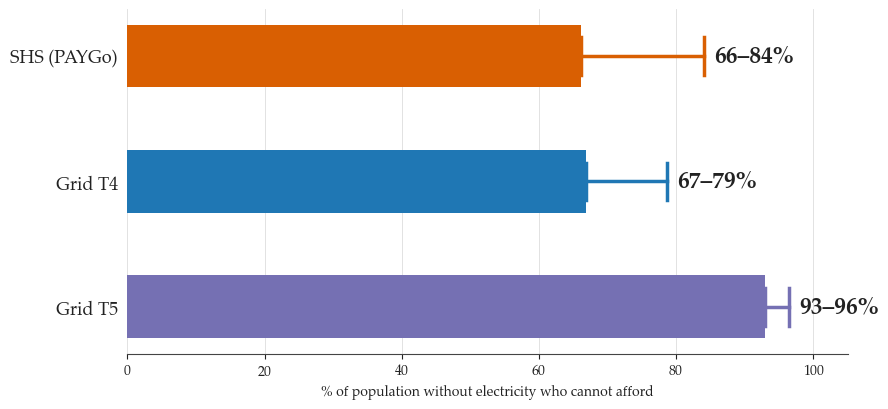

In [ ]:
plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.serif']  = ['Palatino', 'Palatino Linotype', 'DejaVu Serif']
plt.rcParams['axes.edgecolor']  = '#444444'
plt.rcParams['text.color']      = '#222222'
plt.rcParams['axes.labelcolor'] = '#222222'
plt.rcParams['xtick.color']     = '#222222'

row_order   = ['SHS (PAYGo)', 'T4', 'T5']
row_display = {'SHS (PAYGo)': 'SHS (PAYGo)', 'T4': 'Grid T4', 'T5': 'Grid T5'}

# colours aligned to my 3-panel choropleth: Oranges=SHS, Blues=T4, Purples=T5
colors = {'SHS (PAYGo)': '#d95f02',  # orange
          'T4':          '#1f77b4',  # blue
          'T5':          '#7570b3'}  # purple

# SSA-wide, unelectrified-today-weighted headline %, per tier + weighting 
def headline_pct(tier, weighting):
    sub = full_comparison_2025[
        (full_comparison_2025['Tier'] == tier) & (full_comparison_2025['Weighting'] == weighting)
    ].merge(unelec_today_df[['ISO3', 'unelectrified_today']], on='ISO3', how='left').dropna(subset=['unelectrified_today'])
    return (sub['pct_cannot_afford'] * sub['unelectrified_today']).sum() / sub['unelectrified_today'].sum()

headline_range = {
    tier: (headline_pct(tier, 'DRE'), headline_pct(tier, 'MTF'))
    for tier in row_order
}

# ── Plot ──────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(9, 4.2))
y_pos = np.arange(len(row_order))[::-1]

for y, tier in zip(y_pos, row_order):
    col = colors[tier]
    dre_val, mtf_val = headline_range[tier]
    lo, hi = min(dre_val, mtf_val), max(dre_val, mtf_val)

    # solid bar: 0 -> lower estimate only
    ax.barh(y, lo, color=col, height=0.5, zorder=3)

    # range lo -> hi shown as a line (not a shaded bar extension)
    ax.plot([lo, hi], [y, y], color=col, linewidth=2.5, zorder=4)
    # end caps at both endpoints
    for v in (lo, hi):
        ax.plot([v, v], [y - 0.15, y + 0.15], color=col, linewidth=2.5, zorder=4)

    ax.text(hi + 1.5, y, f'{lo:.0f}–{hi:.0f}%', va='center', fontsize=17, fontweight='bold', color='#222222')

ax.set_yticks(y_pos)
ax.set_yticklabels([row_display[t] for t in row_order], fontsize=13)
ax.set_xlim(0, 105)
ax.set_xlabel('% of population without electricity who cannot afford')
for spine in ['top', 'right', 'left']:
    ax.spines[spine].set_visible(False)
ax.tick_params(left=False)
ax.grid(axis='x', color='#dddddd', linewidth=0.6, zorder=0)

plt.tight_layout()
plt.savefig(FIG_DIR / 'fig_affordability_headline_ssa.pdf', dpi=600, bbox_inches='tight')
plt.savefig(FIG_DIR / 'fig_affordability_headline_ssa.png', dpi=600, bbox_inches='tight')
plt.show()
plt.close(fig)

In [48]:

tariff_raw = pd.read_excel(TARIFF_PATH, sheet_name='US')
tariff_raw['ISO3'] = tariff_raw['Country'].map(country_to_iso3)
tariff_raw = tariff_raw.dropna(subset=['ISO3'])

TIER_COLS = {'T1': 'Tier 1', 'T2': 'Tier 2', 'T3': 'Tier 3', 'T4': 'Tier 4', 'T5': 'Tier 5'}

grid_tariffs_ssa = {
    row['ISO3']: {tier: row[col] for tier, col in TIER_COLS.items()}
    for _, row in tariff_raw.iterrows()
}
print(f"Loaded grid tariffs (T1-T5) for {len(grid_tariffs_ssa)} countries from {TARIFF_PATH}")

US_CPI_RATES = {
    2015: 0.007, 2016: 0.021, 2017: 0.021, 2018: 0.019, 2019: 0.023,
    2020: 0.014, 2021: 0.07,  2022: 0.065, 2023: 0.034,
    2024: 0.029, 2025: 0.027,
}
INFLATE_2024_TO_2025 = 1 + US_CPI_RATES[2025]  # 1.027

grid_tariffs_ssa_2025 = {
    iso: {tier: round(price * INFLATE_2024_TO_2025, 4) for tier, price in tiers.items()}
    for iso, tiers in grid_tariffs_ssa.items()
}

MONTHLY_PAYGO_2025 = 7.75   

def run_weighted_affordability_generic(iso, monthly_price, quintile_weights,
                                        low=ENERGY_LOW, high=ENERGY_HIGH):
    if iso not in percentiles_cache:
        if iso not in gni_lookup.index or pd.isna(gni_lookup.loc[iso, 'gni_pc']):
            return None
        if iso not in gini_lookup.index or pd.isna(gini_lookup.loc[iso, 'gini']):
            return None
        gni_annual  = gni_lookup.loc[iso, 'gni_pc']
        mean_income = gni_annual / 12
        gini_target = gini_lookup.loc[iso, 'gini']
        n_sim = int(pop_lookup.loc[iso]) if (iso in pop_lookup.index and
                                              not pd.isna(pop_lookup.loc[iso])) else 100_000
        mean_log_income = np.log(mean_income) - 0.5 * SIGMA_INIT**2
        initial_dist = np.random.lognormal(mean_log_income, SIGMA_INIT, n_sim).astype(np.float32)
        try:
            adj_dist = adjust_distribution_to_target_gini(initial_dist, gini_target, mean_income)
        except Exception:
            return None
        percentiles_cache[iso] = np.array(
            [percentile_from_sorted(adj_dist, p) for p in range(1, 101)]
        )
        del adj_dist, initial_dist

    country_percentiles = percentiles_cache[iso]

    w_affordable = w_stretch = w_cannot = total_weight = 0.0
    for q_idx in range(5):
        unelec_w = quintile_weights[q_idx]
        if unelec_w is None or pd.isna(unelec_w):
            continue
        for p in range(q_idx * 20 + 1, q_idx * 20 + 21):
            inc            = country_percentiles[p - 1]
            bill_share_pct = (monthly_price / inc) * 100
            if bill_share_pct <= low * 100:
                w_affordable += unelec_w
            elif bill_share_pct <= high * 100:
                w_stretch += unelec_w
            else:
                w_cannot += unelec_w
            total_weight += unelec_w

    if total_weight == 0:
        return None
    return {
        'pct_affordable':    round(w_affordable / total_weight * 100, 1),
        'pct_stretch':       round(w_stretch    / total_weight * 100, 1),
        'pct_cannot_afford': round(w_cannot     / total_weight * 100, 1),
    }

def dre_weights_for(iso):
    if iso in DRE_PROXY:
        return list(avg_dre_shares), True
    if iso not in dre_df.index:
        return None, None
    dre_row = dre_df.loc[iso]
    weights = [dre_row.get(f'unelec_share_Q{q}', None) for q in range(1, 6)]
    return weights, False

ws = openpyxl.load_workbook(MTF_PATH, data_only=True)['Sheet1']
mtf_raw_by_name = {r[0]: r[1:6] for r in ws.iter_rows(min_row=2, values_only=True)
                   if r[0] and all(v is not None for v in r[1:6])}
mtf_weights_by_iso = {}
for name, quintiles in mtf_raw_by_name.items():
    iso = country_to_iso3.get(name)
    if iso is None:
        continue
    total = sum(quintiles)
    mtf_weights_by_iso[iso] = [v / total for v in quintiles]

_mtf_covered = [iso for iso in mtf_weights_by_iso if iso in unelec_today_df['ISO3'].values]
_hc = unelec_today_df.set_index('ISO3').loc[_mtf_covered, 'unelectrified_today']
avg_mtf_shares = [
    sum(mtf_weights_by_iso[iso][q] * _hc[iso] for iso in _mtf_covered) / _hc.sum()
    for q in range(5)
]

def mtf_weights_for(iso):
    if iso in mtf_weights_by_iso:
        return mtf_weights_by_iso[iso], False
    return avg_mtf_shares, True

def price_for(iso, tier):
    if tier == 'SHS (PAYGo)':
        return MONTHLY_PAYGO_2025
    if iso not in grid_tariffs_ssa_2025:
        return None
    return grid_tariffs_ssa_2025[iso][tier]

weighting_methods = {'DRE': dre_weights_for, 'MTF': mtf_weights_for}
tiers = ['T1', 'T2', 'T3', 'T4', 'T5', 'SHS (PAYGo)']

all_rows = []
skipped = {}

for tier in tiers:
    for method_name, weight_fn in weighting_methods.items():
        for iso in ssa_iso_list:
            price = price_for(iso, tier)
            if price is None:
                continue
            weights, is_proxied = weight_fn(iso)
            if weights is None:
                skipped.setdefault(method_name, []).append(iso)
                continue
            result = run_weighted_affordability_generic(iso, price, weights)
            if result is None:
                continue
            all_rows.append({
                'ISO3': iso, 'Tier': tier, 'Weighting': method_name,
                'Price_USD': round(price, 2), 'Proxied': is_proxied,
                **result,
            })

full_comparison_2025 = pd.DataFrame(all_rows).sort_values(['ISO3', 'Tier', 'Weighting'])

for method_name, isos in skipped.items():
    print(f"WARNING — {method_name} weighting missing entirely for: {sorted(set(isos))}")

def headline_pct(tier, weighting, metric='pct_cannot_afford'):
    sub = full_comparison_2025[
        (full_comparison_2025['Tier'] == tier) & (full_comparison_2025['Weighting'] == weighting)
    ].merge(unelec_today_df[['ISO3', 'unelectrified_today']], on='ISO3', how='left').dropna(subset=['unelectrified_today'])
    return (sub[metric] * sub['unelectrified_today']).sum() / sub['unelectrified_today'].sum()

grid_tier_order = ['T1', 'T2', 'T3', 'T4', 'T5']

headline_range = {
    tier: (headline_pct(tier, 'DRE'), headline_pct(tier, 'MTF'))
    for tier in grid_tier_order
}
shs_range = (headline_pct('SHS (PAYGo)', 'DRE'), headline_pct('SHS (PAYGo)', 'MTF'))

print("\nSSA-wide (unelectrified-today-weighted) % who CANNOT afford, by tier:")
for tier in grid_tier_order:
    lo, hi = sorted(headline_range[tier])
    print(f"  Grid {tier}: {lo:.1f}-{hi:.1f}%")
lo, hi = sorted(shs_range)
print(f"  SHS (PAYGo): {lo:.1f}-{hi:.1f}%")

shs_mid = sum(shs_range) / 2
tier_mids = {t: sum(headline_range[t]) / 2 for t in grid_tier_order}
sorted_tiers = sorted(tier_mids, key=lambda t: tier_mids[t])

below = [t for t in sorted_tiers if tier_mids[t] <= shs_mid]
above = [t for t in sorted_tiers if tier_mids[t] > shs_mid]

if not below:
    print(f"\nSHS ({shs_mid:.1f}%) is more affordable than every grid tier (below Grid {sorted_tiers[0]}).")
elif not above:
    print(f"\nSHS ({shs_mid:.1f}%) is less affordable than every grid tier (above Grid {sorted_tiers[-1]}).")
else:
    print(f"\nSHS ({shs_mid:.1f}% cannot-afford) sits between Grid {below[-1]} "
          f"({tier_mids[below[-1]]:.1f}%) and Grid {above[0]} ({tier_mids[above[0]]:.1f}%).")

Loaded grid tariffs (T1-T5) for 48 countries from c:\Users\USER\Documents\GitHub\SM_Dissertation\GEP Review Code\Raw Data\Summary_Electricity_Bills.xlsx
WARNING — DRE weighting missing entirely for: ['CPV', 'MUS', 'SYC']

SSA-wide (unelectrified-today-weighted) % who CANNOT afford, by tier:
  Grid T1: 0.2-0.3%
  Grid T2: 0.9-1.2%
  Grid T3: 20.9-26.9%
  Grid T4: 66.9-78.7%
  Grid T5: 93.0-96.4%
  SHS (PAYGo): 66.2-84.0%

SHS (75.1% cannot-afford) sits between Grid T4 (72.8%) and Grid T5 (94.7%).


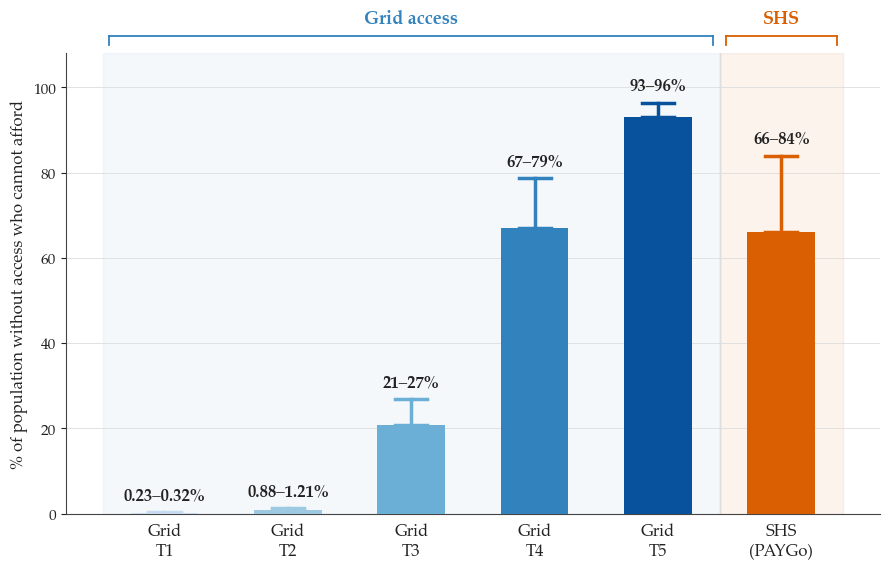

In [49]:

plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.serif']  = ['Palatino', 'Palatino Linotype', 'DejaVu Serif']
plt.rcParams['axes.edgecolor']  = '#444444'
plt.rcParams['text.color']      = '#222222'
plt.rcParams['axes.labelcolor'] = '#222222'
plt.rcParams['xtick.color']     = '#222222'

grid_tier_order = ['T1', 'T2', 'T3', 'T4', 'T5']
col_display = {'T1': 'Grid\nT1', 'T2': 'Grid\nT2', 'T3': 'Grid\nT3',
               'T4': 'Grid\nT4', 'T5': 'Grid\nT5', 'SHS': 'SHS\n(PAYGo)'}

tier_colors = {
    'T1': '#c6dbef', 'T2': '#9ecae1', 'T3': '#6baed6',
    'T4': '#3182bd', 'T5': '#08519c',
}
SHS_COLOR = '#d95f02'

categories = grid_tier_order + ['SHS']
x_pos = np.arange(len(categories))

fig, ax = plt.subplots(figsize=(9, 5.8))

grid_band = (x_pos[0] - 0.5, x_pos[len(grid_tier_order) - 1] + 0.5)
shs_band  = (x_pos[len(grid_tier_order)] - 0.5, x_pos[-1] + 0.5)

ax.axvspan(*grid_band, color='#3182bd', alpha=0.05, zorder=0)
ax.axvspan(*shs_band,  color=SHS_COLOR,  alpha=0.07, zorder=0)

for x, cat in zip(x_pos, categories):
    if cat == 'SHS':
        col = SHS_COLOR
        lo, hi = sorted(shs_range)
    else:
        col = tier_colors[cat]
        lo, hi = sorted(headline_range[cat])

    ax.bar(x, lo, color=col, width=0.55, zorder=3)
    ax.plot([x, x], [lo, hi], color=col, linewidth=2.5, zorder=4)
    for v in (lo, hi):
        ax.plot([x - 0.13, x + 0.13], [v, v], color=col, linewidth=2.5, zorder=4)

    if cat in ('T1', 'T2'):
        label = f'{lo:.2f}–{hi:.2f}%'
    else:
        label = f'{lo:.0f}–{hi:.0f}%'
    ax.text(x, hi + 2, label, ha='center', va='bottom',
             fontsize=12, fontweight='bold', color='#222222')

bracket_y = 112
for (x0, x1), label, col in [
    (grid_band, 'Grid access', '#3182bd'),
    (shs_band,  'SHS',         SHS_COLOR),
]:
    xm = (x0 + x1) / 2
    ax.plot([x0 + 0.05, x1 - 0.05], [bracket_y, bracket_y],
             color=col, linewidth=1.3, zorder=5, clip_on=False)
    ax.plot([x0 + 0.05, x0 + 0.05], [bracket_y - 2, bracket_y],
             color=col, linewidth=1.3, zorder=5, clip_on=False)
    ax.plot([x1 - 0.05, x1 - 0.05], [bracket_y - 2, bracket_y],
             color=col, linewidth=1.3, zorder=5, clip_on=False)
    ax.text(xm, bracket_y + 2, label, ha='center', va='bottom',
             fontsize=13, fontweight='bold', color=col, clip_on=False)

ax.axvline(len(grid_tier_order) - 0.5, color='#dddddd', linewidth=1, zorder=1)

ax.set_xticks(x_pos)
ax.set_xticklabels([col_display[c] for c in categories], fontsize=12)
ax.set_ylim(0, 108)
ax.set_ylabel('% of population without access who cannot afford', fontsize=12)
ax.tick_params(axis='y', labelsize=11)
for spine in ['top', 'right']:
    ax.spines[spine].set_visible(False)
ax.tick_params(bottom=False)
ax.grid(axis='y', color='#dddddd', linewidth=0.6, zorder=0)

plt.tight_layout()
plt.savefig(FIG_DIR / 'fig_affordability_ladder_shs_ssa_vertical.pdf', dpi=600, bbox_inches='tight')
plt.savefig(FIG_DIR / 'fig_affordability_ladder_shs_ssa_vertical.png', dpi=600, bbox_inches='tight')
plt.show()
plt.close(fig)

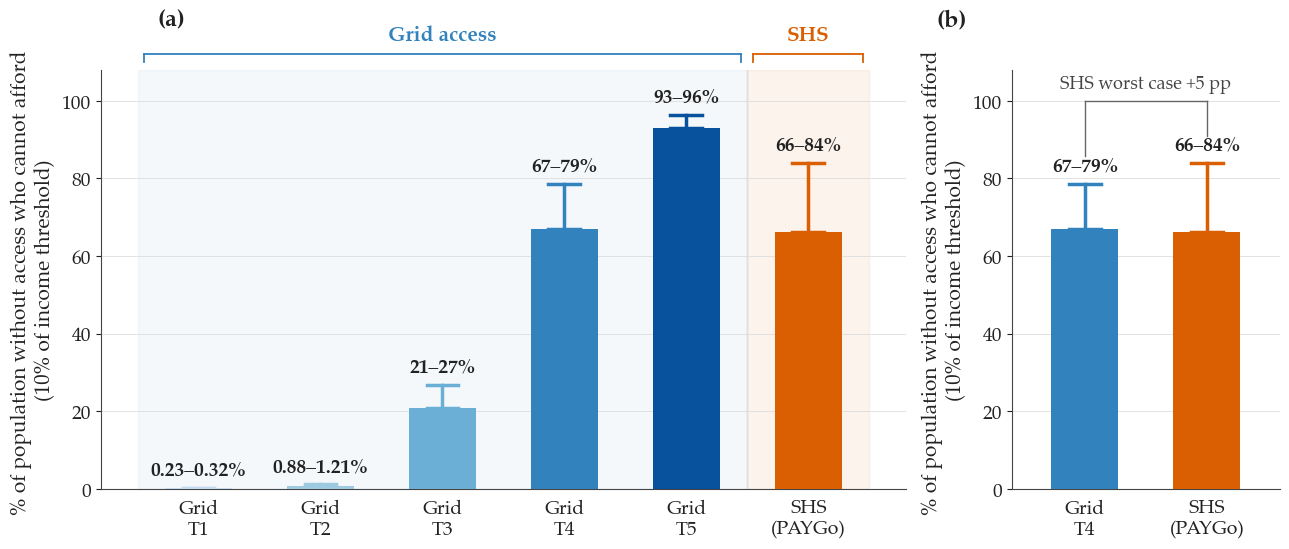

In [50]:
# Plot: Grid T1-T5 ladder (a) + T4 vs SHS full-span comparison (b) 

plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.serif']  = ['Palatino', 'Palatino Linotype', 'DejaVu Serif']
plt.rcParams['axes.edgecolor']  = '#444444'
plt.rcParams['text.color']      = '#222222'
plt.rcParams['axes.labelcolor'] = '#222222'
plt.rcParams['xtick.color']     = '#222222'

grid_tier_order = ['T1', 'T2', 'T3', 'T4', 'T5']
col_display = {'T1': 'Grid\nT1', 'T2': 'Grid\nT2', 'T3': 'Grid\nT3',
               'T4': 'Grid\nT4', 'T5': 'Grid\nT5', 'SHS': 'SHS\n(PAYGo)'}

tier_colors = {
    'T1': '#c6dbef', 'T2': '#9ecae1', 'T3': '#6baed6',
    'T4': '#3182bd', 'T5': '#08519c',
}
SHS_COLOR = '#d95f02'

categories = grid_tier_order + ['SHS']
x_pos = np.arange(len(categories))

fig, (ax1, ax2) = plt.subplots(
    1, 2, figsize=(13, 5.8), gridspec_kw={'width_ratios': [3, 1]}
)

# ══════════════════════════ Panel (a): full ladder ══════════════════════════
grid_band = (x_pos[0] - 0.5, x_pos[len(grid_tier_order) - 1] + 0.5)
shs_band  = (x_pos[len(grid_tier_order)] - 0.5, x_pos[-1] + 0.5)

ax1.axvspan(*grid_band, color='#3182bd', alpha=0.05, zorder=0)
ax1.axvspan(*shs_band,  color=SHS_COLOR,  alpha=0.07, zorder=0)

for x, cat in zip(x_pos, categories):
    if cat == 'SHS':
        col = SHS_COLOR
        lo, hi = sorted(shs_range)
    else:
        col = tier_colors[cat]
        lo, hi = sorted(headline_range[cat])

    ax1.bar(x, lo, color=col, width=0.55, zorder=3)
    ax1.plot([x, x], [lo, hi], color=col, linewidth=2.5, zorder=4)
    for v in (lo, hi):
        ax1.plot([x - 0.13, x + 0.13], [v, v], color=col, linewidth=2.5, zorder=4)

    label = f'{lo:.2f}\u2013{hi:.2f}%' if cat in ('T1', 'T2') else f'{lo:.0f}\u2013{hi:.0f}%'
    ax1.text(x, hi + 2, label, ha='center', va='bottom',
              fontsize=14, fontweight='bold', color='#222222')

bracket_y = 112
for (x0, x1), label, col in [
    (grid_band, 'Grid access', '#3182bd'),
    (shs_band,  'SHS',         SHS_COLOR),
]:
    xm = (x0 + x1) / 2
    ax1.plot([x0 + 0.05, x1 - 0.05], [bracket_y, bracket_y],
              color=col, linewidth=1.3, zorder=5, clip_on=False)
    ax1.plot([x0 + 0.05, x0 + 0.05], [bracket_y - 2, bracket_y],
              color=col, linewidth=1.3, zorder=5, clip_on=False)
    ax1.plot([x1 - 0.05, x1 - 0.05], [bracket_y - 2, bracket_y],
              color=col, linewidth=1.3, zorder=5, clip_on=False)
    ax1.text(xm, bracket_y + 2, label, ha='center', va='bottom',
              fontsize=15, fontweight='bold', color=col, clip_on=False)

ax1.axvline(len(grid_tier_order) - 0.5, color='#dddddd', linewidth=1, zorder=1)
ax1.set_xticks(x_pos)
ax1.set_xticklabels([col_display[c] for c in categories], fontsize=14)
ax1.set_ylim(0, 108)
ax1.set_ylabel('% of population without access who cannot afford \n(10% of income threshold)', fontsize=15)
ax1.tick_params(axis='y', labelsize=14)
for spine in ['top', 'right']:
    ax1.spines[spine].set_visible(False)
ax1.tick_params(bottom=False)
ax1.grid(axis='y', color='#dddddd', linewidth=0.6, zorder=0)

#Panel (b): T4 vs SHS, full-span bars 
t4_lo, t4_hi   = sorted(headline_range['T4'])
shs_lo, shs_hi = sorted(shs_range)

x_t4, x_shs = 0, 1
bar_w = 0.55

for x, (lo, hi), col in [(x_t4, (t4_lo, t4_hi), '#3182bd'),
                          (x_shs, (shs_lo, shs_hi), SHS_COLOR)]:
    ax2.bar(x, lo, color=col, width=bar_w, zorder=3)
    ax2.plot([x, x], [lo, hi], color=col, linewidth=2.5, zorder=4)
    for v in (lo, hi):
        ax2.plot([x - 0.13, x + 0.13], [v, v], color=col, linewidth=2.5, zorder=4)
    label = f'{lo:.0f}\u2013{hi:.0f}%'
    ax2.text(x, hi + 2, label, ha='center', va='bottom',
              fontsize=14, fontweight='bold', color='#222222')

# bracket comparing worst-case (high) estimates 
gap = shs_hi - t4_hi
bracket_top = max(t4_hi, shs_hi) + 16   # was +12 — more headroom above labels
line_start_gap = 7                       # was 3 — clears the bold value labels

ax2.plot([x_t4, x_t4], [t4_hi + line_start_gap, bracket_top], color='#666666', linewidth=1, zorder=5)
ax2.plot([x_shs, x_shs], [shs_hi + line_start_gap, bracket_top], color='#666666', linewidth=1, zorder=5)
ax2.plot([x_t4, x_shs], [bracket_top, bracket_top], color='#666666', linewidth=1, zorder=5)
sign = '+' if gap >= 0 else '\u2212'
worse = 'SHS' if gap >= 0 else 'Grid T4'
ax2.text((x_t4 + x_shs) / 2, bracket_top + 2,
          f'{worse} worst case {sign}{abs(gap):.0f} pp',
          ha='center', va='bottom', fontsize=13, color='#444444')

ax2.set_xticks([x_t4, x_shs])
ax2.set_xticklabels(['Grid\nT4', 'SHS\n(PAYGo)'], fontsize=14)
ax2.set_xlim(-0.6, 1.6)
ax2.set_ylim(0, 108)
ax2.set_ylabel('% of population without access who cannot afford \n(10% of income threshold)', fontsize=15)
ax2.tick_params(axis='y', labelsize=14)
for spine in ['top', 'right']:
    ax2.spines[spine].set_visible(False)
ax2.tick_params(bottom=False)
ax2.grid(axis='y', color='#dddddd', linewidth=0.6, zorder=0)

# panel labels, anchored to figure coordinates so (a)/(b) align
pos1 = ax1.get_position()
pos2 = ax2.get_position()
label_y = max(pos1.y1, pos2.y1) + 0.02
fig.text(pos1.x0, label_y, '(a)', fontsize=17, fontweight='bold', va='bottom')
fig.text(pos2.x0, label_y, '(b)', fontsize=17, fontweight='bold', va='bottom')

plt.tight_layout(rect=[0, 0, 1, 0.94])
plt.savefig(FIG_DIR / 'fig_affordability_ladder_shs_ssa_two_panel.pdf', dpi=600, bbox_inches='tight')
plt.savefig(FIG_DIR / 'fig_affordability_ladder_shs_ssa_two_panel.png', dpi=600, bbox_inches='tight')
plt.show()
plt.close(fig)

In [51]:
full_comparison_2025['pct_cannot_afford_5pct'] = (
    full_comparison_2025['pct_stretch'] + full_comparison_2025['pct_cannot_afford']
)

headline_range_5 = {
    tier: (headline_pct(tier, 'DRE', metric='pct_cannot_afford_5pct'),
           headline_pct(tier, 'MTF', metric='pct_cannot_afford_5pct'))
    for tier in grid_tier_order
}
shs_range_5 = (
    headline_pct('SHS (PAYGo)', 'DRE', metric='pct_cannot_afford_5pct'),
    headline_pct('SHS (PAYGo)', 'MTF', metric='pct_cannot_afford_5pct'),
)

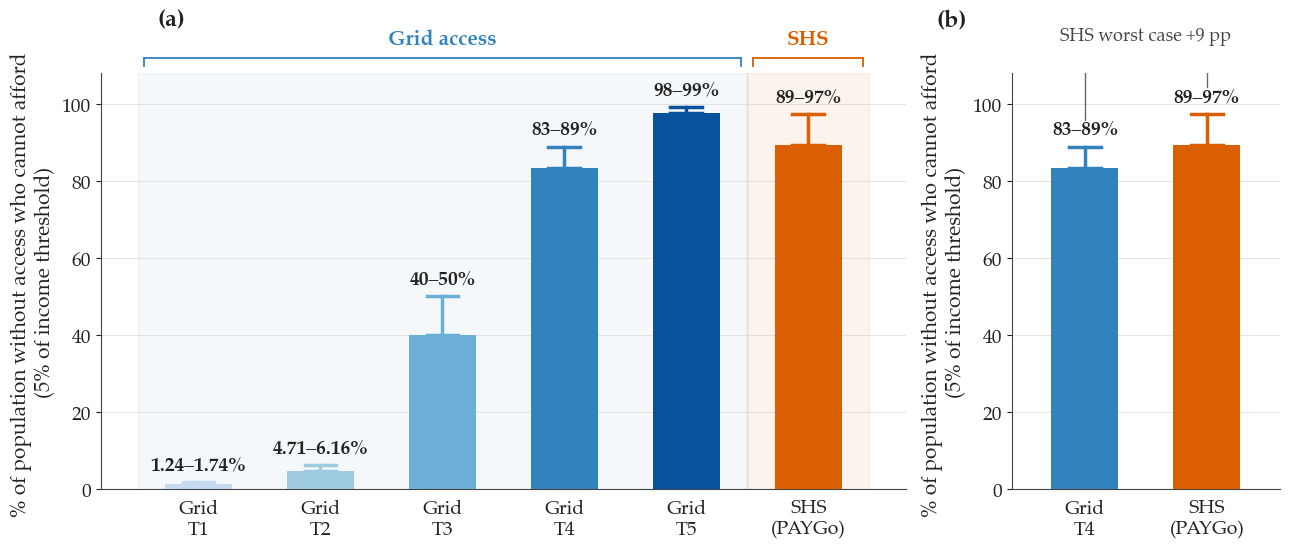

In [52]:
#Plot: Grid T1-T5 ladder (a) + T4 vs SHS comparison (b), at the 5% 


plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.serif']  = ['Palatino', 'Palatino Linotype', 'DejaVu Serif']
plt.rcParams['axes.edgecolor']  = '#444444'
plt.rcParams['text.color']      = '#222222'
plt.rcParams['axes.labelcolor'] = '#222222'
plt.rcParams['xtick.color']     = '#222222'

grid_tier_order = ['T1', 'T2', 'T3', 'T4', 'T5']
col_display = {'T1': 'Grid\nT1', 'T2': 'Grid\nT2', 'T3': 'Grid\nT3',
               'T4': 'Grid\nT4', 'T5': 'Grid\nT5', 'SHS': 'SHS\n(PAYGo)'}

tier_colors = {
    'T1': '#c6dbef', 'T2': '#9ecae1', 'T3': '#6baed6',
    'T4': '#3182bd', 'T5': '#08519c',
}
SHS_COLOR = '#d95f02'

categories = grid_tier_order + ['SHS']
x_pos = np.arange(len(categories))

fig, (ax1, ax2) = plt.subplots(
    1, 2, figsize=(13, 5.8), gridspec_kw={'width_ratios': [3, 1]}
)

# ══════════════════════════ Panel (a): full ladder ══════════════════════════
grid_band = (x_pos[0] - 0.5, x_pos[len(grid_tier_order) - 1] + 0.5)
shs_band  = (x_pos[len(grid_tier_order)] - 0.5, x_pos[-1] + 0.5)

ax1.axvspan(*grid_band, color='#3182bd', alpha=0.05, zorder=0)
ax1.axvspan(*shs_band,  color=SHS_COLOR,  alpha=0.07, zorder=0)

for x, cat in zip(x_pos, categories):
    if cat == 'SHS':
        col = SHS_COLOR
        lo, hi = sorted(shs_range_5)
    else:
        col = tier_colors[cat]
        lo, hi = sorted(headline_range_5[cat])

    ax1.bar(x, lo, color=col, width=0.55, zorder=3)
    ax1.plot([x, x], [lo, hi], color=col, linewidth=2.5, zorder=4)
    for v in (lo, hi):
        ax1.plot([x - 0.13, x + 0.13], [v, v], color=col, linewidth=2.5, zorder=4)

    label = f'{lo:.2f}\u2013{hi:.2f}%' if cat in ('T1', 'T2') else f'{lo:.0f}\u2013{hi:.0f}%'
    ax1.text(x, hi + 2, label, ha='center', va='bottom',
              fontsize=14, fontweight='bold', color='#222222')

bracket_y = 112
for (x0, x1), label, col in [
    (grid_band, 'Grid access', '#3182bd'),
    (shs_band,  'SHS',         SHS_COLOR),
]:
    xm = (x0 + x1) / 2
    ax1.plot([x0 + 0.05, x1 - 0.05], [bracket_y, bracket_y],
              color=col, linewidth=1.3, zorder=5, clip_on=False)
    ax1.plot([x0 + 0.05, x0 + 0.05], [bracket_y - 2, bracket_y],
              color=col, linewidth=1.3, zorder=5, clip_on=False)
    ax1.plot([x1 - 0.05, x1 - 0.05], [bracket_y - 2, bracket_y],
              color=col, linewidth=1.3, zorder=5, clip_on=False)
    ax1.text(xm, bracket_y + 2, label, ha='center', va='bottom',
              fontsize=15, fontweight='bold', color=col, clip_on=False)

ax1.axvline(len(grid_tier_order) - 0.5, color='#dddddd', linewidth=1, zorder=1)
ax1.set_xticks(x_pos)
ax1.set_xticklabels([col_display[c] for c in categories], fontsize=14)
ax1.set_ylim(0, 108)
ax1.set_ylabel('% of population without access who cannot afford \n(5% of income threshold)', fontsize=15)
ax1.tick_params(axis='y', labelsize=14)
for spine in ['top', 'right']:
    ax1.spines[spine].set_visible(False)
ax1.tick_params(bottom=False)
ax1.grid(axis='y', color='#dddddd', linewidth=0.6, zorder=0)

# ═══════════════════ Panel (b): T4 vs SHS, full-span bars ═══════════════════
t4_lo, t4_hi   = sorted(headline_range_5['T4'])
shs_lo, shs_hi = sorted(shs_range_5)

x_t4, x_shs = 0, 1
bar_w = 0.55

for x, (lo, hi), col in [(x_t4, (t4_lo, t4_hi), '#3182bd'),
                          (x_shs, (shs_lo, shs_hi), SHS_COLOR)]:
    ax2.bar(x, lo, color=col, width=bar_w, zorder=3)
    ax2.plot([x, x], [lo, hi], color=col, linewidth=2.5, zorder=4)
    for v in (lo, hi):
        ax2.plot([x - 0.13, x + 0.13], [v, v], color=col, linewidth=2.5, zorder=4)
    label = f'{lo:.0f}\u2013{hi:.0f}%'
    ax2.text(x, hi + 2, label, ha='center', va='bottom',
              fontsize=14, fontweight='bold', color='#222222')

gap = shs_hi - t4_hi
bracket_top = max(t4_hi, shs_hi) + 16   # was +12 — more headroom above labels
line_start_gap = 7                       # was 3 — clears the bold value labels

ax2.plot([x_t4, x_t4], [t4_hi + line_start_gap, bracket_top], color='#666666', linewidth=1, zorder=5)
ax2.plot([x_shs, x_shs], [shs_hi + line_start_gap, bracket_top], color='#666666', linewidth=1, zorder=5)
ax2.plot([x_t4, x_shs], [bracket_top, bracket_top], color='#666666', linewidth=1, zorder=5)
sign = '+' if gap >= 0 else '\u2212'
worse = 'SHS' if gap >= 0 else 'Grid T4'
ax2.text((x_t4 + x_shs) / 2, bracket_top + 2,
          f'{worse} worst case {sign}{abs(gap):.0f} pp',
          ha='center', va='bottom', fontsize=13, color='#444444')

ax2.set_xticks([x_t4, x_shs])
ax2.set_xticklabels(['Grid\nT4', 'SHS\n(PAYGo)'], fontsize=14)
ax2.set_xlim(-0.6, 1.6)
ax2.set_ylim(0, 108)
ax2.set_ylabel('% of population without access who cannot afford \n(5% of income threshold)', fontsize=15)
ax2.tick_params(axis='y', labelsize=14)
for spine in ['top', 'right']:
    ax2.spines[spine].set_visible(False)
ax2.tick_params(bottom=False)
ax2.grid(axis='y', color='#dddddd', linewidth=0.6, zorder=0)

pos1 = ax1.get_position()
pos2 = ax2.get_position()
label_y = max(pos1.y1, pos2.y1) + 0.02
fig.text(pos1.x0, label_y, '(a)', fontsize=17, fontweight='bold', va='bottom')
fig.text(pos2.x0, label_y, '(b)', fontsize=17, fontweight='bold', va='bottom')

plt.tight_layout(rect=[0, 0, 1, 0.94])
plt.savefig(FIG_DIR / 'fig_affordability_ladder_shs_ssa_5pct_two_panel.pdf', dpi=600, bbox_inches='tight')
plt.savefig(FIG_DIR / 'fig_affordability_ladder_shs_ssa_5pct_two_panel.png', dpi=600, bbox_inches='tight')
plt.show()
plt.close(fig)

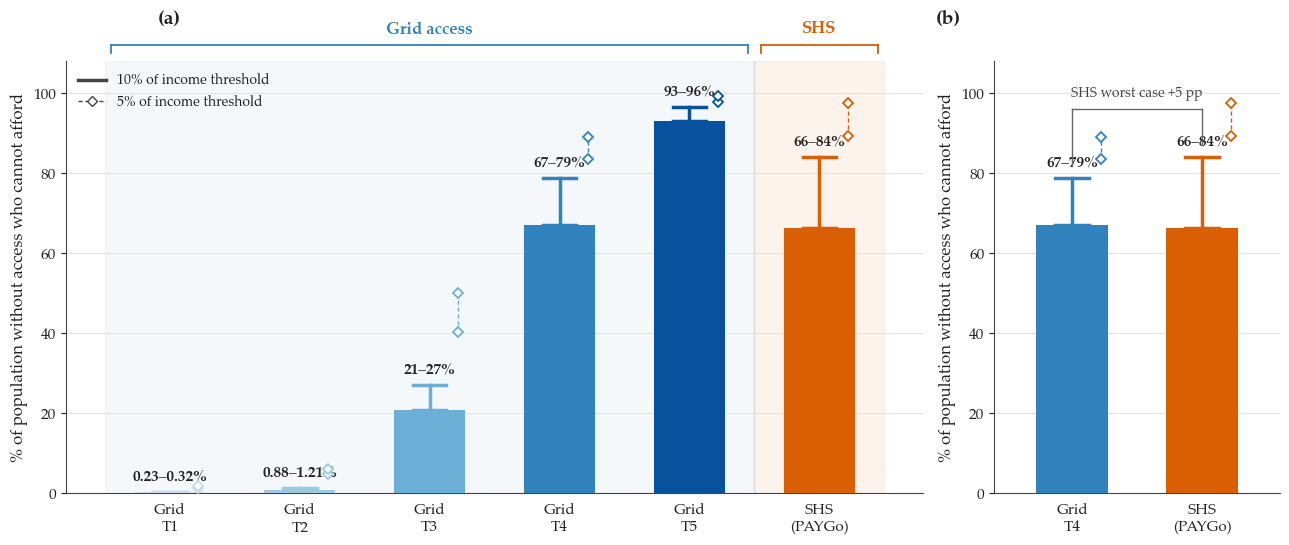

In [53]:
# Plot: Grid T1-T5 ladder (a) + T4 vs SHS comparison (b), merged thresholds

plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.serif']  = ['Palatino', 'Palatino Linotype', 'DejaVu Serif']
plt.rcParams['axes.edgecolor']  = '#444444'
plt.rcParams['text.color']      = '#222222'
plt.rcParams['axes.labelcolor'] = '#222222'
plt.rcParams['xtick.color']     = '#222222'

grid_tier_order = ['T1', 'T2', 'T3', 'T4', 'T5']
col_display = {'T1': 'Grid\nT1', 'T2': 'Grid\nT2', 'T3': 'Grid\nT3',
               'T4': 'Grid\nT4', 'T5': 'Grid\nT5', 'SHS': 'SHS\n(PAYGo)'}

tier_colors = {
    'T1': '#c6dbef', 'T2': '#9ecae1', 'T3': '#6baed6',
    'T4': '#3182bd', 'T5': '#08519c',
}
SHS_COLOR = '#d95f02'
OFFSET = 0.22   # x-shift for the 5% marker so it doesn't sit on top of the 10% whisker

categories = grid_tier_order + ['SHS']
x_pos = np.arange(len(categories))

fig, (ax1, ax2) = plt.subplots(
    1, 2, figsize=(13, 5.8), gridspec_kw={'width_ratios': [3, 1]}
)

def draw_secondary_marker(ax, x, lo, hi, col):
    """5% threshold: open diamond at each end, thin dashed connector, offset in x."""
    xm = x + OFFSET
    ax.plot([xm, xm], [lo, hi], color=col, linewidth=1, linestyle=(0, (3, 2)), zorder=4)
    ax.plot(xm, lo, marker='D', markersize=5, markerfacecolor='white',
             markeredgecolor=col, markeredgewidth=1.3, zorder=5)
    ax.plot(xm, hi, marker='D', markersize=5, markerfacecolor='white',
             markeredgecolor=col, markeredgewidth=1.3, zorder=5)

# Panel (a): full ladder 
grid_band = (x_pos[0] - 0.5, x_pos[len(grid_tier_order) - 1] + 0.5)
shs_band  = (x_pos[len(grid_tier_order)] - 0.5, x_pos[-1] + 0.5)

ax1.axvspan(*grid_band, color='#3182bd', alpha=0.05, zorder=0)
ax1.axvspan(*shs_band,  color=SHS_COLOR,  alpha=0.07, zorder=0)

for x, cat in zip(x_pos, categories):
    if cat == 'SHS':
        col = SHS_COLOR
        lo, hi = sorted(shs_range)
        lo5, hi5 = sorted(shs_range_5)
    else:
        col = tier_colors[cat]
        lo, hi = sorted(headline_range[cat])
        lo5, hi5 = sorted(headline_range_5[cat])

    ax1.bar(x, lo, color=col, width=0.55, zorder=3)
    ax1.plot([x, x], [lo, hi], color=col, linewidth=2.5, zorder=4)
    for v in (lo, hi):
        ax1.plot([x - 0.13, x + 0.13], [v, v], color=col, linewidth=2.5, zorder=4)

    label = f'{lo:.2f}\u2013{hi:.2f}%' if cat in ('T1', 'T2') else f'{lo:.0f}\u2013{hi:.0f}%'
    ax1.text(x, hi + 2, label, ha='center', va='bottom',
              fontsize=11, fontweight='bold', color='#222222')

    draw_secondary_marker(ax1, x, lo5, hi5, col)

bracket_y = 112
for (x0, x1), label, col in [
    (grid_band, 'Grid access', '#3182bd'),
    (shs_band,  'SHS',         SHS_COLOR),
]:
    xm = (x0 + x1) / 2
    ax1.plot([x0 + 0.05, x1 - 0.05], [bracket_y, bracket_y],
              color=col, linewidth=1.3, zorder=5, clip_on=False)
    ax1.plot([x0 + 0.05, x0 + 0.05], [bracket_y - 2, bracket_y],
              color=col, linewidth=1.3, zorder=5, clip_on=False)
    ax1.plot([x1 - 0.05, x1 - 0.05], [bracket_y - 2, bracket_y],
              color=col, linewidth=1.3, zorder=5, clip_on=False)
    ax1.text(xm, bracket_y + 2, label, ha='center', va='bottom',
              fontsize=12, fontweight='bold', color=col, clip_on=False)

ax1.axvline(len(grid_tier_order) - 0.5, color='#dddddd', linewidth=1, zorder=1)
ax1.set_xticks(x_pos)
ax1.set_xticklabels([col_display[c] for c in categories], fontsize=11)
ax1.set_ylim(0, 108)
ax1.set_ylabel('% of population without access who cannot afford', fontsize=12)
ax1.tick_params(axis='y', labelsize=11)
for spine in ['top', 'right']:
    ax1.spines[spine].set_visible(False)
ax1.tick_params(bottom=False)
ax1.grid(axis='y', color='#dddddd', linewidth=0.6, zorder=0)

# legend distinguishing the two thresholds 
legend_elements = [
    Line2D([0], [0], color='#444444', linewidth=2.5, label='10% of income threshold'),
    Line2D([0], [0], color='#444444', linewidth=1, linestyle=(0, (3, 2)),
           marker='D', markersize=5, markerfacecolor='white',
           markeredgecolor='#444444', label='5% of income threshold'),
]
ax1.legend(handles=legend_elements, loc='upper left', frameon=False, fontsize=10)

#  Panel (b): T4 vs SHS, full-span bars 
t4_lo, t4_hi   = sorted(headline_range['T4'])
shs_lo, shs_hi = sorted(shs_range)
t4_lo5, t4_hi5   = sorted(headline_range_5['T4'])
shs_lo5, shs_hi5 = sorted(shs_range_5)

x_t4, x_shs = 0, 1
bar_w = 0.55

for x, (lo, hi), (lo5, hi5), col in [
    (x_t4, (t4_lo, t4_hi), (t4_lo5, t4_hi5), '#3182bd'),
    (x_shs, (shs_lo, shs_hi), (shs_lo5, shs_hi5), SHS_COLOR),
]:
    ax2.bar(x, lo, color=col, width=bar_w, zorder=3)
    ax2.plot([x, x], [lo, hi], color=col, linewidth=2.5, zorder=4)
    for v in (lo, hi):
        ax2.plot([x - 0.13, x + 0.13], [v, v], color=col, linewidth=2.5, zorder=4)
    label = f'{lo:.0f}\u2013{hi:.0f}%'
    ax2.text(x, hi + 2, label, ha='center', va='bottom',
              fontsize=11, fontweight='bold', color='#222222')

    draw_secondary_marker(ax2, x, lo5, hi5, col)

#  bracket comparing worst-case (high) 10% estimates 
gap = shs_hi - t4_hi
bracket_top = max(t4_hi, shs_hi) + 12
ax2.plot([x_t4, x_t4], [t4_hi + 3, bracket_top], color='#666666', linewidth=1, zorder=5)
ax2.plot([x_shs, x_shs], [shs_hi + 3, bracket_top], color='#666666', linewidth=1, zorder=5)
ax2.plot([x_t4, x_shs], [bracket_top, bracket_top], color='#666666', linewidth=1, zorder=5)
sign = '+' if gap >= 0 else '\u2212'
worse = 'SHS' if gap >= 0 else 'Grid T4'
ax2.text((x_t4 + x_shs) / 2, bracket_top + 2,
          f'{worse} worst case {sign}{abs(gap):.0f} pp',
          ha='center', va='bottom', fontsize=10, color='#444444')

ax2.set_xticks([x_t4, x_shs])
ax2.set_xticklabels(['Grid\nT4', 'SHS\n(PAYGo)'], fontsize=11)
ax2.set_xlim(-0.6, 1.6)
ax2.set_ylim(0, 108)
ax2.set_ylabel('% of population without access who cannot afford', fontsize=12)
ax2.tick_params(axis='y', labelsize=11)
for spine in ['top', 'right']:
    ax2.spines[spine].set_visible(False)
ax2.tick_params(bottom=False)
ax2.grid(axis='y', color='#dddddd', linewidth=0.6, zorder=0)

# panel labels, anchored to figure coordinates so (a)/(b) align 
pos1 = ax1.get_position()
pos2 = ax2.get_position()
label_y = max(pos1.y1, pos2.y1) + 0.02
fig.text(pos1.x0, label_y, '(a)', fontsize=14, fontweight='bold', va='bottom')
fig.text(pos2.x0, label_y, '(b)', fontsize=14, fontweight='bold', va='bottom')

plt.tight_layout(rect=[0, 0, 1, 0.94])
plt.savefig(FIG_DIR / 'fig_affordability_ladder_shs_ssa_merged_two_panel.pdf', dpi=600, bbox_inches='tight')
plt.savefig(FIG_DIR / 'fig_affordability_ladder_shs_ssa_merged_two_panel.png', dpi=600, bbox_inches='tight')
plt.show()
plt.close(fig)

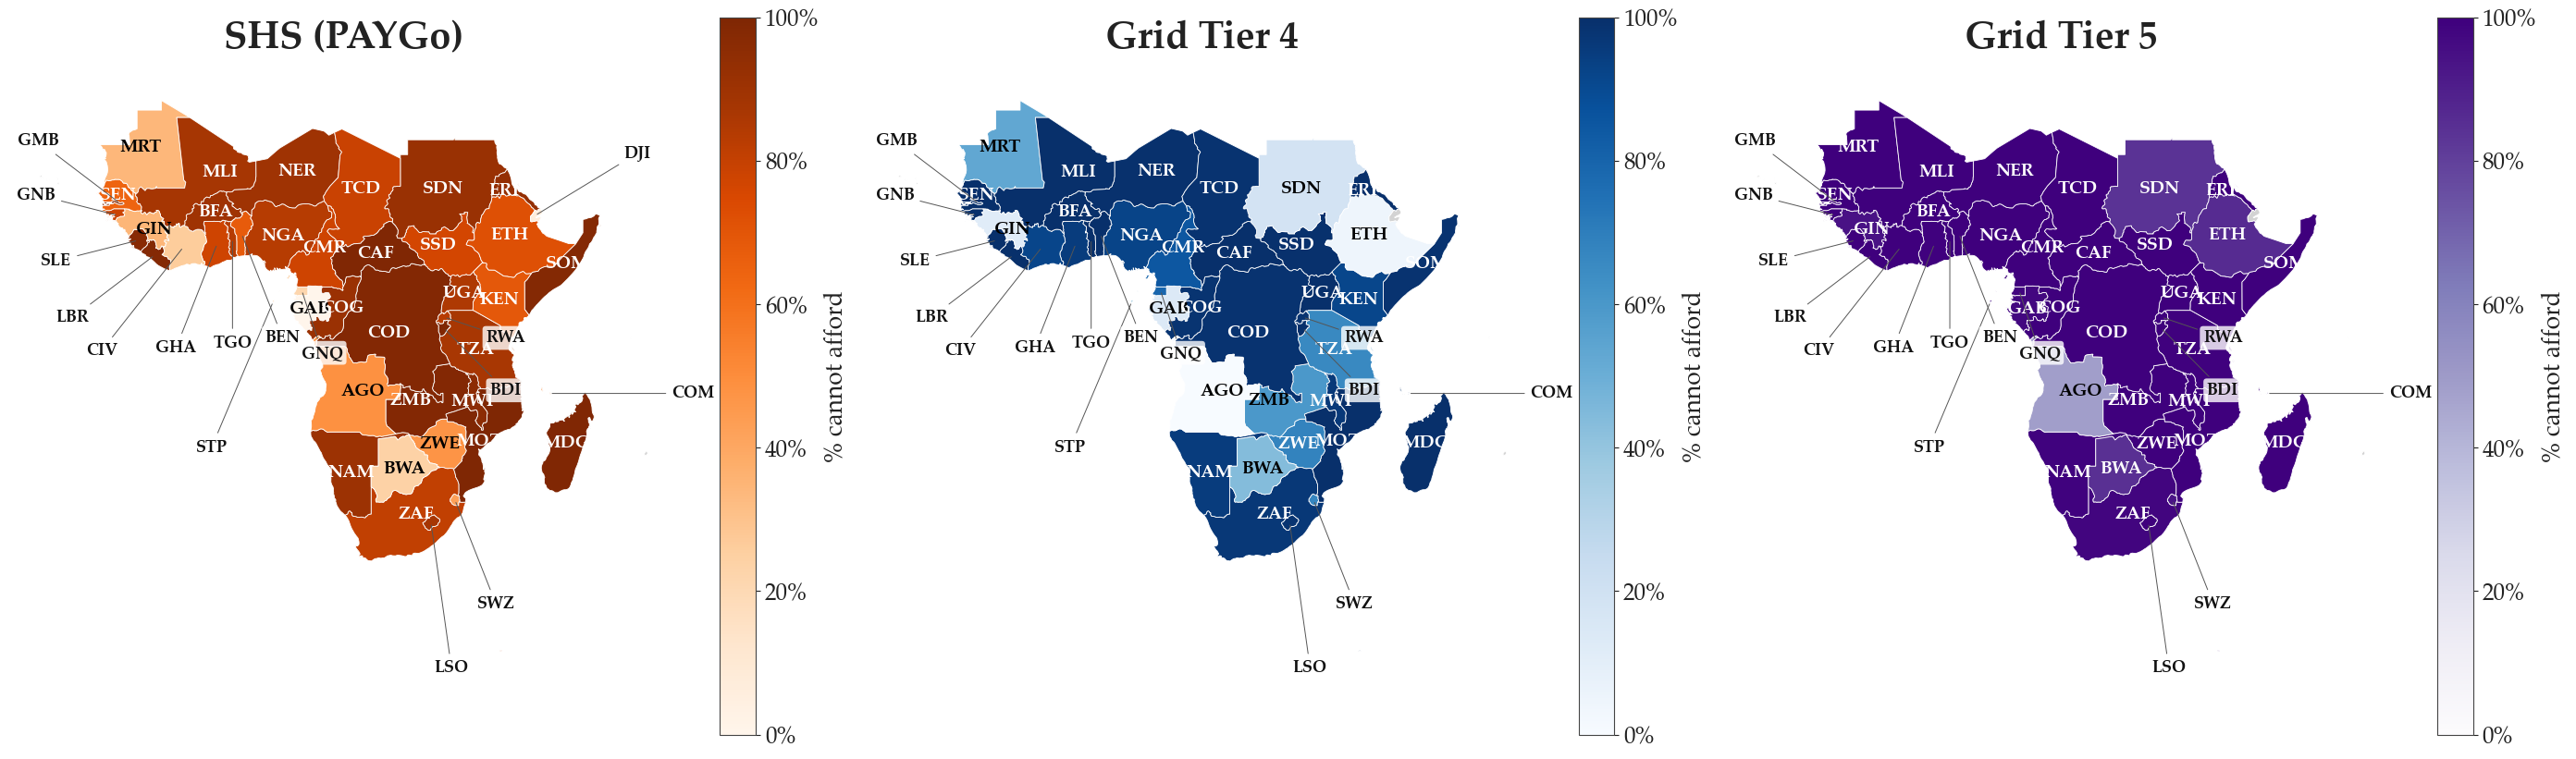

In [54]:
#3-panel choropleth: % of unelectrified who CANNOT afford — SHS / T4 / T5 


WEIGHT_METHOD = 'DRE'

SMALL_OFFSET_LABELS = {
    'GMB': (-8, 6),   'GNB': (-8, 2),   'SLE': (-8, -2),
    'LBR': (-8, -6),  'CIV': (-8, -10), 'GHA': (-4, -10),
    'TGO': (0, -10),  'BEN': (4, -10),  'GNQ': (2, -6),
    'STP': (-6, -14), 'COM': (14, 0),   'SYC': (16, 4),
    'MUS': (16, -4),  'CPV': (-14, 10), 'DJI': (10, 6),
    'RWA': (6, -2),   'BDI': (6, -6),   'SWZ': (4, -10),
    'LSO': (2, -14),
}

map_data = full_comparison_2025[full_comparison_2025['Weighting'] == WEIGHT_METHOD]
map_data = map_data.pivot(index='ISO3', columns='Tier', values='pct_cannot_afford').reset_index()
map_data = map_data.rename(columns={'SHS (PAYGo)': 'SHS_PAYGo', 'T4': 'Grid_T4', 'T5': 'Grid_T5'})

ssa_cannot_map = ssa.merge(map_data, left_on='ISO_A3', right_on='ISO3', how='left')

panels = [
    ('SHS_PAYGo', 'SHS (PAYGo)', 'Oranges'),
    ('Grid_T4',   'Grid Tier 4', 'Blues'),
    ('Grid_T5',   'Grid Tier 5', 'Purples'),
]

fig, axes = plt.subplots(1, 3, figsize=(28, 10))

for ax, (col, title, cmap) in zip(axes, panels):
    ssa_cannot_map.plot(
        column=col, ax=ax, cmap=cmap, vmin=0, vmax=100,
        legend=True,
        legend_kwds={'label': '% cannot afford', 'shrink': 0.8, 'format': '%.0f%%'},
        missing_kwds={'color': 'lightgrey', 'label': 'No data'},
        edgecolor='white', linewidth=0.6,
    )

    cbar = ax.get_figure().axes[-1]
    cbar.tick_params(labelsize=18)
    cbar.set_ylabel('% cannot afford', fontsize=19)

    for _, row in ssa_cannot_map.iterrows():
        if pd.isna(row['ISO3']) or pd.isna(row[col]):
            continue
        iso = row['ISO3']
        centroid = row['geometry'].representative_point()
        text_color = 'white' if row[col] >= 60 else 'black'

        if iso in SMALL_OFFSET_LABELS:
            dx, dy = SMALL_OFFSET_LABELS[iso]
            ax.annotate(
                text=iso,
                xy=(centroid.x, centroid.y),
                xytext=(centroid.x + dx * 1.4, centroid.y + dy * 1.4),
                ha='center', va='center', fontsize=13, fontweight='bold',
                color='#111111',
                arrowprops=dict(arrowstyle='-', color='#555555', lw=0.7),
                bbox=dict(boxstyle='round,pad=0.2', facecolor='white',
                          edgecolor='none', alpha=0.8)
            )
        else:
            ax.annotate(
                text=iso,
                xy=(centroid.x, centroid.y),
                ha='center', va='center',
                fontsize=14, color=text_color, fontweight='bold'
            )

    ax.set_title(title, fontsize=30, fontweight='bold', pad=20)
    ax.axis('off')

plt.tight_layout()
plt.tight_layout()
plt.savefig(FIG_DIR / f'fig_affordability_3panel_maps_{WEIGHT_METHOD.lower()}.pdf', dpi=600, bbox_inches='tight')
plt.savefig(FIG_DIR / f'fig_affordability_3panel_maps_{WEIGHT_METHOD.lower()}.png', dpi=600, bbox_inches='tight')
plt.show()
plt.close(fig)

In [55]:
# Kenya/Zambia — average income & affordability gap, MTF vs DRE

gap_results = {}

for iso, country in [('KEN', 'Kenya'), ('ZMB', 'Zambia')]:
    if iso in percentiles_cache:
        country_percentiles = percentiles_cache[iso]
    else:
        print(f"({country}: not found in percentiles_cache — resimulating)")
        gni_annual = pd.to_numeric(
            gni_raw.loc[gni_raw['Country Code'] == iso, '2025'].values[0], errors='coerce'
        )
        gini_target = gini_lookup.loc[iso, 'gini']
        mean_income = gni_annual / 12
        n_sim = int(pop_lookup.loc[iso]) if (iso in pop_lookup.index and
                                              not pd.isna(pop_lookup.loc[iso])) else 100_000
        np.random.seed(42)
        mu = np.log(mean_income) - 0.5 * SIGMA_INIT**2
        initial_dist = np.random.lognormal(mu, SIGMA_INIT, n_sim).astype(np.float32)
        adj_dist = adjust_distribution_to_target_gini(initial_dist, gini_target, mean_income)
        country_percentiles = np.array([percentile_from_sorted(adj_dist, p) for p in range(1, 101)])
        percentiles_cache[iso] = country_percentiles
        del adj_dist, initial_dist

    weight_sources = {
        'MTF': mtf_shares_for(country),
        'DRE': dre_shares_for(iso),
    }

    print(f"\n{country}:")
    for method, quintile_weights in weight_sources.items():
        if quintile_weights is None:
            print(f"  {method}: no weights available — skipped")
            continue

        # per-percentile weight = its quintile's method-specific unelectrified share
        cannot_incomes, cannot_weights = [], []
        afford_or_stretch_weight, total_weight = 0.0, 0.0

        for p_idx, income in enumerate(country_percentiles):
            q_idx = p_idx // 20
            w = quintile_weights[q_idx]
            bill_share_pct = (monthly_paygo / income) * 100
            total_weight += w
            if bill_share_pct > ENERGY_HIGH * 100:
                cannot_incomes.append(income)
                cannot_weights.append(w)
            else:
                afford_or_stretch_weight += w

        cannot_pct = sum(cannot_weights) / total_weight * 100
        weighted_avg_income = np.average(cannot_incomes, weights=cannot_weights)
        avg_gap_monthly = monthly_paygo - weighted_avg_income * ENERGY_HIGH
        avg_gap_total = avg_gap_monthly * REPAYMENT_MONTHS

        gap_results[(iso, method)] = {
            'cannot_pct': cannot_pct,
            'avg_income': weighted_avg_income,
            'gap_monthly': avg_gap_monthly,
            'gap_total': avg_gap_total,
        }

        print(f"  {method}-weighted:")
        print(f"    Cannot-afford %:                  {cannot_pct:.1f}%")
        print(f"    Weighted avg monthly income:       ${weighted_avg_income:.2f}")
        print(f"    Avg monthly gap:                   ${avg_gap_monthly:.2f}")
        print(f"    Avg total gap over {REPAYMENT_MONTHS} months:   ${avg_gap_total:.2f}")


Kenya:
  MTF-weighted:
    Cannot-afford %:                  31.6%
    Weighted avg monthly income:       $55.15
    Avg monthly gap:                   $2.24
    Avg total gap over 24 months:   $53.68
  DRE-weighted:
    Cannot-afford %:                  69.1%
    Weighted avg monthly income:       $55.15
    Avg monthly gap:                   $2.24
    Avg total gap over 24 months:   $53.68

Zambia:
  MTF-weighted:
    Cannot-afford %:                  84.6%
    Weighted avg monthly income:       $36.84
    Avg monthly gap:                   $4.07
    Avg total gap over 24 months:   $97.62
  DRE-weighted:
    Cannot-afford %:                  98.8%
    Weighted avg monthly income:       $26.88
    Avg monthly gap:                   $5.06
    Avg total gap over 24 months:   $121.53


In [56]:
# ══════════════════════════════════════════════════════════════════════════
# CELL A — GEP technology shares, built directly from gep_summary only
# ══════════════════════════════════════════════════════════════════════════
shares_df = gep_summary[['ISO3', 'NewConn_Grid', 'NewConn_SHS', 'NewConn_MG', 'NewConn_Total']].copy()
shares_df['grid_share'] = shares_df['NewConn_Grid'] / shares_df['NewConn_Total'] * 100
shares_df['shs_share']  = shares_df['NewConn_SHS']  / shares_df['NewConn_Total'] * 100
shares_df['mg_share']   = shares_df['NewConn_MG']   / shares_df['NewConn_Total'] * 100

SSA countries with no RISE score in this file: ['BWA', 'COM', 'CPV', 'DJI', 'GAB', 'GMB', 'GNB', 'GNQ', 'LSO', 'MUS', 'NAM', 'STP', 'SWZ', 'SYC']


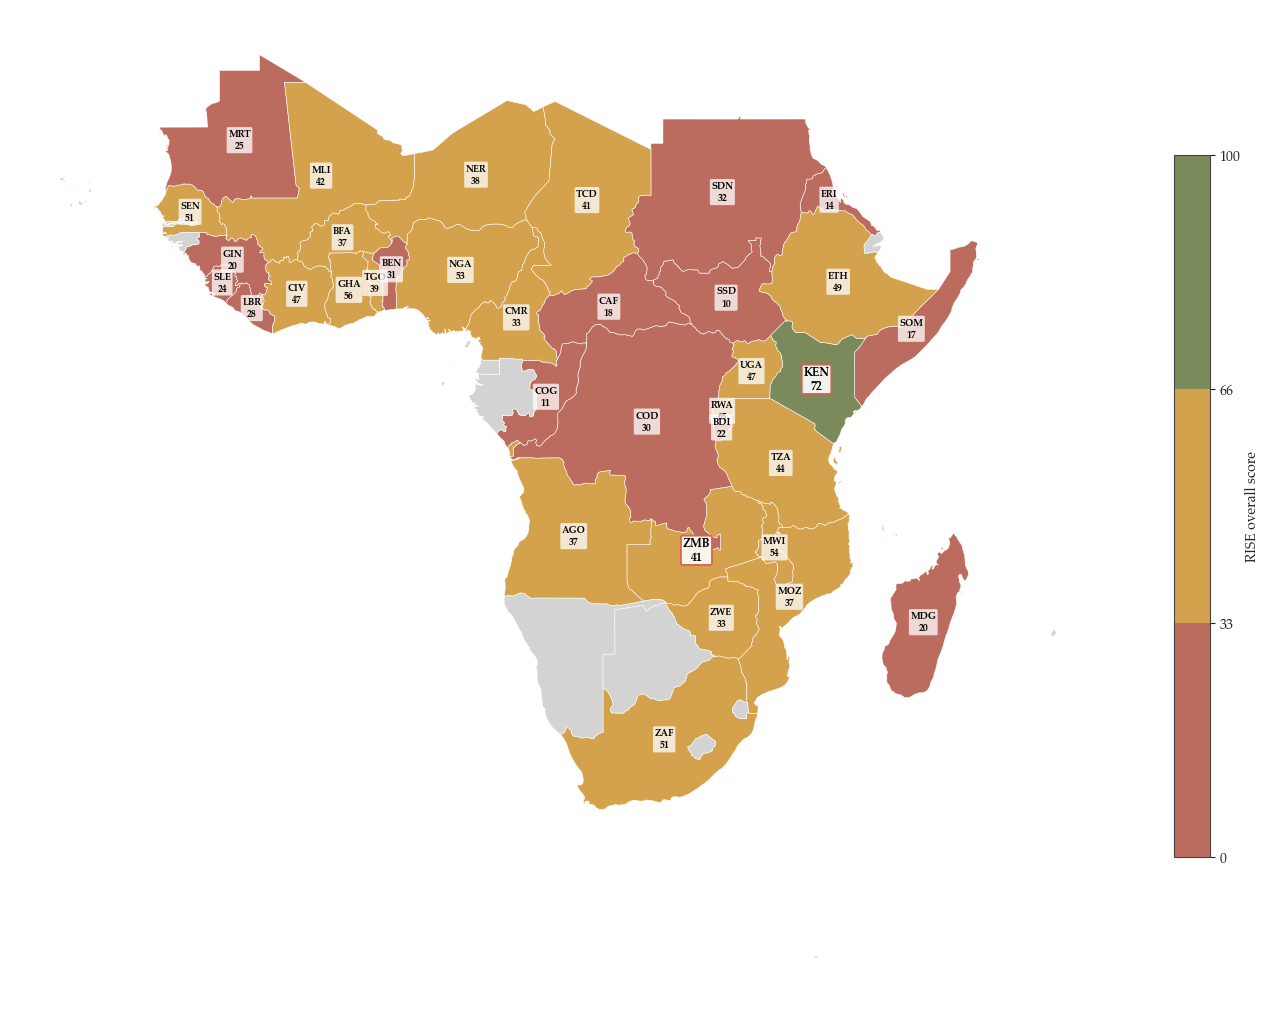

In [57]:
# World Bank RISE overall score — SSA choropleth 

with open(RISE_PATH, encoding='utf-8-sig') as f:
    html = f.read()

tbody = re.search(r'<tbody>(.*?)</tbody>', html, re.S).group(1)
rows = re.findall(r'<tr><th[^>]*>(.*?)</th><td[^>]*>(.*?)</td></tr>', tbody)
rise_raw = pd.DataFrame(rows, columns=['Country', 'RISE_Score'])
rise_raw['RISE_Score'] = pd.to_numeric(rise_raw['RISE_Score'])

rise_name_to_iso3 = {
    'Angola': 'AGO', 'Benin': 'BEN', 'Burkina Faso': 'BFA', 'Burundi': 'BDI',
    'Cameroon': 'CMR', 'Central African Republic': 'CAF', 'Chad': 'TCD',
    'Congo, Dem. Rep.': 'COD', 'Congo, Rep.': 'COG', "Côte d'Ivoire": 'CIV',
    'Eritrea': 'ERI', 'Ethiopia': 'ETH', 'Ghana': 'GHA', 'Guinea': 'GIN',
    'Guinea-Bissau': 'GNB', 'Kenya': 'KEN', 'Liberia': 'LBR',
    'Madagascar': 'MDG', 'Malawi': 'MWI', 'Mali': 'MLI', 'Mauritania': 'MRT',
    'Mauritius': 'MUS', 'Mozambique': 'MOZ', 'Niger': 'NER', 'Nigeria': 'NGA',
    'Rwanda': 'RWA', 'Senegal': 'SEN', 'Sierra Leone': 'SLE', 'Somalia': 'SOM',
    'South Africa': 'ZAF', 'South Sudan': 'SSD', 'Sudan': 'SDN',
    'Tanzania': 'TZA', 'Togo': 'TGO', 'Uganda': 'UGA', 'Zambia': 'ZMB',
    'Zimbabwe': 'ZWE',
}
rise_raw['ISO3'] = rise_raw['Country'].map(rise_name_to_iso3)

missing = sorted(set(ssa_iso) - set(rise_raw['ISO3']))
if missing:
    print(f"SSA countries with no RISE score in this file: {missing}")

rise_map = ssa.merge(rise_raw[['ISO3', 'RISE_Score']], left_on='ISO_A3', right_on='ISO3', how='left')

rise_cmap = mcolors.ListedColormap(['#BC6C5F', '#D4A24C', '#7A8A5A'])  # red / amber / green
rise_bounds = [0, 33, 66, 100]
rise_norm = mcolors.BoundaryNorm(rise_bounds, rise_cmap.N)

fig, ax = plt.subplots(figsize=(14, 12))

rise_map.plot(
    column='RISE_Score',
    ax=ax,
    cmap=rise_cmap,
    norm=rise_norm,
    legend=True,
    legend_kwds={'label': 'RISE overall score', 'shrink': 0.6, 'ticks': rise_bounds},
    missing_kwds={'color': 'lightgrey', 'label': 'No data'},
    edgecolor='white', linewidth=0.4,
)

# Annotate every country with its ISO3 code + score
for idx, row in rise_map.iterrows():
    if row.geometry is not None and pd.notna(row.get('RISE_Score')):
        centroid = row.geometry.centroid
        label = f"{row['ISO_A3']}\n{row['RISE_Score']:.0f}"

        is_case_study = row['ISO_A3'] in ('KEN', 'ZMB')
        # switch label colour to white on the dark green tier for legibility
        text_color = 'black' if row['RISE_Score'] >= 67 else 'black'
        ax.annotate(
            label,
            xy=(centroid.x, centroid.y),
            fontsize=7 if not is_case_study else 8.5,
            fontweight='bold',
            color=text_color,
            ha='center', va='center',
            bbox=dict(boxstyle='round,pad=0.15', facecolor='white',
                      edgecolor='#D6604D' if is_case_study else 'none',
                      linewidth=1.4 if is_case_study else 0,
                      alpha=0.75 if not is_case_study else 0.9)
        )

ax.axis('off')
plt.tight_layout()
plt.savefig(FIG_DIR / 'fig_africa_rise_score.png', dpi=600, bbox_inches='tight')
plt.show()
plt.close(fig)

In [58]:
TEXT_COLOR = '#1a1a1a' 

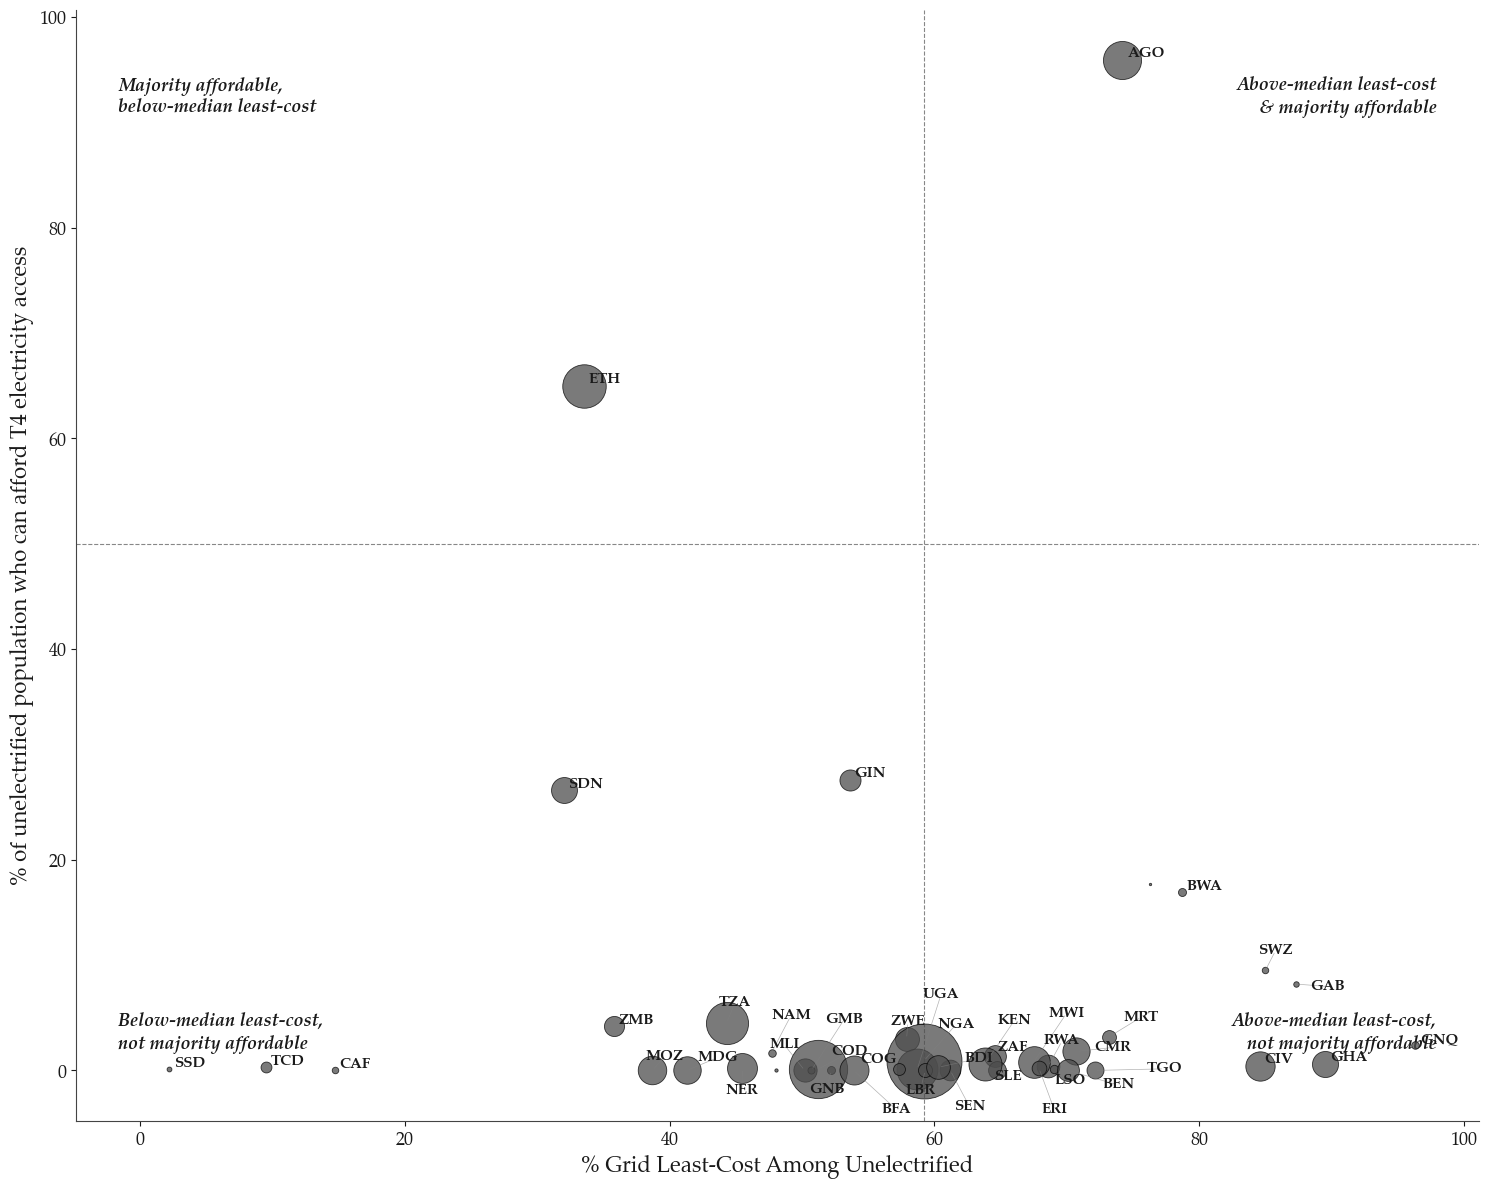

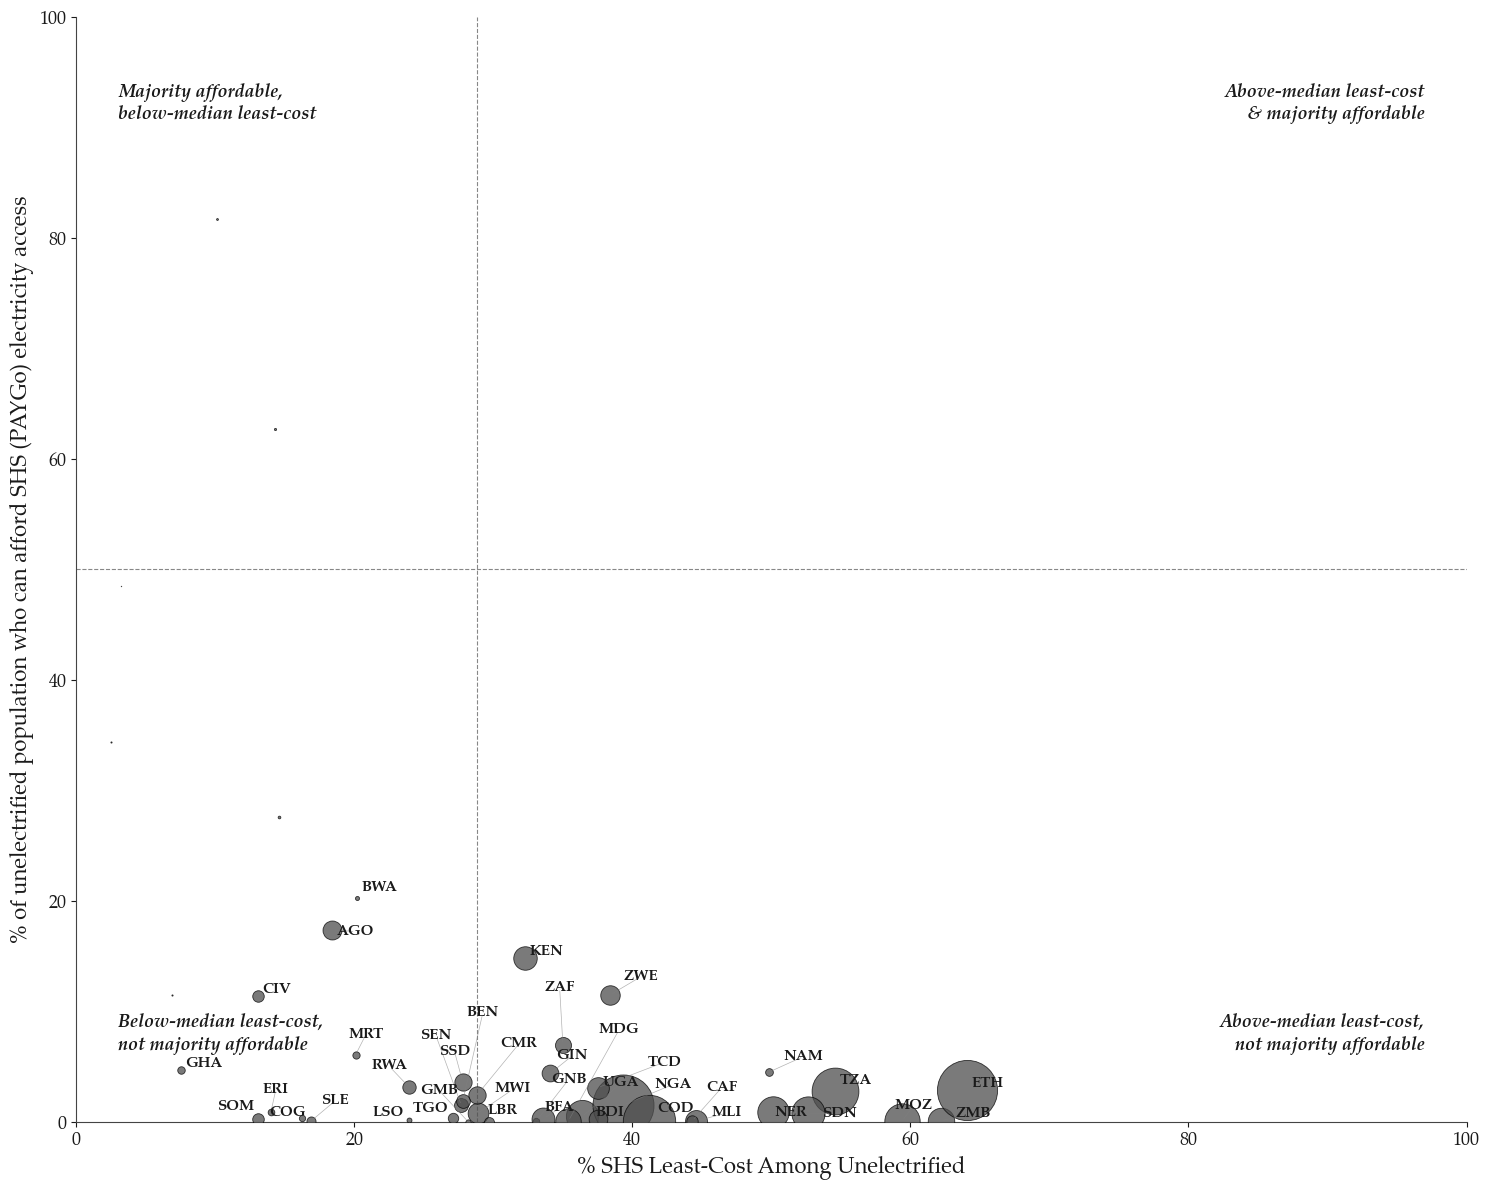

In [ ]:
def make_affordability_bubble_chart(x_col, tier_label, size_col, x_axis_title,
                                     weight_method=WEIGHT_METHOD, save_stub=None,
                                     quadrant_labels=None, xlim=None, ylim=None,
                                     y_threshold=50, label_min_size=None):
    """
    label_min_size : if set, bubbles with size_col below this value are plotted
                     without a text label (dot only) — reduces clutter in dense
                     corners where many small countries overlap.
    """
    aff = full_comparison_2025[
        (full_comparison_2025['Tier'] == tier_label) &
        (full_comparison_2025['Weighting'] == weight_method)
    ][['ISO3', 'pct_affordable']]

    plot_df = ssa_map.merge(aff, on='ISO3', how='left')
    plot_df = plot_df.dropna(subset=[x_col, 'pct_affordable', size_col])

    median_x = plot_df[x_col].median()

    fig, ax = plt.subplots(figsize=(15, 12))
    texts = []

    for _, row in plot_df.iterrows():
        x, y = row[x_col], row['pct_affordable']
        raw_size = row[size_col]
        size = raw_size / 30000

        ax.scatter(
            x, y,
            s=size, color='#4d4d4d', alpha=0.75,
            edgecolors='black', linewidth=0.6,
            zorder=3
        )

        if label_min_size is None or raw_size >= label_min_size:
            texts.append(
                ax.text(x, y, row['ISO_A3'], fontsize=11, color='#1a1a1a',
                         fontweight='bold', zorder=5)
            )

    if xlim is not None:
        ax.set_xlim(*xlim)
    if ylim is not None:
        ax.set_ylim(*ylim)

    ax.axvline(median_x,    color=GREY, linestyle='--', linewidth=0.8, zorder=1)
    ax.axhline(y_threshold, color=GREY, linestyle='--', linewidth=0.8, zorder=1)

    if quadrant_labels is None:
        quadrant_labels = {
            'tr': 'Above-median least-cost\n& majority affordable',
            'tl': 'Majority affordable,\nbelow-median least-cost',
            'br': 'Above-median least-cost,\nnot majority affordable',
            'bl': 'Below-median least-cost,\nnot majority affordable',
        }

    xl = ax.get_xlim()
    yl = ax.get_ylim()
    pad_x = (xl[1] - xl[0]) * 0.03
    pad_y = (yl[1] - yl[0]) * 0.06   # slightly larger — gives quadrant text more room from data

    quad_positions = {
        'tr': dict(x=xl[1] - pad_x, y=yl[1] - pad_y, ha='right', va='top'),
        'tl': dict(x=xl[0] + pad_x, y=yl[1] - pad_y, ha='left',  va='top'),
        'br': dict(x=xl[1] - pad_x, y=yl[0] + pad_y, ha='right', va='bottom'),
        'bl': dict(x=xl[0] + pad_x, y=yl[0] + pad_y, ha='left',  va='bottom'),
    }

    quad_texts = []
    for key, pos in quad_positions.items():
        t = ax.text(
            pos['x'], pos['y'], quadrant_labels[key],
            ha=pos['ha'], va=pos['va'],
            fontsize=13, fontweight='bold', color=TEXT_COLOR,
            style='italic', zorder=2,
            bbox=dict(boxstyle='round,pad=0.3', facecolor='white',
                      edgecolor='none', alpha=0.85)
        )
        quad_texts.append(t)

    # include quadrant labels as obstacles so country labels repel away from them too
    adjust_text(
        texts, ax=ax,
        add_objects=quad_texts,
        expand_text=(1.3, 1.5),
        expand_points=(1.3, 1.5),
        force_text=(0.4, 0.6),
        force_points=(0.3, 0.5),
        arrowprops=dict(arrowstyle='-', color='grey', lw=0.5, alpha=0.6)
    )

    ax.set_xlabel(x_axis_title, color=TEXT_COLOR, fontsize=16)
    ax.set_ylabel(f'% of unelectrified population who can afford {tier_label} electricity access',
                   color=TEXT_COLOR, fontsize=16)

    ax.tick_params(axis='both', labelsize=13, colors=TEXT_COLOR)

    for spine in ['top', 'right']:
        ax.spines[spine].set_visible(False)

    plt.tight_layout()
    if save_stub:
        plt.savefig(FIG_DIR / f'{save_stub}.pdf', dpi=600, bbox_inches='tight')
        plt.savefig(FIG_DIR / f'{save_stub}.png', dpi=600, bbox_inches='tight')
    plt.show()
    plt.close(fig)

    return plot_df[['ISO3', x_col, 'pct_affordable', size_col]]


grid_df = make_affordability_bubble_chart(
    x_col='Grid_viable_%', tier_label='T4', size_col='NewConn_Grid',
    x_axis_title='% Grid Least-Cost Among Unelectrified',
    save_stub='fig_bubble_grid_t4_affordability',
    label_min_size=200000   # tune this against my NewConn_Grid distribution
)

shs_df = make_affordability_bubble_chart(
    x_col='SHS_%', tier_label='SHS (PAYGo)', size_col='NewConn_SHS',
    x_axis_title='% SHS Least-Cost Among Unelectrified',
    save_stub='fig_bubble_shs_paygo_affordability',
    xlim=(0, 100), ylim=(0, 100),
    label_min_size=200000
)

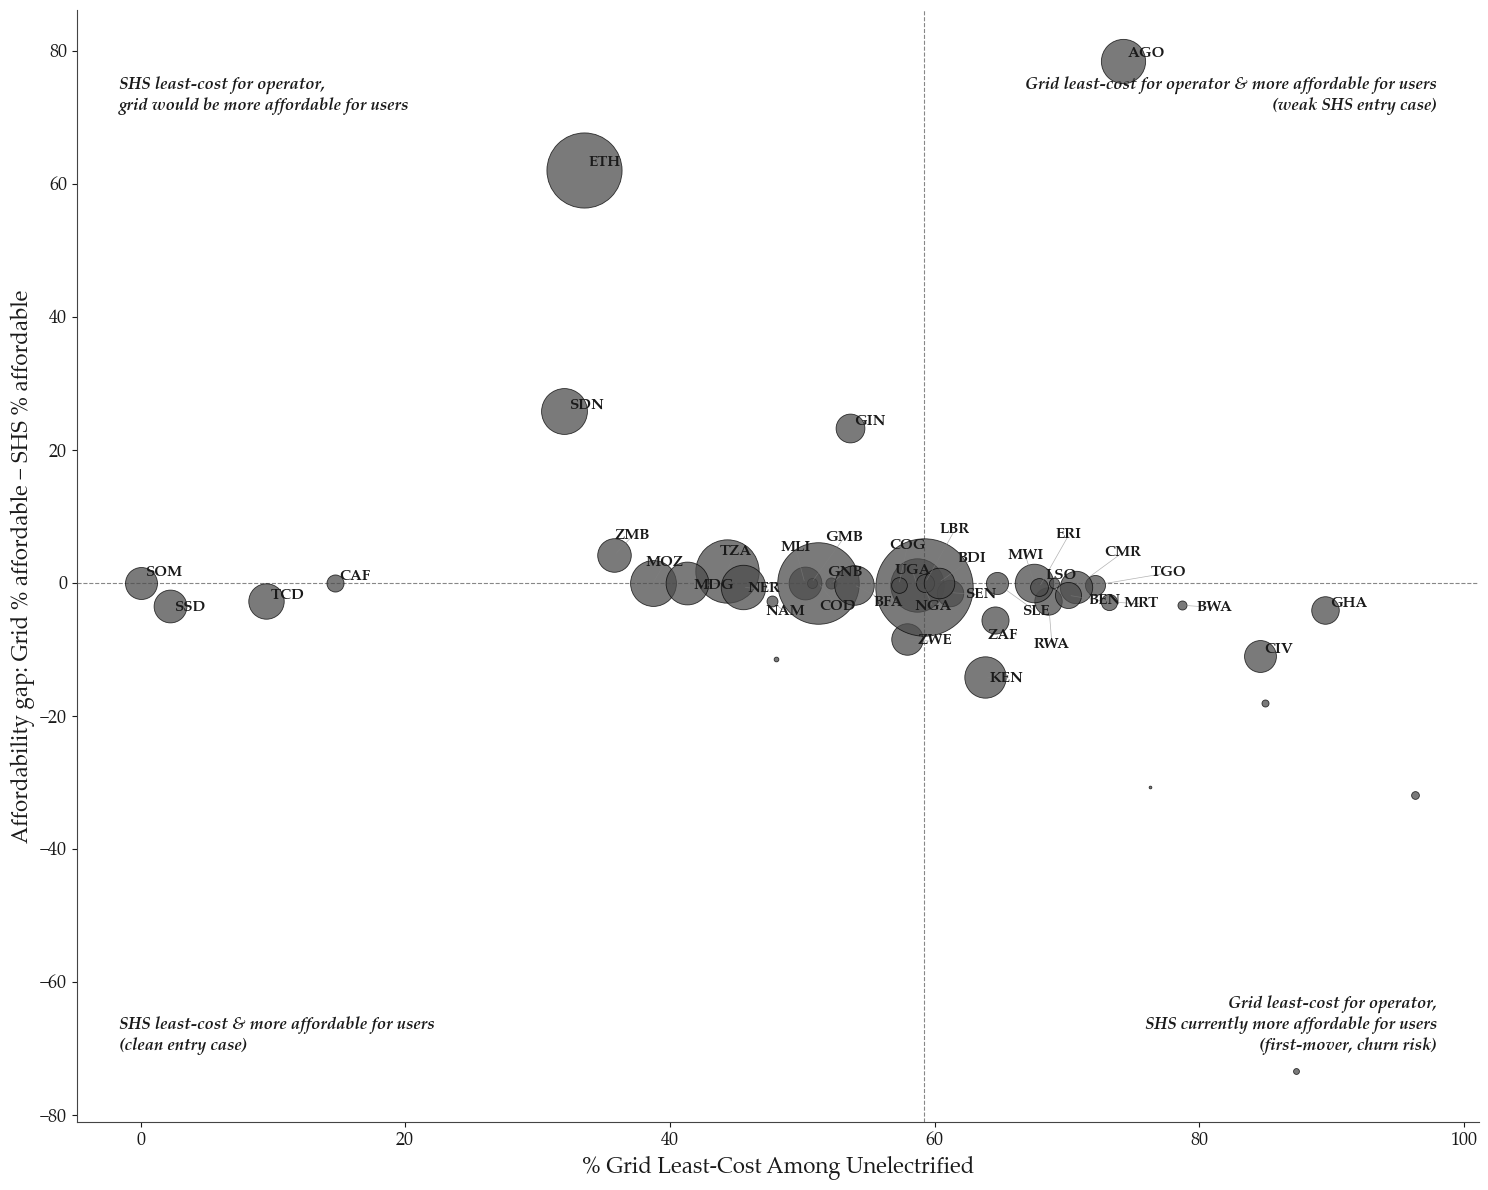

In [ ]:
#Comparative bubble chart: grid least-cost % vs affordability gap ────────

def make_comparative_affordability_chart(grid_tier='T4', weight_method='DRE',
                                          size_col='NewConn_Total',
                                          save_stub=None, label_min_size=None):
    # build the affordability gap per country 
    grid_aff = full_comparison_2025[
        (full_comparison_2025['Tier'] == grid_tier) &
        (full_comparison_2025['Weighting'] == weight_method)
    ][['ISO3', 'pct_affordable']].rename(columns={'pct_affordable': 'grid_affordable'})

    shs_aff = full_comparison_2025[
        (full_comparison_2025['Tier'] == 'SHS (PAYGo)') &
        (full_comparison_2025['Weighting'] == weight_method)
    ][['ISO3', 'pct_affordable']].rename(columns={'pct_affordable': 'shs_affordable'})

    gap_df = grid_aff.merge(shs_aff, on='ISO3', how='inner')
    gap_df['affordability_gap'] = gap_df['grid_affordable'] - gap_df['shs_affordable']

    plot_df = ssa_map.merge(gap_df, on='ISO3', how='left')
    plot_df = plot_df.dropna(subset=['Grid_viable_%', 'affordability_gap', size_col])

    median_x = plot_df['Grid_viable_%'].median()

    fig, ax = plt.subplots(figsize=(15, 12))
    texts = []

    for _, row in plot_df.iterrows():
        x, y = row['Grid_viable_%'], row['affordability_gap']
        raw_size = row[size_col]
        size = raw_size / 30000

        ax.scatter(
            x, y,
            s=size, color='#4d4d4d', alpha=0.75,
            edgecolors='black', linewidth=0.6,
            zorder=3
        )

        if label_min_size is None or raw_size >= label_min_size:
            texts.append(
                ax.text(x, y, row['ISO_A3'], fontsize=11, color='#1a1a1a',
                         fontweight='bold', zorder=5)
            )

    ax.axvline(median_x, color=GREY, linestyle='--', linewidth=0.8, zorder=1)
    ax.axhline(0,         color=GREY, linestyle='--', linewidth=0.8, zorder=1)

    quadrant_labels = {
        'tr': 'Grid least-cost for operator & more affordable for users\n(weak SHS entry case)',
        'tl': 'SHS least-cost for operator,\ngrid would be more affordable for users',
        'br': 'Grid least-cost for operator,\nSHS currently more affordable for users\n(first-mover, churn risk)',
        'bl': 'SHS least-cost & more affordable for users\n(clean entry case)',
    }

    xl = ax.get_xlim()
    yl = ax.get_ylim()
    pad_x = (xl[1] - xl[0]) * 0.03
    pad_y = (yl[1] - yl[0]) * 0.06

    quad_positions = {
        'tr': dict(x=xl[1] - pad_x, y=yl[1] - pad_y, ha='right', va='top'),
        'tl': dict(x=xl[0] + pad_x, y=yl[1] - pad_y, ha='left',  va='top'),
        'br': dict(x=xl[1] - pad_x, y=yl[0] + pad_y, ha='right', va='bottom'),
        'bl': dict(x=xl[0] + pad_x, y=yl[0] + pad_y, ha='left',  va='bottom'),
    }

    quad_texts = []
    for key, pos in quad_positions.items():
        t = ax.text(
            pos['x'], pos['y'], quadrant_labels[key],
            ha=pos['ha'], va=pos['va'],
            fontsize=12, fontweight='bold', color=TEXT_COLOR,
            style='italic', zorder=2,
            bbox=dict(boxstyle='round,pad=0.3', facecolor='white',
                      edgecolor='none', alpha=0.85)
        )
        quad_texts.append(t)

    adjust_text(
        texts, ax=ax,
        add_objects=quad_texts,
        expand_text=(1.3, 1.5),
        expand_points=(1.3, 1.5),
        force_text=(0.4, 0.6),
        force_points=(0.3, 0.5),
        arrowprops=dict(arrowstyle='-', color='grey', lw=0.5, alpha=0.6)
    )

    ax.set_xlabel('% Grid Least-Cost Among Unelectrified', color=TEXT_COLOR, fontsize=16)
    ax.set_ylabel('Affordability gap: Grid % affordable − SHS % affordable',
                   color=TEXT_COLOR, fontsize=16)

    ax.tick_params(axis='both', labelsize=13, colors=TEXT_COLOR)
    for spine in ['top', 'right']:
        ax.spines[spine].set_visible(False)

    plt.tight_layout()
    if save_stub:
        plt.savefig(FIG_DIR / f'{save_stub}.pdf', dpi=600, bbox_inches='tight')
        plt.savefig(FIG_DIR / f'{save_stub}.png', dpi=600, bbox_inches='tight')
    plt.show()
    plt.close(fig)

    return plot_df[['ISO3', 'Grid_viable_%', 'affordability_gap', size_col]]


comparative_df = make_comparative_affordability_chart(
    grid_tier='T4', weight_method='DRE',
    save_stub='fig_bubble_comparative_grid_shs',
    label_min_size=1_000_000   # tune against my NewConn_Total distribution
)

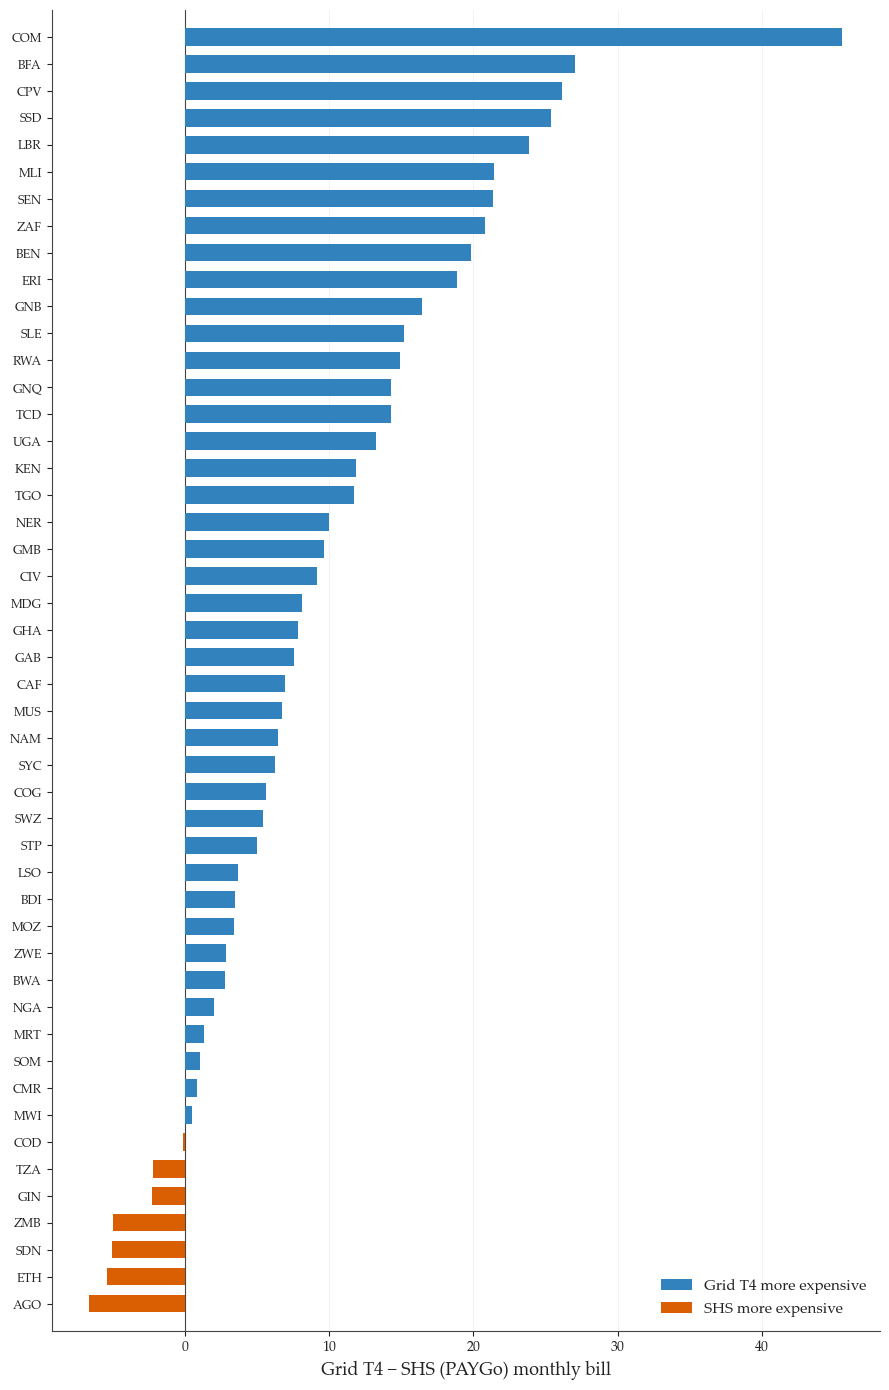

In [61]:
# Diverging bar chart: Grid T4 - SHS price gap, all SSA countries 


plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.serif']  = ['Palatino', 'Palatino Linotype', 'DejaVu Serif']
plt.rcParams['axes.edgecolor']  = '#444444'
plt.rcParams['text.color']      = '#222222'
plt.rcParams['axes.labelcolor'] = '#222222'
plt.rcParams['xtick.color']     = '#222222'

GRID_COLOR = '#3182bd'   # grid pricier than SHS (positive)
SHS_COLOR  = '#d95f02'   # SHS pricier than grid (negative)

#  build gap per country 
rows = []
for iso, tiers in grid_tariffs_ssa_2025.items():
    grid_t4 = tiers.get('T4')
    if grid_t4 is None:
        continue
    rows.append({
        'ISO3': iso,
        'gap': grid_t4 - MONTHLY_PAYGO_2025,   # positive = grid pricier than SHS
    })

gap_df = pd.DataFrame(rows).sort_values('gap').reset_index(drop=True)
colors = [SHS_COLOR if g < 0 else GRID_COLOR for g in gap_df['gap']]

# plot 
fig, ax = plt.subplots(figsize=(9, 14))
y_pos = np.arange(len(gap_df))

ax.barh(y_pos, gap_df['gap'], color=colors, height=0.65, zorder=3)
ax.axvline(0, color='#444444', linewidth=0.8, zorder=2)

ax.set_yticks(y_pos)
ax.set_yticklabels(gap_df['ISO3'], fontsize=9)
ax.set_xlabel('Grid T4 − SHS (PAYGo) monthly bill', fontsize=13)
ax.set_ylim(-1, len(gap_df))

for spine in ['top', 'right']:
    ax.spines[spine].set_visible(False)
ax.grid(axis='x', color='#eeeeee', linewidth=0.5, zorder=0)

#  legend via proxy patches, since barh colors are conditional not grouped 
legend_elements = [
    Patch(facecolor=GRID_COLOR, label='Grid T4 more expensive'),
    Patch(facecolor=SHS_COLOR,  label='SHS more expensive'),
]
ax.legend(handles=legend_elements, loc='lower right', frameon=False, fontsize=11)

plt.tight_layout()
plt.savefig(FIG_DIR / 'fig_diverging_grid_t4_vs_shs_gap.pdf', dpi=600, bbox_inches='tight')
plt.savefig(FIG_DIR / 'fig_diverging_grid_t4_vs_shs_gap.png', dpi=600, bbox_inches='tight')
plt.show()
plt.close(fig)

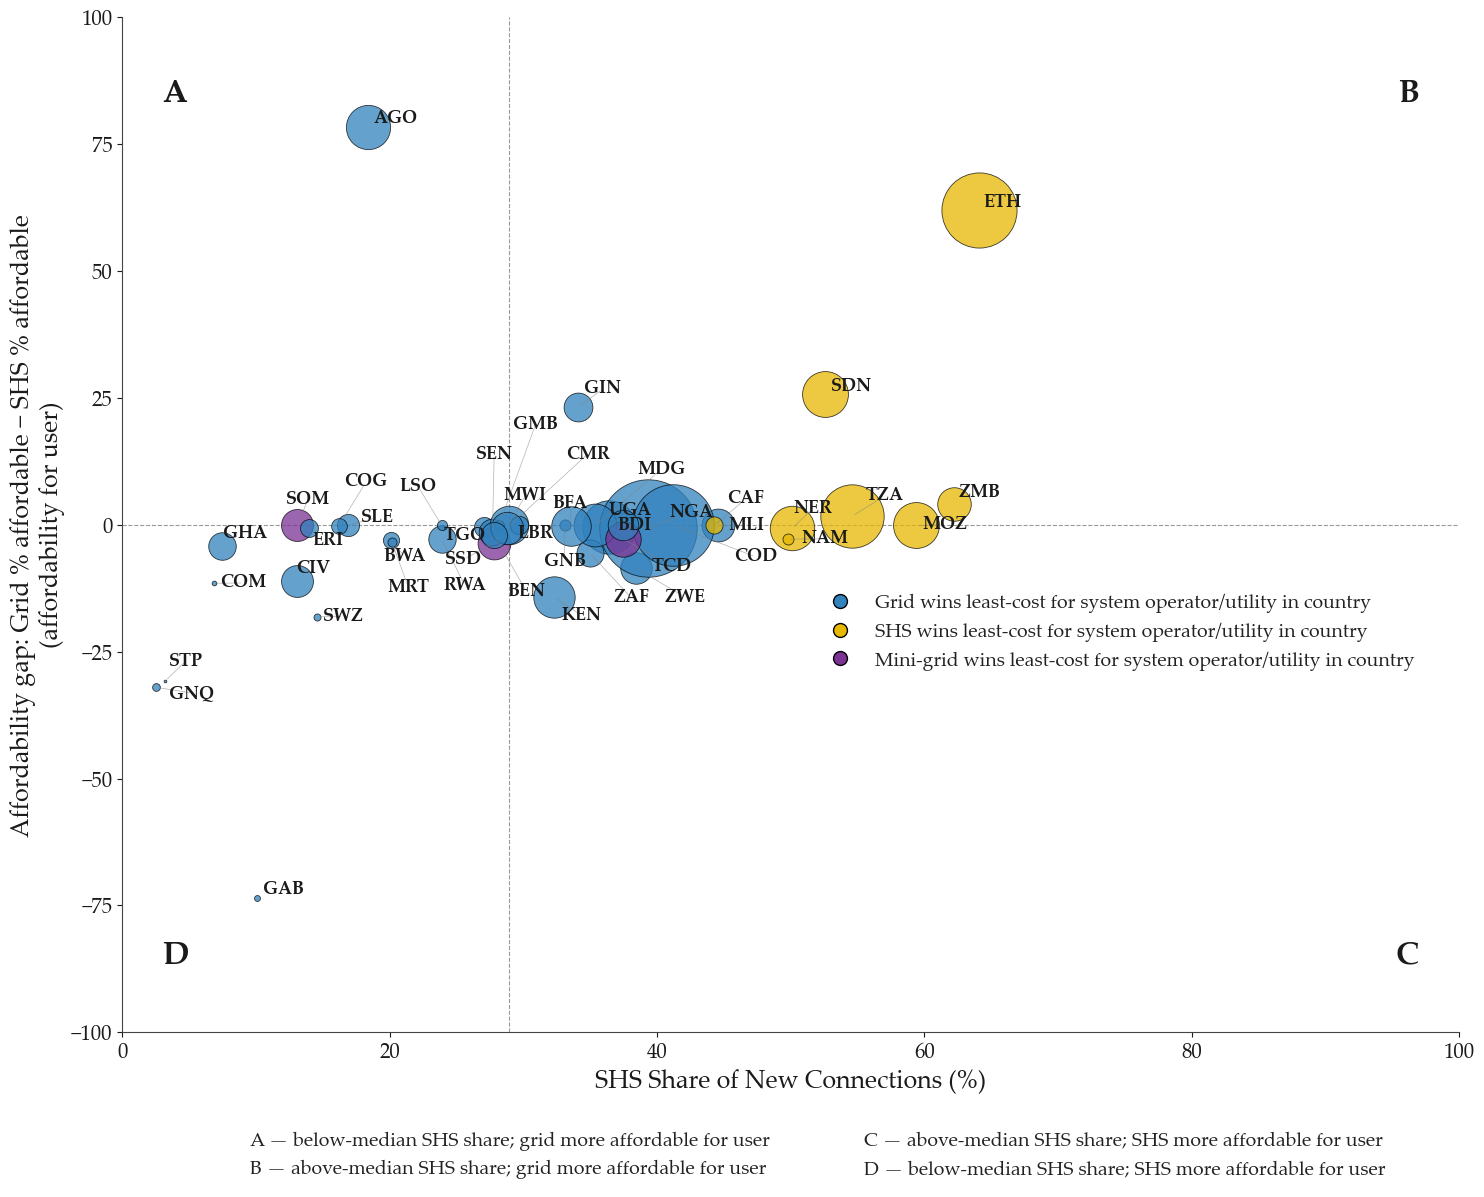

In [62]:
# Comparative bubble chart: SHS share of new connections vs affordability gap 

def make_operator_user_affordability_chart(weight_method='DRE',
                                            size_col='NewConn_Total',
                                            save_stub=None, label_min_size=None):
    grid_aff = full_comparison_2025[
        (full_comparison_2025['Tier'] == 'T4') &
        (full_comparison_2025['Weighting'] == weight_method)
    ][['ISO3', 'pct_affordable']].rename(columns={'pct_affordable': 'grid_affordable'})

    shs_aff = full_comparison_2025[
        (full_comparison_2025['Tier'] == 'SHS (PAYGo)') &
        (full_comparison_2025['Weighting'] == weight_method)
    ][['ISO3', 'pct_affordable']].rename(columns={'pct_affordable': 'shs_affordable'})

    gap_df = grid_aff.merge(shs_aff, on='ISO3', how='inner')
    gap_df['affordability_gap'] = gap_df['grid_affordable'] - gap_df['shs_affordable']

    plot_df = ssa_map.merge(gap_df, on='ISO3', how='left')
    plot_df = plot_df.dropna(subset=['SHS_%', 'affordability_gap', size_col,
                                      'Grid_viable_%', 'MiniGrid_%'])

    def dominant_tech(row):
        vals = {'Grid': row['Grid_viable_%'], 'SHS': row['SHS_%'], 'MiniGrid': row['MiniGrid_%']}
        return max(vals, key=vals.get)

    plot_df['dominant_tech'] = plot_df.apply(dominant_tech, axis=1)

    tech_colors = {'Grid': '#3182bd', 'SHS': '#e6b800', 'MiniGrid': '#7b3294'}
    plot_df['color'] = plot_df['dominant_tech'].map(tech_colors)

    median_x = plot_df['SHS_%'].median()

    fig, ax = plt.subplots(figsize=(15, 12))
    texts = []

    for _, row in plot_df.iterrows():
        x, y = row['SHS_%'], row['affordability_gap']
        raw_size = row[size_col]
        size = raw_size / 30000

        ax.scatter(
            x, y,
            s=size, color=row['color'], alpha=0.75,
            edgecolors='black', linewidth=0.6,
            zorder=3
        )

        if label_min_size is None or raw_size >= label_min_size:
            texts.append(
                ax.text(x, y, row['ISO_A3'], fontsize=13, color='#1a1a1a',
                         fontweight='bold', zorder=5)
            )

    ax.axvline(median_x, color='#999999', linestyle='--', linewidth=0.8, zorder=1)
    ax.axhline(0,        color='#999999', linestyle='--', linewidth=0.8, zorder=1)

    ax.set_xlim(0, 100)
    ax.set_ylim(-100, 100)

    quadrant_labels = {
        'tl': 'A',
        'tr': 'B',
        'br': 'C',
        'bl': 'D',
    }

    xl = ax.get_xlim()
    yl = ax.get_ylim()
    pad_x = (xl[1] - xl[0]) * 0.03
    pad_y = (yl[1] - yl[0]) * 0.06

    quad_positions = {
        'tr': dict(x=xl[1] - pad_x, y=yl[1] - pad_y, ha='right', va='top'),
        'tl': dict(x=xl[0] + pad_x, y=yl[1] - pad_y, ha='left',  va='top'),
        'br': dict(x=xl[1] - pad_x, y=yl[0] + pad_y, ha='right', va='bottom'),
        'bl': dict(x=xl[0] + pad_x, y=yl[0] + pad_y, ha='left',  va='bottom'),
    }

    quad_texts = []
    for key, pos in quad_positions.items():
        t = ax.text(
            pos['x'], pos['y'], quadrant_labels[key],
            ha=pos['ha'], va=pos['va'],
            fontsize=23, fontweight='bold', color=TEXT_COLOR,
            zorder=2,
            bbox=dict(boxstyle='round,pad=0.3', facecolor='white',
                      edgecolor='none', alpha=0.85)
        )
        quad_texts.append(t)

    adjust_text(
        texts, ax=ax,
        add_objects=quad_texts,
        expand_text=(1.3, 1.5),
        expand_points=(1.3, 1.5),
        force_text=(0.4, 0.6),
        force_points=(0.3, 0.5),
        arrowprops=dict(arrowstyle='-', color='grey', lw=0.5, alpha=0.6)
    )

    ax.set_xlabel('SHS Share of New Connections (%)', color=TEXT_COLOR, fontsize=18)
    ax.set_ylabel('Affordability gap: Grid % affordable − SHS % affordable\n(affordability for user)',
                   color=TEXT_COLOR, fontsize=18)

    ax.tick_params(axis='both', labelsize=15, colors=TEXT_COLOR)
    for spine in ['top', 'right']:
        ax.spines[spine].set_visible(False)

    from matplotlib.lines import Line2D
    legend_elements = [
        Line2D([0], [0], marker='o', color='w', label='Grid wins least-cost for system operator/utility in country',
               markerfacecolor=tech_colors['Grid'], markeredgecolor='black', markersize=10),
        Line2D([0], [0], marker='o', color='w', label='SHS wins least-cost for system operator/utility in country',
               markerfacecolor=tech_colors['SHS'], markeredgecolor='black', markersize=10),
        Line2D([0], [0], marker='o', color='w', label='Mini-grid wins least-cost for system operator/utility in country',
               markerfacecolor=tech_colors['MiniGrid'], markeredgecolor='black', markersize=10),
    ]
    tech_legend = ax.legend(handles=legend_elements, loc='upper right', bbox_to_anchor=(0.98, 0.45),
                             frameon=False, fontsize=14)
    ax.add_artist(tech_legend)

    quad_legend_elements = [
        Line2D([0], [0], marker='s', color='w',
               label='A — below-median SHS share; grid more affordable for user',
               markerfacecolor='white', markeredgecolor='black', markersize=0),
        Line2D([0], [0], marker='s', color='w',
               label='B — above-median SHS share; grid more affordable for user',
               markerfacecolor='white', markeredgecolor='black', markersize=0),
        Line2D([0], [0], marker='s', color='w',
               label='C — above-median SHS share; SHS more affordable for user',
               markerfacecolor='white', markeredgecolor='black', markersize=0),
        Line2D([0], [0], marker='s', color='w',
               label='D — below-median SHS share; SHS more affordable for user',
               markerfacecolor='white', markeredgecolor='black', markersize=0),
    ]
    ax.legend(handles=quad_legend_elements, loc='upper center',
              bbox_to_anchor=(0.5, -0.08), ncol=2, frameon=False, fontsize=14)

    plt.tight_layout()
    if save_stub:
        plt.savefig(FIG_DIR / f'{save_stub}.pdf', dpi=600, bbox_inches='tight')
        plt.savefig(FIG_DIR / f'{save_stub}.png', dpi=600, bbox_inches='tight')
    plt.show()
    plt.close(fig)

    return plot_df[['ISO3', 'SHS_%', 'affordability_gap', 'dominant_tech', size_col]]


operator_user_df = make_operator_user_affordability_chart(
    weight_method='DRE',
    save_stub='fig_bubble_operator_user_affordability',
    label_min_size=None
)

In [63]:
operator_user_df['SHS_%'].describe()
print((operator_user_df['SHS_%'] > 50).sum(), 'of', len(operator_user_df), 'countries above 50% SHS share')

6 of 45 countries above 50% SHS share


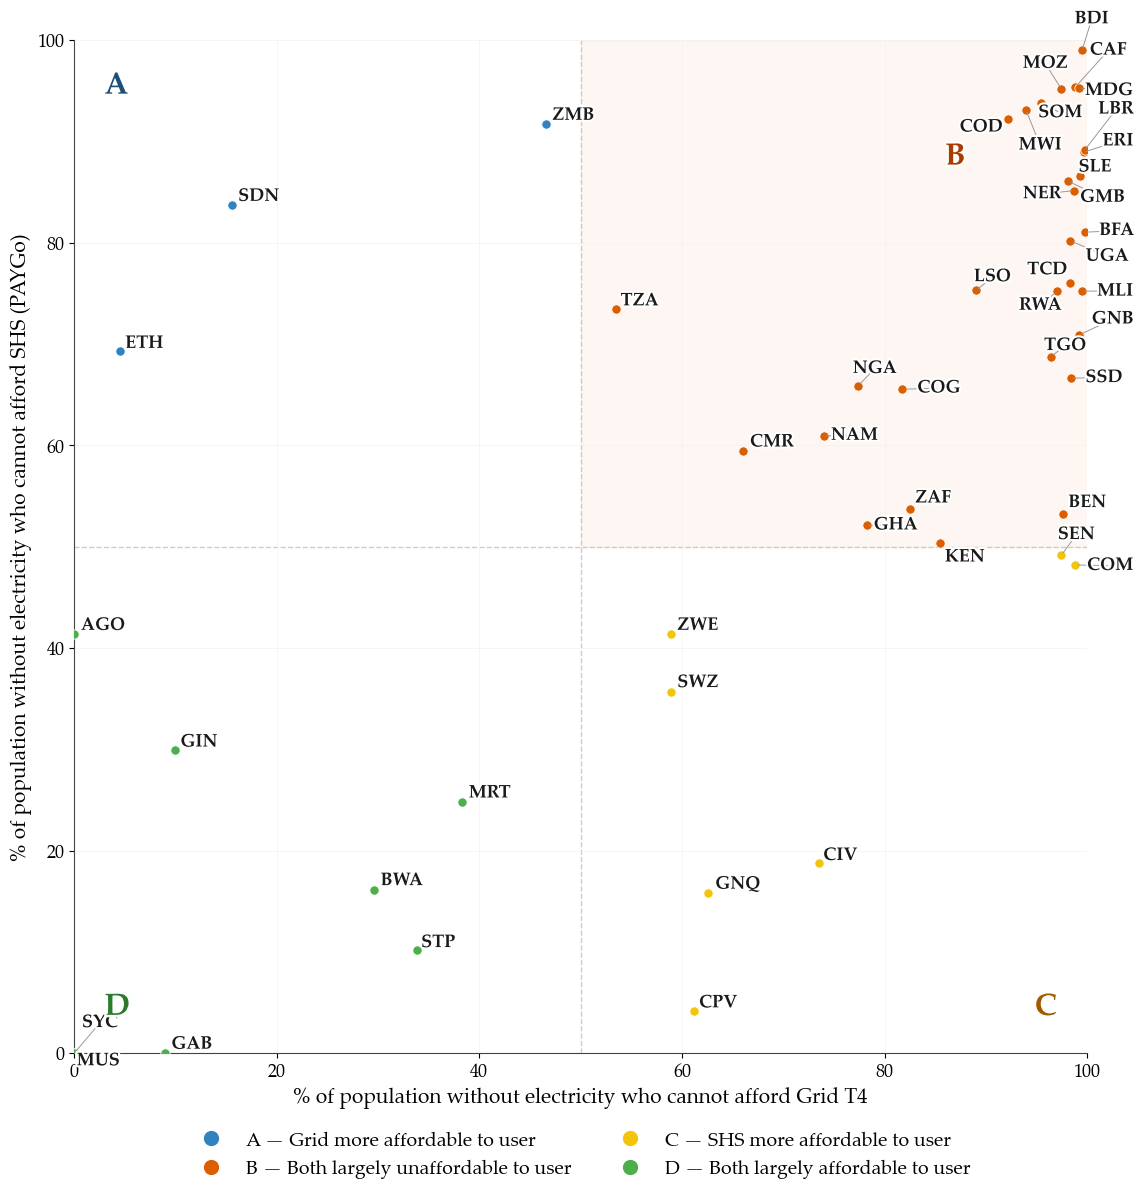

In [64]:
# Single-panel quadrant scatter, ALL countries labelled via adjustText

plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.serif']  = ['Palatino', 'Palatino Linotype', 'DejaVu Serif']
plt.rcParams['axes.edgecolor']  = '#444444'
plt.rcParams['text.color']      = '#000000'
plt.rcParams['axes.labelcolor'] = '#000000'
plt.rcParams['xtick.color']     = '#000000'
plt.rcParams['ytick.color']     = '#000000'

THRESHOLD = 50
DARK_TEXT = '#1a1a1a'

def midpoint_pct(df, iso, tier):
    sub = df[(df['ISO3'] == iso) & (df['Tier'] == tier)]
    if sub.empty:
        return None
    return sub['pct_cannot_afford'].mean()

isos = sorted(full_comparison_2025['ISO3'].unique())
rows = []
for iso in isos:
    t4  = midpoint_pct(full_comparison_2025, iso, 'T4')
    shs = midpoint_pct(full_comparison_2025, iso, 'SHS (PAYGo)')
    if t4 is None or shs is None:
        continue
    rows.append({'ISO3': iso, 'grid_t4': t4, 'shs': shs})

plot_df = pd.DataFrame(rows)

def classify(row):
    grid_bad = row['grid_t4'] >= THRESHOLD
    shs_bad  = row['shs'] >= THRESHOLD
    if grid_bad and shs_bad:
        return 'Both largely unaffordable'
    elif grid_bad and not shs_bad:
        return 'SHS more affordable'
    elif shs_bad and not grid_bad:
        return 'Grid more affordable'
    else:
        return 'Both largely affordable'

plot_df['bucket'] = plot_df.apply(classify, axis=1)

bucket_colors = {
    'Both largely unaffordable': '#d95f02',
    'Grid more affordable':      '#3182bd',
    'SHS more affordable':       '#f2c40c',
    'Both largely affordable':   '#4daf4a',
}

# ── plot ──────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(12, 12))

# quadrant shading — top-right (B) = both unaffordable
ax.axvspan(THRESHOLD, 100, ymin=(THRESHOLD/100), ymax=1, color='#d95f02', alpha=0.05, zorder=0)
ax.axvline(THRESHOLD, color='#cccccc', linewidth=1, linestyle='--', zorder=1)
ax.axhline(THRESHOLD, color='#cccccc', linewidth=1, linestyle='--', zorder=1)

texts = []
for row in plot_df.itertuples():
    col = bucket_colors[row.bucket]
    ax.scatter(row.grid_t4, row.shs, color=col, s=45, zorder=3,
               edgecolor='white', linewidth=0.6)
    t = ax.text(row.grid_t4, row.shs, row.ISO3, fontsize=13,
                color=DARK_TEXT, fontweight='bold', zorder=5)
    t.set_path_effects([pe.withStroke(linewidth=3, foreground='white')])
    texts.append(t)

adjust_text(texts, ax=ax,
            arrowprops=dict(arrowstyle='-', color='#999999', lw=0.7),
            expand_points=(1.8, 1.8), force_points=0.8)

# quadrant labels — clockwise from top-left: A, B, C, D, large + bold 
quadrant_labels = [
    (3,  97, 'A', '#1c4f7c', 'left',  'top'),      # top-left: grid more affordable
    (88, 90, 'B', '#a83c00', 'right', 'top'),      # top-right: both unaffordable
    (97, 3,  'C', '#a05a00', 'right', 'bottom'),   # bottom-right: SHS more affordable
    (3,  3,  'D', '#2c7a2c', 'left',  'bottom'),   # bottom-left: both affordable
]

for x, y, label, col, ha, va in quadrant_labels:
    t = ax.text(x, y, label, ha=ha, va=va, fontsize=22,
                color=col, fontweight='bold', zorder=6)
    t.set_path_effects([pe.withStroke(linewidth=3.5, foreground='white')])

ax.set_xlim(0, 100)
ax.set_ylim(0, 100)
ax.set_xlabel('% of population without electricity who cannot afford Grid T4', fontsize=15, color='#000000')
ax.set_ylabel('% of population without electricity who cannot afford SHS (PAYGo)', fontsize=15, color='#000000')
ax.tick_params(axis='both', labelsize=13)

for spine in ['top', 'right']:
    ax.spines[spine].set_visible(False)
ax.grid(color='#f2f2f2', linewidth=0.5, zorder=0)
ax.set_aspect('equal')

# legend, placed below the plot, matching clockwise A/B/C/D order
legend_elements = [
    Line2D([0], [0], marker='o', color='w', label='A — Grid more affordable to user',
           markerfacecolor='#3182bd', markersize=12),
    Line2D([0], [0], marker='o', color='w', label='B — Both largely unaffordable to user',
           markerfacecolor='#d95f02', markersize=12),
    Line2D([0], [0], marker='o', color='w', label='C — SHS more affordable to user',
           markerfacecolor='#f2c40c', markersize=12),
    Line2D([0], [0], marker='o', color='w', label='D — Both largely affordable to user',
           markerfacecolor='#4daf4a', markersize=12),
]
ax.legend(handles=legend_elements, loc='upper center',
          bbox_to_anchor=(0.5, -0.06), ncol=2, frameon=False, fontsize=14)

plt.tight_layout()
plt.savefig(FIG_DIR / 'fig_quadrant_all_labelled.pdf', dpi=600, bbox_inches='tight')
plt.savefig(FIG_DIR / 'fig_quadrant_all_labelled.png', dpi=600, bbox_inches='tight')
plt.show()
plt.close(fig)

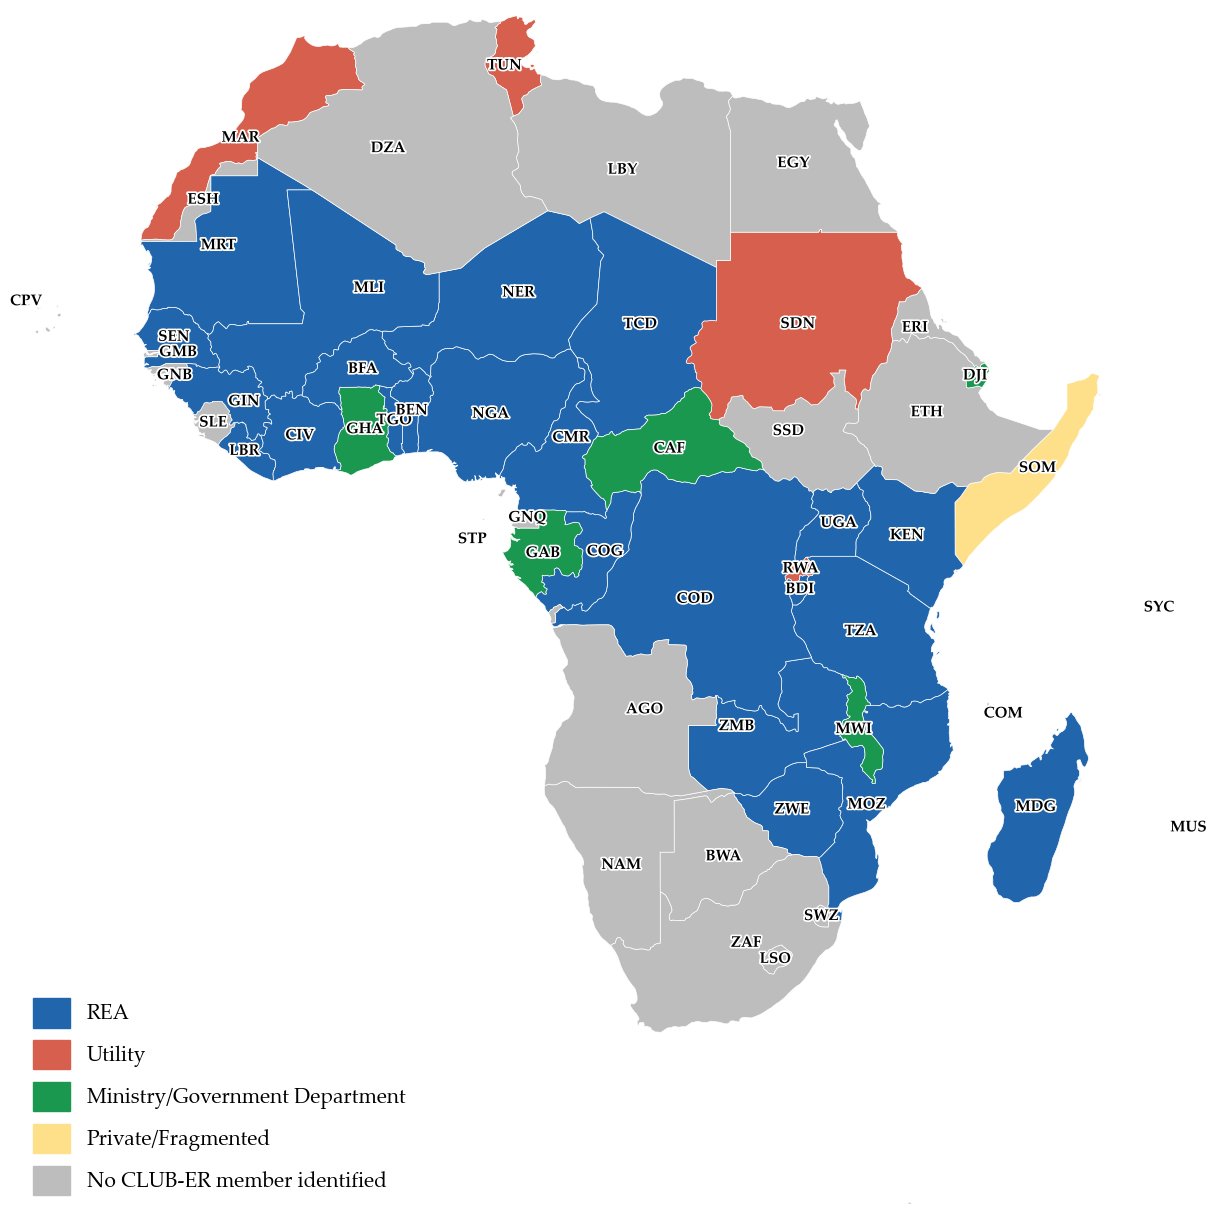

In [65]:
#rural elec model 

plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.serif']  = ['Palatino', 'Palatino Linotype', 'DejaVu Serif']

africa_iso = ssa_iso + ['MAR','DZA','LBY','EGY','TUN','ESH']
africa = world[world['ISO_A3'].isin(africa_iso)].copy()

agency_led = [
    'BEN','BFA','BDI','CMR','COG','COD','CIV','GIN','KEN','LBR','MDG','MLI',
    'MRT','MOZ','NER','NGA','SEN','TZA','TCD','TGO','UGA','ZMB','ZWE'
]
utility_led = ['SDN','RWA','MAR','TUN']
ministry_led = ['CAF','DJI','GHA','MWI','GAB']
unclear = ['SOM']

def classify(iso3):
    if iso3 in agency_led:
        return 'REA'
    elif iso3 in utility_led:
        return 'Utility'
    elif iso3 in ministry_led:
        return 'Ministry/Government Department'
    elif iso3 in unclear:
        return 'Private/Fragmented'
    else:
        return 'No CLUB-ER member identified'

africa['geometry'] = africa['geometry'].simplify(tolerance=0.001, preserve_topology=True)
africa['institution_type'] = africa['ISO_A3'].apply(classify)

type_colors = {
    'REA': '#2166AC',
    'Utility': '#D6604D',
    'Ministry/Government Department': '#1a9850',
    'Private/Fragmented': '#fee08b',
    'No CLUB-ER member identified': '#bdbdbd',
}
africa['color'] = africa['institution_type'].map(type_colors)

minx, miny, maxx, maxy = africa.total_bounds
pad_x = (maxx - minx) * 0.005
pad_y = (maxy - miny) * 0.005

fig, ax = plt.subplots(figsize=(12, 12))
africa.plot(color=africa['color'], ax=ax, edgecolor='white', linewidth=0.5)

halo = [pe.withStroke(linewidth=2.5, foreground='white')]

for _, row in africa.iterrows():
    if row.geometry is None:
        continue
    centroid = row.geometry.representative_point()
    ax.annotate(row['ISO_A3'], xy=(centroid.x, centroid.y),
                fontsize=11, fontweight='bold', color='black',
                ha='center', va='center', path_effects=halo)

ax.set_xlim(minx - pad_x, maxx + pad_x)
ax.set_ylim(miny - pad_y, maxy + pad_y)
ax.axis('off')

legend_handles = [mpatches.Patch(color=c, label=t) for t, c in type_colors.items()]
ax.legend(
    handles=legend_handles,
    loc='lower left',
    frameon=False,
    fontsize=15,
    handlelength=1.8,
    handleheight=1.8,
    labelspacing=0.6,
    borderpad=0.2,
)

fig.subplots_adjust(left=0, right=1, top=1, bottom=0)

plt.savefig(FIG_DIR / 'fig_africa_institutional_model.pdf', bbox_inches='tight', pad_inches=0.02)
plt.savefig(FIG_DIR / 'fig_africa_institutional_model.png', dpi=1200, bbox_inches='tight', pad_inches=0.02)
plt.show()
plt.close(fig)